In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


np.random.seed(77)


print("Current working folder:")
print(os.getcwd())

Current working folder:
c:\Users\juliu\OneDrive\Documenten\Tilburg Master\Thesis\DSS_Thesis\notebooks


# Sprint 1 - Exploratory Data Analysis
### This notebook contains the first exploratory analysis of the datasets that will be used in my thesis. The goal is to understand the structure, quality, and potential problems in the data before building models.

## 1. Purpose of Sprint 1
### Unit of analysis
The unit of analysis in this project is the country-year level. Each observation represent one country in one specific year.
### Target variable
The main target variable is Foreign Direct Investment (FDI) inflows as a percentage of GDP at the country-year level.
### Time alignment
Macroeconomic and governance indicators are available on a yearly basis.
Survey-based corruption perception data are collected in specific survey years for each country. 
These survey-year observations will later be matched to the corresponding year in the country-year panel dataset.
### Level of measurement
Corruption perception measures originate from individual-level survey responses. 
These responses will be aggregated to the country-year level by computing country-level summary statistics (e.g., mean perception scores) for each survey year.


## 2. Data Sources

This project combines multiple international datasets to construct a country-year panel dataset for analyzing the relationship between corruption and FDI inflows.

The following main data sources are used:

- **Foreign Direct Investment (FDI)** data from the World Bank, providing annual FDI inflows at the country level. This dataset contains the target variable.
FDI data (net inflows as % of GDP) are downloaded from the World Bank World Development Indicators. These data serve as the target variable and include annual observations for most countries.


- **Governance indicators** from the World Bank’s Worldwide Governance Indicators (WGI), specifically the Control of Corruption index, which measures institutional corruption at the country-year level.

- **Corruption perception measures** derived from the World Values Survey (WVS). These data originate from individual survey responses and will be aggregated to the country-year level.

- **Macroeconomic control variables** from the World Bank, such as GDP per capita, trade openness, and population, which are included to control for structural differences between countries.


## 3. Load Datasets
In this section, the datasets used in the thesis are loaded and their basic structure is inspected. 

### 3.1 FDI inflows as a percentage of GDP
We start with the FDI dataset, which contains the target variable.

Source: https://data.worldbank.org/indicator/BX.KLT.DINV.WD.GD.ZS


In [3]:
fdi_path = "../data_raw/fdi_net_inflows_pct-gdp.csv"

fdi_raw = pd.read_csv(fdi_path, skiprows=4)

print("FDI data loaded")
fdi_raw.head()




FDI data loaded


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,0.923397,5.253375,4.399817,-2.247834,6.517186,4.635530,7.465334,-3.584591,2.420512,NaN
1,Africa Eastern and Southern,AFE,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,2.012803,1.040979,1.309638,1.493266,1.421271,4.912515,1.717865,1.952889,1.962965,NaN
2,Afghanistan,AFG,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,0.516606,0.274797,0.661572,0.124496,0.064994,0.144467,0.000000,0.000000,NaN,NaN
3,Africa Western and Central,AFW,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,2.235357,2.556357,1.913953,1.227000,1.127169,1.657413,1.546783,2.137847,2.547896,NaN
4,Angola,AGO,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.299804,-8.766964,-7.212462,-5.076494,-3.171436,-5.474034,-5.028993,-1.977864,-1.098688,NaN


In [4]:
fdi_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 70 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            147 non-null    float64
 15  1971            149 non-null    float64
 16  1972            157 non-null    float64
 17  1973            160 non-null    flo

In [5]:
#Remove columns we do not need
fdi = fdi_raw.drop(columns=["Country Name", "Indicator Name", "Indicator Code", "Unnamed: 69"], errors = "ignore")

fdi.head()

,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,ABW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.907264,0.923397,5.253375,4.399817,-2.247834,6.517186,4.635530,7.465334,-3.584591,2.420512
1,AFE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.153412,2.012803,1.040979,1.309638,1.493266,1.421271,4.912515,1.717865,1.952889,1.962965
2,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.884000,0.516606,0.274797,0.661572,0.124496,0.064994,0.144467,0.000000,0.000000,NaN
3,AFW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.133300,2.235357,2.556357,1.913953,1.227000,1.127169,1.657413,1.546783,2.137847,2.547896
4,AGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.779515,-0.299804,-8.766964,-7.212462,-5.076494,-3.171436,-5.474034,-5.028993,-1.977864,-1.098688


In [6]:
# We need to reshape the data from wide to long format, to accomodate for our country-year data structure

fdi_long = fdi.melt(
    id_vars = "Country Code",
    var_name = "year",
    value_name = "fdi_inflows_pct_gdp"
)

fdi_long.head()

,Country Code,year,fdi_inflows_pct_gdp
0,ABW,1960,NaN
1,AFE,1960,NaN
2,AFG,1960,NaN
3,AFW,1960,NaN
4,AGO,1960,NaN


In [7]:
# Clean column names

fdi_long = fdi_long.rename(columns={"Country Code": "iso3"})

fdi_long["year"] = pd.to_numeric(fdi_long["year"], errors="coerce")

fdi_long.head()

,iso3,year,fdi_inflows_pct_gdp
0,ABW,1960,NaN
1,AFE,1960,NaN
2,AFG,1960,NaN
3,AFW,1960,NaN
4,AGO,1960,NaN


In [8]:
fdi_long.isna().sum()

iso3                      0
year                      0
fdi_inflows_pct_gdp    5220
dtype: int64

### 3.2 WGI Control of Corruption
Next, we load the World Bank Worldwide Governance Indicators dataset, focusing on the Control of Corruption indicator, which measures institutional corruption at the country-year level.

https://www.worldbank.org/en/publication/worldwide-governance-indicators

In [9]:
wgi_path = "../data_raw/wgi_data.xlsx"

wgi_raw = pd.read_excel(wgi_path, sheet_name="cc")

wgi_raw.head()

,ID variable (economy code/ gov. dimension/ year),Economy (name),Economy (code),Region,Income classification,Year,Governance dimension,Number of sources,Governance estimate (approx. -2.5 to +2.5),Standard error (estimate),...,OBI mean,PIA mean,PRS mean,RSF mean,VAB mean,VDM mean,WBS mean,WCY mean,WJP mean,WMO mean
0,ADOcc1996,Andorra,ADO,NaN,NaN,1996,cc,1,1.362621,0.435253,...,..,..,..,..,..,..,..,..,..,0.875
1,AFGcc1996,Afghanistan,AFG,South Asia,Low income,1996,cc,2,-1.717570,0.343049,...,..,..,..,..,..,0.148,..,..,..,0
2,AGOcc1996,Angola,AGO,Sub-Saharan Africa,Lower middle income,1996,cc,4,-1.116075,0.231675,...,..,..,0.5,..,..,0.191,..,..,..,0.125
3,ALBcc1996,Albania,ALB,Europe & Central Asia,Upper middle income,1996,cc,3,-0.837552,0.295562,...,..,..,0.333333,..,..,0.317,..,..,..,0.25
4,AREcc1996,United Arab Emirates,ARE,Middle East & North Africa,High income,1996,cc,4,0.241391,0.231675,...,..,..,0.333333,..,..,0.865,..,..,..,0.75


In [10]:
wgi_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5373 entries, 0 to 5372
Data columns (total 51 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   ID variable (economy code/ gov. dimension/ year)  5373 non-null   object 
 1   Economy (name)                                    5373 non-null   object 
 2   Economy (code)                                    5373 non-null   object 
 3   Region                                            5201 non-null   object 
 4   Income classification                             5149 non-null   object 
 5   Year                                              5373 non-null   int64  
 6   Governance dimension                              5373 non-null   object 
 7   Number of sources                                 5373 non-null   int64  
 8   Governance estimate (approx. -2.5 to +2.5)        5373 non-null   float64
 9   Standard error (est

In [11]:
# Only relevant columns
wgi = wgi_raw[["Economy (code)", "Year", "Governance estimate (approx. -2.5 to +2.5)"]].copy() 

wgi = wgi.rename(columns={"Economy (code)": "iso3", "Year": "year", "Governance estimate (approx. -2.5 to +2.5)": "control_of_corruption"})

wgi["year"] = pd.to_numeric(wgi["year"], errors="coerce")

wgi.head()

,iso3,year,control_of_corruption
0,ADO,1996,1.362621
1,AFG,1996,-1.717570
2,AGO,1996,-1.116075
3,ALB,1996,-0.837552
4,ARE,1996,0.241391


### 3.3 WVS Wave 6 Perception of Corruption
Next, we load the World Values Survey Wave 6 dataset. This will be used to create a proxy index for our perception of corruption variable.

https://www.worldvaluessurvey.org/WVSDocumentationWV6.jsp

In [12]:
wvs6_path = "../data_raw/wvs6_data.csv"

wvs6 = pd.read_csv(wvs6_path, sep=";")

wvs6.head()

C:\Users\juliu\AppData\Local\Temp\ipykernel_12316\1821203825.py:3: DtypeWarning: Columns (340,341,408,411,412,413,414,416,421,422,423,424,426,431,436,441) have mixed types. Specify dtype option on import or set low_memory=False.
  wvs6 = pd.read_csv(wvs6_path, sep=";")


,V1,V2,V2A,COW,C_COW_ALPHA,B_COUNTRY_ALPHA,V3,V4,V5,V6,...,I_HOMOLIB,I_ABORTLIB,I_DIVORLIB,CHOICE,WEIGHT3B,I_VOICE1,I_VOICE2,I_VOI2_00,VOICE,WEIGHT4B
0,6,12,12,615,ALG,DZA,1,1,1,1,...,0,0,",222222",",074074",1,0,",5",",25",",25",1
1,6,12,12,615,ALG,DZA,2,1,2,3,...,0,0,0,0,1,",66",0,",33",",33",1
2,6,12,12,615,ALG,DZA,3,1,3,2,...,0,0,",333333",",111111",1,",33",0,",165",",165",1
3,6,12,12,615,ALG,DZA,4,1,1,3,...,0,0,0,0,1,0,0,0,0,1
4,6,12,12,615,ALG,DZA,5,1,1,1,...,0,0,",222222",",074074",1,",66",0,",33",",33",1


In [13]:
wvs6.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89565 entries, 0 to 89564
Columns: 442 entries, V1 to WEIGHT4B
dtypes: int64(392), object(50)
memory usage: 302.0+ MB


In [14]:
# starting the proxy of V228, since this is our perception of corruption variable. 
# Made out of 9 questions

items = ["V228A", "V228B", "V228C", "V228D", "V228E", "V228F", "V228G", "V228H", "V228I"]

wvs6[items].describe()


,V228A,V228B,V228C,V228D,V228E,V228F,V228G,V228H,V228I
count,89565.000000,89565.000000,89565.000000,89565.000000,89565.000000,89565.000000,89565.000000,89565.000000,89565.000000
mean,-0.116720,0.134796,-0.113493,0.009033,-0.074929,-0.083258,-0.073020,0.267727,-0.188109
std,2.943633,3.218800,3.054712,3.102768,2.983636,3.000603,3.066115,3.326009,2.915297
min,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000
25%,-4.000000,-4.000000,-4.000000,-4.000000,-4.000000,-4.000000,-4.000000,-4.000000,-4.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000
75%,2.000000,3.000000,2.000000,3.000000,2.000000,2.000000,3.000000,3.000000,2.000000
max,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000


In [15]:
#Values -1, -2, -3, -4 and -5 are not real answers, they are technical codes used during data collection and cleaning
#Therefore we will replace them with NaN

for v in items:
    wvs6[v] = wvs6[v].replace([-4, -5, -3, -2, -1], np.nan)

wvs6[items].describe()


,V228A,V228B,V228C,V228D,V228E,V228F,V228G,V228H,V228I
count,53377.000000,50000.000000,50909.000000,51120.000000,52191.000000,51534.000000,49835.000000,50444.000000,51813.000000
mean,2.145418,2.820120,2.377438,2.511913,2.293001,2.321846,2.457650,3.023670,2.125181
std,1.005486,0.991253,0.996522,1.071303,0.916681,0.973360,1.085791,1.029892,0.981179
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000
50%,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000
75%,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000
max,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000


In [16]:
#Now we reverse the questions B, C, D, G & H, since they are inversely rated. Using the code below we make sure that a higher value means more corruption.

reverse_items = ["V228B", "V228C", "V228D", "V228G", "V228H"]

for col in reverse_items:
    wvs6[col] = 5 - wvs6[col]

wvs6[items].describe()


,V228A,V228B,V228C,V228D,V228E,V228F,V228G,V228H,V228I
count,53377.000000,50000.000000,50909.000000,51120.000000,52191.000000,51534.000000,49835.000000,50444.000000,51813.000000
mean,2.145418,2.179880,2.622562,2.488087,2.293001,2.321846,2.542350,1.976330,2.125181
std,1.005486,0.991253,0.996522,1.071303,0.916681,0.973360,1.085791,1.029892,0.981179
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000
50%,2.000000,2.000000,3.000000,3.000000,2.000000,2.000000,3.000000,2.000000,2.000000
75%,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
max,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000


In [17]:
#Now we start building the corruption perception proxy

wvs6["corr_proxy_raw"] = wvs6[items].mean(axis=1, skipna=True)

wvs6["corr_proxy_std"] = (wvs6["corr_proxy_raw"] - wvs6["corr_proxy_raw"].mean()) / wvs6["corr_proxy_raw"].std()

wvs6["corr_proxy_std"].describe()


count    5.651600e+04
mean     6.034760e-17
std      1.000000e+00
min     -2.169545e+00
25%     -6.758000e-01
50%      7.107238e-02
75%      6.312267e-01
max      2.871844e+00
Name: corr_proxy_std, dtype: float64

In [18]:
#Now we strip the dataset to keep only the important columns. These are:
# B_COUNTRY_ALPHA = iso3
# V262 = survey year
# corr_proxy_std = our corruption perception proxy, standardized to have mean 0 and std 1

wvs6_small = wvs6[["B_COUNTRY_ALPHA", "V262", "corr_proxy_std"]].copy()
wvs6_small = wvs6_small.rename(columns={"V262": "year"})
wvs6_small = wvs6_small.rename(columns={"B_COUNTRY_ALPHA": "iso3"})

# And we aggregate to country-year level

wvs6_country_year = (
    wvs6_small
    .groupby(["iso3", "year"])["corr_proxy_std"]
    .mean()
    .reset_index()
)

print(wvs6_country_year.head())
print(wvs6_country_year.info())


  iso3  year  corr_proxy_std
0  ARG  2013        0.027713
1  ARM  2011             NaN
2  AUS  2012       -0.881762
3  AZE  2011       -0.293631
4  BLR  2011             NaN
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   iso3            60 non-null     object 
 1   year            60 non-null     int64  
 2   corr_proxy_std  42 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.5+ KB
None


### 3.4 WVS Wave 7 Perception of Corruption
In this step, we load the World Values Survey (WVS) Wave 7 dataset. This wave contains a direct question on perceived corruption (Q112), which will later be used to construct a country-year level perception of corruption variable.

https://www.worldvaluessurvey.org/WVSDocumentationWV7.jsp

In [19]:
wvs7_path = "../data_raw/wvs7_data.csv"

wvs7 = pd.read_csv(wvs7_path, sep=",")

wvs7.head()


C:\Users\juliu\AppData\Local\Temp\ipykernel_12316\883989526.py:3: DtypeWarning: Columns (346,348,350,580,581,582,583) have mixed types. Specify dtype option on import or set low_memory=False.
  wvs7 = pd.read_csv(wvs7_path, sep=",")


,version,doi,A_WAVE,A_YEAR,A_STUDY,B_COUNTRY,B_COUNTRY_ALPHA,C_COW_NUM,C_COW_ALPHA,D_INTERVIEW,...,WVS_Polmistrust_PartyVoter,WVS_LR_MedianVoter,WVS_LibCon_MedianVoter,v2psbars,v2psorgs,v2psprbrch,v2psprlnks,v2psplats,v2xnp_client,v2xps_party
0,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,20,AND,232,AND,20070001,...,62.434211,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
1,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,20,AND,232,AND,20070002,...,62.434211,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
2,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,20,AND,232,AND,20070003,...,62.434211,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
3,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,20,AND,232,AND,20070004,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,20,AND,232,AND,20070005,...,66.964286,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0


In [20]:
wvs7.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97220 entries, 0 to 97219
Columns: 613 entries, version to v2xps_party
dtypes: float64(195), int64(406), object(12)
memory usage: 454.7+ MB


In [21]:
wvs7["Q112"].value_counts(dropna=False)

Q112
 10    33557
 8     12908
 7     11210
 9      9019
 5      8666
 6      8529
 4      3986
 3      3726
 2      2084
 1      1890
-1      1168
-2       326
-5       151
Name: count, dtype: int64

In [22]:
wvs7["Q112"] = wvs7["Q112"].replace([-4, -5, -3, -2, -1], np.nan)
wvs7["Q112"].value_counts(dropna=False)

Q112
10.0    33557
8.0     12908
7.0     11210
9.0      9019
5.0      8666
6.0      8529
4.0      3986
3.0      3726
2.0      2084
1.0      1890
NaN      1645
Name: count, dtype: int64

In [23]:
wvs7["corr_proxy_raw"] = wvs7["Q112"]
wvs7["corr_proxy_raw"].describe()

count    95575.000000
mean         7.597792
std          2.454230
min          1.000000
25%          6.000000
50%          8.000000
75%         10.000000
max         10.000000
Name: corr_proxy_raw, dtype: float64

In [24]:
wvs7["corr_proxy_std"] = (wvs7["corr_proxy_raw"] - wvs7["corr_proxy_raw"].mean()) / wvs7["corr_proxy_raw"].std()
wvs7["corr_proxy_std"].describe()

count    9.557500e+04
mean     8.326527e-17
std      1.000000e+00
min     -2.688335e+00
25%     -6.510360e-01
50%      1.638834e-01
75%      9.788029e-01
max      9.788029e-01
Name: corr_proxy_std, dtype: float64

In [25]:
wvs7_small = wvs7[["B_COUNTRY_ALPHA", "A_YEAR", "corr_proxy_std"]].copy()
wvs7_small = wvs7_small.rename(columns={"B_COUNTRY_ALPHA": "iso3", "A_YEAR": "year"})
wvs7_small.head()

,iso3,year,corr_proxy_std
0,AND,2018,-2.280875
1,AND,2018,0.978803
2,AND,2018,-0.243576
3,AND,2018,-1.058496
4,AND,2018,-1.058496


In [26]:
wvs7_country_year = (
    wvs7_small
    .groupby(["iso3", "year"])["corr_proxy_std"]
    .mean()
    .reset_index()
)

wvs7_country_year.head()
wvs7_country_year.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   iso3            66 non-null     object 
 1   year            66 non-null     int64  
 2   corr_proxy_std  66 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.7+ KB


### 3.5 Merging Wave 6 and Wave 7

In [27]:
wvs6_country_year["wave"] = 6
wvs7_country_year["wave"] = 7

wvs_perception = pd.concat([wvs6_country_year, wvs7_country_year], ignore_index=True)
wvs_perception.sort_values(["iso3", "year"]).head()


,iso3,year,corr_proxy_std,wave
60,AND,2018,-0.732278,7
0,ARG,2013,0.027713,6
61,ARG,2017,0.373539,7
1,ARM,2011,NaN,6
62,ARM,2021,-0.018842,7


In [28]:
wvs_perception.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   iso3            126 non-null    object 
 1   year            126 non-null    int64  
 2   corr_proxy_std  108 non-null    float64
 3   wave            126 non-null    int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 4.1+ KB


### 3.6 WDI Control variables
To align the dataset with the thesis proposal, additional WDI-based control variables are added to the country-year panel. These controls capture broader economic conditions that may also affect FDI inflows, namely:
- GDP per capita 
- inflation
- trade openness


### GDP per capita

In [29]:
gdp_per_capita_path = "../data_raw/gdp_per_capita_wdi.csv"
gdp_per_capita_raw = pd.read_csv(gdp_per_capita_path, skiprows=4)
gdp_per_capita_raw.head()


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,28440.041688,30082.158423,30645.890602,22759.807175,26749.329609,30975.998912,35718.753119,39498.594129,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.089204,186.909053,197.367547,225.400079,208.962717,226.836135,...,1528.104224,1552.073722,1507.085600,1351.591669,1562.416175,1679.327622,1571.449189,1615.396356,NaN,NaN
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN,NaN,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,121.936832,127.451040,133.823783,139.004980,148.545883,155.561897,...,1574.230564,1720.140092,2216.385055,2030.861659,2112.794076,2138.473153,1841.855064,1411.337029,NaN,NaN
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2790.718869,2860.093648,2493.678844,1759.356199,2303.908127,3682.113151,2916.136633,2665.874448,NaN,NaN


In [30]:
gdp_per_capita_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            151 non-null    float64
 5   1961            154 non-null    float64
 6   1962            156 non-null    float64
 7   1963            156 non-null    float64
 8   1964            156 non-null    float64
 9   1965            162 non-null    float64
 10  1966            163 non-null    float64
 11  1967            167 non-null    float64
 12  1968            168 non-null    float64
 13  1969            168 non-null    float64
 14  1970            190 non-null    float64
 15  1971            191 non-null    float64
 16  1972            191 non-null    float64
 17  1973            191 non-null    flo

In [31]:
#Remove columns we do not need
gdp_pc = gdp_per_capita_raw.drop(columns=["Country Name", "Indicator Name", "Indicator Code", "Unnamed: 70"], errors = "ignore")

gdp_pc.head()

,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,ABW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,27441.550214,28440.041688,30082.158423,30645.890602,22759.807175,26749.329609,30975.998912,35718.753119,39498.594129,NaN
1,AFE,186.089204,186.909053,197.367547,225.400079,208.962717,226.836135,240.911794,243.773593,257.143823,...,1334.470500,1528.104224,1552.073722,1507.085600,1351.591669,1562.416175,1679.327622,1571.449189,1615.396356,NaN
2,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,522.082216,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN,NaN
3,AFW,121.936832,127.451040,133.823783,139.004980,148.545883,155.561897,162.107340,144.940804,146.186183,...,1630.039439,1574.230564,1720.140092,2216.385055,2030.861659,2112.794076,2138.473153,1841.855064,1411.337029,NaN
4,AGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2051.814621,2790.718869,2860.093648,2493.678844,1759.356199,2303.908127,3682.113151,2916.136633,2665.874448,NaN


In [32]:
# We need to reshape the data from wide to long format, to accomodate for our country-year data structure

gdp_pc_long = gdp_pc.melt(
    id_vars = "Country Code",
    var_name = "year",
    value_name = "gdp_per_capita"
)

gdp_pc_long.head()

,Country Code,year,gdp_per_capita
0,ABW,1960,NaN
1,AFE,1960,186.089204
2,AFG,1960,NaN
3,AFW,1960,121.936832
4,AGO,1960,NaN


In [33]:
# Clean column names

gdp_pc_long = gdp_pc_long.rename(columns={"Country Code": "iso3"})

gdp_pc_long["year"] = pd.to_numeric(gdp_pc_long["year"], errors="coerce")

gdp_pc_long.head()

,iso3,year,gdp_per_capita
0,ABW,1960,NaN
1,AFE,1960,186.089204
2,AFG,1960,NaN
3,AFW,1960,121.936832
4,AGO,1960,NaN


In [34]:
gdp_pc_long.isna().sum()

iso3                 0
year                 0
gdp_per_capita    2995
dtype: int64

### Inflation

In [35]:
inflation_path = "../data_raw/inflation_wdi.csv"
inflation_raw = pd.read_csv(inflation_path, skiprows=4)
inflation_raw.head()


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.028282,3.626041,4.257462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,6.221375,4.689806,4.102851,5.191629,6.824727,10.883478,7.399186,4.489789,NaN,NaN
2,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,4.975952,0.626149,2.302373,5.601888,5.133203,13.712102,-4.644709,-6.601186,NaN,NaN
3,Africa Western and Central,AFW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,1.725486,1.784050,1.983092,2.490378,3.745568,7.949251,5.221168,3.608044,NaN,NaN
4,Angola,AGO,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,29.844480,19.628938,17.080954,22.271539,25.754295,21.355290,13.644102,28.240495,NaN,NaN


In [36]:
inflation_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            70 non-null     float64
 5   1961            72 non-null     float64
 6   1962            74 non-null     float64
 7   1963            74 non-null     float64
 8   1964            79 non-null     float64
 9   1965            86 non-null     float64
 10  1966            93 non-null     float64
 11  1967            100 non-null    float64
 12  1968            101 non-null    float64
 13  1969            102 non-null    float64
 14  1970            108 non-null    float64
 15  1971            112 non-null    float64
 16  1972            114 non-null    float64
 17  1973            117 non-null    flo

In [37]:
# Remove columns we do not need

inflation = inflation_raw.drop(columns=["Country Name", "Indicator Name", "Indicator Code", "Unnamed: 70"], errors = "ignore")

inflation.head()

,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,ABW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.931196,-1.028282,3.626041,4.257462,NaN,NaN,NaN,NaN,NaN,NaN
1,AFE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.446877,6.221375,4.689806,4.102851,5.191629,6.824727,10.883478,7.399186,4.489789,NaN
2,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.383892,4.975952,0.626149,2.302373,5.601888,5.133203,13.712102,-4.644709,-6.601186,NaN
3,AFW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.487416,1.725486,1.784050,1.983092,2.490378,3.745568,7.949251,5.221168,3.608044,NaN
4,AGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,30.694415,29.844480,19.628938,17.080954,22.271539,25.754295,21.355290,13.644102,28.240495,NaN


In [38]:
# we need to reshape the data from wide to long format, to accomodate for our country-year data structure

inflation_long = inflation.melt(
    id_vars = "Country Code",
    var_name = "year",
    value_name = "inflation"
)
inflation_long.head()

,Country Code,year,inflation
0,ABW,1960,NaN
1,AFE,1960,NaN
2,AFG,1960,NaN
3,AFW,1960,NaN
4,AGO,1960,NaN


In [39]:
# Clean column names

inflation_long = inflation_long.rename(columns={"Country Code": "iso3"})

inflation_long["year"] = pd.to_numeric(inflation_long["year"], errors="coerce")

inflation_long.head()

,iso3,year,inflation
0,ABW,1960,NaN
1,AFE,1960,NaN
2,AFG,1960,NaN
3,AFW,1960,NaN
4,AGO,1960,NaN


In [40]:
inflation_long.isna().sum()

iso3            0
year            0
inflation    6261
dtype: int64

### Trade Openness

In [41]:
trade_openness_path = "../data_raw/trade_wdi.csv"
trade_openness_raw = pd.read_csv(trade_openness_path, skiprows=4)
trade_openness_raw.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Trade (% of GDP),NE.TRD.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,138.716620,138.824972,137.961929,122.723738,139.917798,160.634546,159.018597,160.365279,NaN,NaN
1,Africa Eastern and Southern,AFE,Trade (% of GDP),NE.TRD.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,51.833207,55.022038,53.528129,49.521705,54.501265,57.152776,56.170528,54.422178,NaN,NaN
2,Afghanistan,AFG,Trade (% of GDP),NE.TRD.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,46.709895,51.411716,72.885470,67.584665,NaN,NaN,NaN
3,Africa Western and Central,AFW,Trade (% of GDP),NE.TRD.GNFS.ZS,33.02326,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Trade (% of GDP),NE.TRD.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,45.664342,58.916480,60.714824,54.344229,61.526214,55.254773,53.033484,50.842231,NaN,NaN


In [42]:
trade_openness_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            81 non-null     float64
 5   1961            77 non-null     float64
 6   1962            79 non-null     float64
 7   1963            80 non-null     float64
 8   1964            81 non-null     float64
 9   1965            87 non-null     float64
 10  1966            89 non-null     float64
 11  1967            91 non-null     float64
 12  1968            92 non-null     float64
 13  1969            93 non-null     float64
 14  1970            124 non-null    float64
 15  1971            125 non-null    float64
 16  1972            126 non-null    float64
 17  1973            126 non-null    flo

In [43]:
# remove columns we do not need

trade_openness = trade_openness_raw.drop(columns=["Country Name", "Indicator Name", "Indicator Code", "Unnamed: 70"], errors = "ignore")

trade_openness.head()

,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,ABW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,136.887263,138.716620,138.824972,137.961929,122.723738,139.917798,160.634546,159.018597,160.365279,NaN
1,AFE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,52.953202,51.833207,55.022038,53.528129,49.521705,54.501265,57.152776,56.170528,54.422178,NaN
2,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,46.709895,51.411716,72.885470,67.584665,NaN,NaN
3,AFW,33.02326,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,47.015566,45.664342,58.916480,60.714824,54.344229,61.526214,55.254773,53.033484,50.842231,NaN


In [44]:
# We need to reshape the data from wide to long format, to accomodate for our country-year data structure

trade_openness_long = trade_openness.melt(
    id_vars = "Country Code",
    var_name = "year",
    value_name = "trade_openness"
)

trade_openness_long.head()

,Country Code,year,trade_openness
0,ABW,1960,NaN
1,AFE,1960,NaN
2,AFG,1960,NaN
3,AFW,1960,33.02326
4,AGO,1960,NaN


In [45]:
# Clean column names

trade_openness_long = trade_openness_long.rename(columns={"Country Code": "iso3"})

trade_openness_long["year"] = pd.to_numeric(trade_openness_long["year"], errors="coerce")

trade_openness_long.head()

,iso3,year,trade_openness
0,ABW,1960,NaN
1,AFE,1960,NaN
2,AFG,1960,NaN
3,AFW,1960,33.02326
4,AGO,1960,NaN


In [46]:
trade_openness_long.isna().sum()    

iso3                 0
year                 0
trade_openness    6627
dtype: int64

## 4. Datasets Inventory

This section summarizes the datasets used in the project and their unit of analysis before merging.

| Dataset | Description | Unit of Analysis | Time Coverage | Key Variables |
|--------|-------------|------------------|---------------|---------------|
| FDI (World Bank WDI) | Foreign Direct Investment net inflows (% of GDP) | Country–Year | 1960–2024 | iso3, year, fdi_inflows_pct_gdp |
| WGI Control of Corruption | Institutional corruption measure from World Governance Indicators | Country–Year | 1996–2024 | iso3, year, control_of_corruption |
| WVS Perceived Corruption | Survey-based perception of corruption (Waves 6 & 7 combined) | Country–Survey-Year (aggregated to country–year) | 2010–2022 (irregular years) | iso3, year, corr_proxy_std |

All datasets are now structured at the **country–year level**, which enables merging into a single panel for analysis.


## 5. Data Quality Checks

Before merging datasets, we verify that the country and year identifiers are valid and that there are no structural issues such as missing keys or duplicate country–year observations.


In [47]:
print("FDI missing keys:")
print(fdi_long[["iso3", "year"]].isna().sum())

print("\nWGI missing keys:")
print(wgi[["iso3", "year"]].isna().sum())

print("\nWVS perception missing keys:")
print(wvs_perception[["iso3", "year"]].isna().sum())


FDI missing keys:
iso3    0
year    0
dtype: int64

WGI missing keys:
iso3    0
year    0
dtype: int64

WVS perception missing keys:
iso3    0
year    0
dtype: int64


All datasets contain complete country and year identifiers. Missingness occurs only in variable values, not in merge keys.


In [48]:
print("FDI duplicates:", fdi_long.duplicated(subset=["iso3", "year"]).sum())
print("WGI duplicates:", wgi.duplicated(subset=["iso3", "year"]).sum())
print("WVS perception duplicates:", wvs_perception.duplicated(subset=["iso3", "year"]).sum())
print("GDP duplicates:", gdp_pc_long.duplicated(subset=["iso3", "year"]).sum())
print("Inflation duplicates:", inflation_long.duplicated(subset=["iso3", "year"]).sum())
print("Trade duplicates:", trade_openness_long.duplicated(subset=["iso3", "year"]).sum())


FDI duplicates: 0
WGI duplicates: 0
WVS perception duplicates: 0
GDP duplicates: 0
Inflation duplicates: 0
Trade duplicates: 0


No duplicate country–year observations are detected. Each dataset contains at most one observation per country per year.


In [49]:
print("FDI years:", fdi_long["year"].min(), "-", fdi_long["year"].max())
print("WGI years:", wgi["year"].min(), "-", wgi["year"].max())
print("WVS perception years:", wvs_perception["year"].min(), "-", wvs_perception["year"].max())


FDI years: 1960 - 2024
WGI years: 1996 - 2024
WVS perception years: 2010 - 2023


The datasets cover different but overlapping time periods. WGI and WVS perception data start later than the FDI data, which will lead to an unbalanced panel after merging.


## 6. Univariate Exploration
This section explores the distribution and basic properties of the target variable, FDI inflows as a precentage of GDP.

### 6.1 FDI inflows as a percentage of GDP

In [50]:
fdi_long["fdi_inflows_pct_gdp"].describe()

count    12070.000000
mean         4.638811
std         38.856024
min      -1303.108267
25%          0.402668
50%          1.451525
75%          3.481743
max       1709.827224
Name: fdi_inflows_pct_gdp, dtype: float64

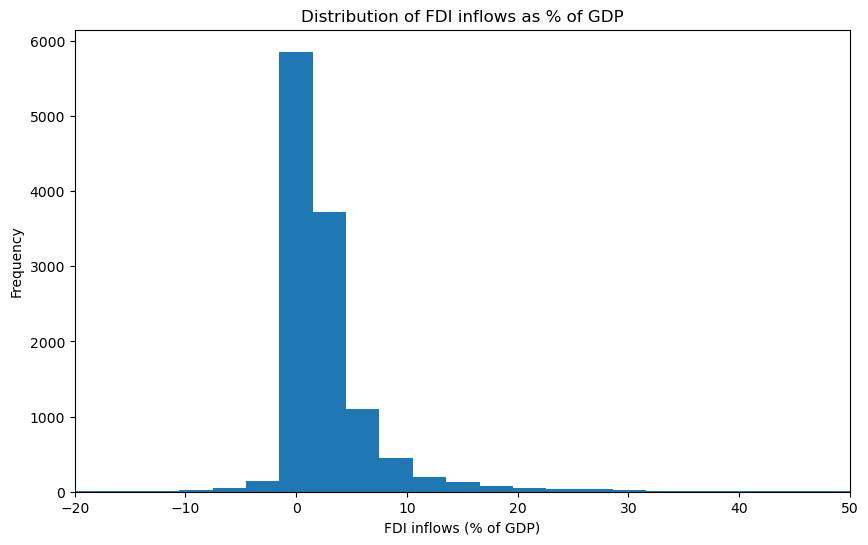

In [51]:
#distribution of FDI inflows as % of GDP
plt.figure(figsize=(10,6))
plt.hist(fdi_long["fdi_inflows_pct_gdp"].dropna(), bins = 1000)
# cut off extreme values just for visualization purposes
plt.xlim(-20,50)
plt.title("Distribution of FDI inflows as % of GDP")
plt.xlabel("FDI inflows (% of GDP)")   
plt.ylabel("Frequency")
plt.show()

In [52]:
#Check extreme values
fdi_long.sort_values("fdi_inflows_pct_gdp", ascending=False).head(10)

,iso3,year,fdi_inflows_pct_gdp
14682,CYM,2015,1709.827224
14767,LIE,2015,1282.607229
12373,LIE,2006,1114.932386
14416,CYM,2014,1009.031058
15033,LIE,2016,972.693539
10777,LIE,2000,799.333943
14150,CYM,2013,792.319791
13618,CYM,2011,743.700693
12639,LIE,2007,728.865660
13171,LIE,2009,664.573767


In [53]:
fdi_long.sort_values("fdi_inflows_pct_gdp", ascending=True).head(10)

,iso3,year,fdi_inflows_pct_gdp
15565,LIE,2018,-1303.108267
16636,LUX,2022,-391.555119
16013,CYP,2020,-296.013199
17077,CYP,2024,-133.824279
15572,LUX,2018,-117.233948
9707,LBR,1996,-82.892095
16811,CYP,2023,-63.154669
12646,LUX,2007,-57.532314
7934,SUR,1989,-55.234058
16544,CYM,2022,-47.217122


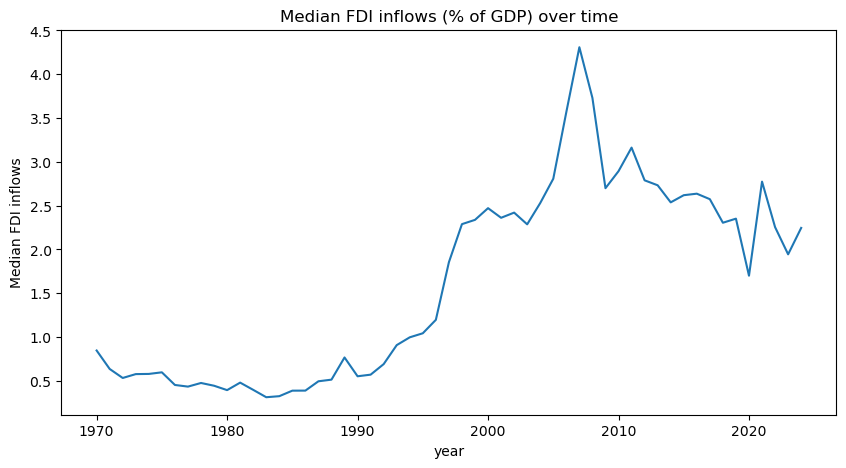

In [54]:
fdi_long.groupby("year")["fdi_inflows_pct_gdp"].median().plot(figsize=(10,5))
plt.title("Median FDI inflows (% of GDP) over time")
plt.ylabel("Median FDI inflows")
plt.show()

### 6.2 WGI Control of Corruption
This section explores the distribution and basic properties of the institutional corruption measure Control of Corruption.

In [55]:
wgi["control_of_corruption"].describe()

count    5373.000000
mean       -0.000039
std         0.999048
min        -2.064721
25%        -0.778373
50%        -0.189896
75%         0.761415
max         2.483859
Name: control_of_corruption, dtype: float64

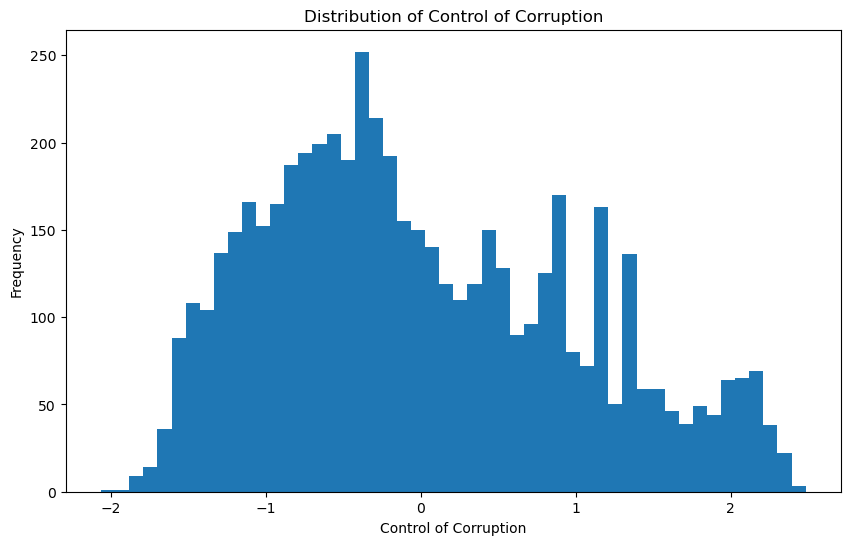

In [56]:
#distribution of CCP
plt.figure(figsize=(10,6))
plt.hist(wgi["control_of_corruption"].dropna(), bins = 50)
plt.title("Distribution of Control of Corruption")
plt.xlabel("Control of Corruption")   
plt.ylabel("Frequency")
plt.show()

In [57]:
# Missing values

wgi.isna().sum()

iso3                     0
year                     0
control_of_corruption    0
dtype: int64

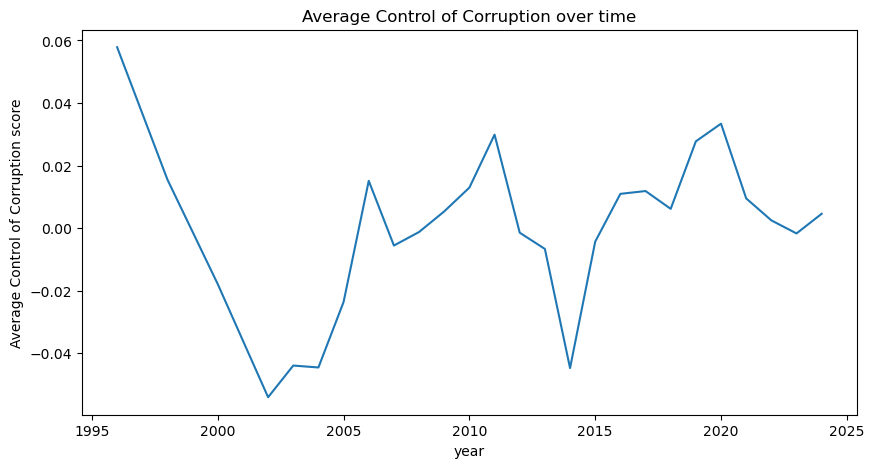

In [58]:
wgi.groupby("year")["control_of_corruption"].mean().plot(figsize=(10,5))
plt.title("Average Control of Corruption over time")
plt.ylabel("Average Control of Corruption score")
plt.show() 

### 6.3 WVS Waves 6 + 7 Perception of Corruption
This section explores the distribution of basic properties of our perception of corruption variable.

In [59]:
wvs_perception["corr_proxy_std"].describe()


count    108.000000
mean       0.024728
std        0.488707
min       -1.659767
25%       -0.293654
50%        0.064504
75%        0.396989
max        1.020460
Name: corr_proxy_std, dtype: float64

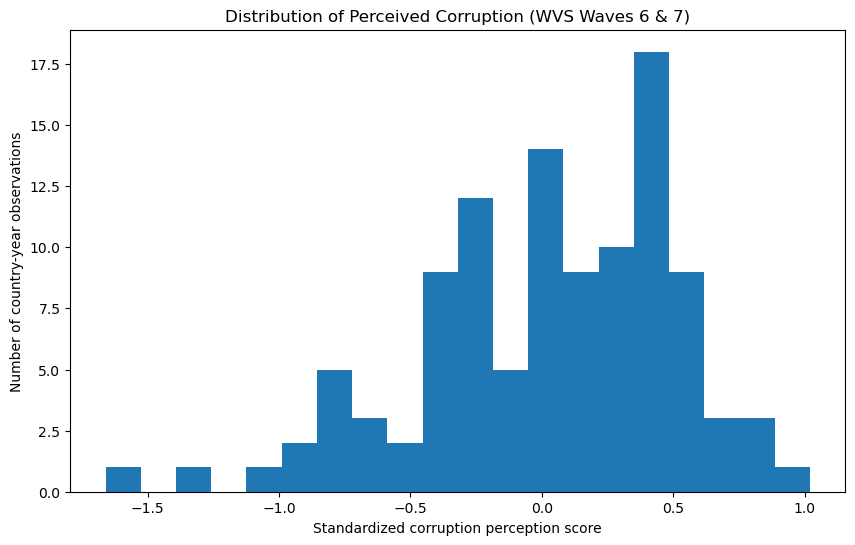

In [60]:
plt.figure(figsize=(10,6))
plt.hist(wvs_perception["corr_proxy_std"].dropna(), bins=20)
plt.title("Distribution of Perceived Corruption (WVS Waves 6 & 7)")
plt.xlabel("Standardized corruption perception score")
plt.ylabel("Number of country-year observations")
plt.show()

In [61]:
wvs_perception["corr_proxy_std"].isna().sum()


np.int64(18)

In [62]:
wvs_perception.sort_values("corr_proxy_std").head(5)


,iso3,year,corr_proxy_std,wave
111,SGP,2020,-1.659767,7
10,DEU,2013,-1.316927,6
34,NLD,2012,-1.051074,6
2,AUS,2012,-0.881762,6
80,HKG,2018,-0.879403,7


In [63]:
wvs_perception.sort_values("corr_proxy_std", ascending=False).head(5)

,iso3,year,corr_proxy_std,wave
19,HTI,2016,1.020460,6
106,PER,2018,0.777992,7
70,COL,2018,0.766227,7
66,BRA,2018,0.756637,7
108,PRI,2018,0.716605,7


## 7. Merge Diagnostics
In this section, the cleaned datasets are merged to construct the initial country-year analysis panel. We start by combining the target variable (FDI inflows) with the institutional corruption measure (Control of Corruption).

In [64]:
fdi_panel = fdi_long.copy()
wgi_panel = wgi.copy()
wvs_panel = wvs_perception.copy()
gdp_pc_panel = gdp_pc_long.copy()
inflation_panel = inflation_long.copy()
trade_openness_panel = trade_openness_long.copy()

# Ensuring consistent key names
fdi_panel = fdi_panel.rename(columns={"iso3": "iso3", "year": "year"})
wgi_panel = wgi_panel.rename(columns={"iso3": "iso3", "year": "year"})
wvs_panel = wvs_panel.rename(columns={"iso3": "iso3", "year": "year"})
gdp_pc_panel = gdp_pc_panel.rename(columns={"iso3": "iso3", "year": "year"})
inflation_panel = inflation_panel.rename(columns={"iso3": "iso3", "year": "year"})
trade_openness_panel = trade_openness_panel.rename(columns={"iso3": "iso3", "year": "year"})


panel = pd.merge(
    fdi_panel,
    wgi_panel[["iso3", "year", "control_of_corruption"]],
    on = ["iso3", "year"],
    how = "left"
)

panel2 = pd.merge(
    panel,
    wvs_panel[["iso3", "year", "corr_proxy_std"]],
    on = ["iso3", "year"],
    how = "left"
)

panel3 = pd.merge(
    panel2,
    gdp_pc_panel[["iso3", "year", "gdp_per_capita"]],
    on = ["iso3", "year"],
    how = "left"
)

panel4 = pd.merge(
    panel3,
    inflation_panel[["iso3", "year", "inflation"]],
    on = ["iso3", "year"],
    how = "left"
)

full_panel = pd.merge(
    panel4,
    trade_openness_panel[["iso3", "year", "trade_openness"]],
    on = ["iso3", "year"],
    how = "left"
)

full_panel.head()

,iso3,year,fdi_inflows_pct_gdp,control_of_corruption,corr_proxy_std,gdp_per_capita,inflation,trade_openness
0,ABW,1960,NaN,NaN,NaN,NaN,NaN,NaN
1,AFE,1960,NaN,NaN,NaN,186.089204,NaN,NaN
2,AFG,1960,NaN,NaN,NaN,NaN,NaN,NaN
3,AFW,1960,NaN,NaN,NaN,121.936832,NaN,33.02326
4,AGO,1960,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
full_panel.shape


(17290, 8)

In [66]:
full_panel.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17290 entries, 0 to 17289
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   iso3                   17290 non-null  object 
 1   year                   17290 non-null  int64  
 2   fdi_inflows_pct_gdp    12070 non-null  float64
 3   control_of_corruption  5175 non-null   float64
 4   corr_proxy_std         105 non-null    float64
 5   gdp_per_capita         14561 non-null  float64
 6   inflation              11295 non-null  float64
 7   trade_openness         10929 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 1.1+ MB


In [67]:
full_panel.isna().sum()


iso3                         0
year                         0
fdi_inflows_pct_gdp       5220
control_of_corruption    12115
corr_proxy_std           17185
gdp_per_capita            2729
inflation                 5995
trade_openness            6361
dtype: int64

In [68]:
full_panel["year"].min(), full_panel["year"].max()

(1960, 2024)

## 8. Relationships Between Variables

### 8.1 Institutional Corruption vs FDI

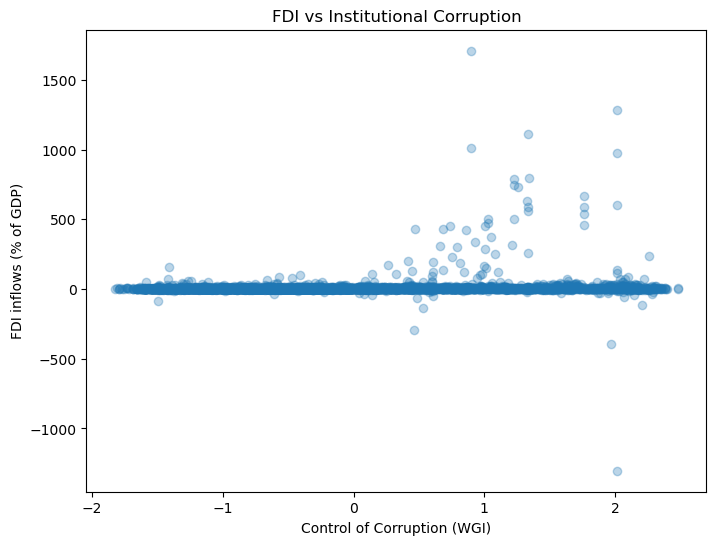

In [69]:
subset_wgi = full_panel.dropna(subset=["control_of_corruption", "fdi_inflows_pct_gdp"])

plt.figure(figsize=(8,6))
plt.scatter(subset_wgi["control_of_corruption"],
            subset_wgi["fdi_inflows_pct_gdp"],
            alpha=0.3)

plt.xlabel("Control of Corruption (WGI)")
plt.ylabel("FDI inflows (% of GDP)")
plt.title("FDI vs Institutional Corruption")
plt.show()

**Findings**

-No clear linear relationship visible.

-FDI is heavily clustered near zero with several extreme outliers.

-Outliers dominate the scale and hide subtle patterns.

**Implications**

-FDI outliers may distort modeling.

-Relationship likely weak or nonlinear in raw data.

### 8.2 Perceived Corruption vs 

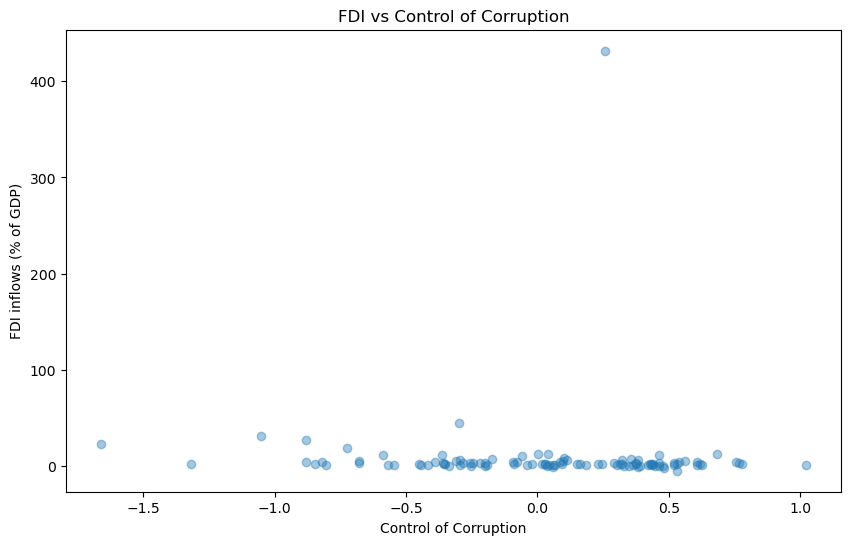

In [70]:
plt.figure(figsize=(10,6))
plt.scatter(full_panel["corr_proxy_std"], full_panel["fdi_inflows_pct_gdp"], alpha=0.4)
plt.xlabel("Control of Corruption")
plt.ylabel("FDI inflows (% of GDP)")
plt.title("FDI vs Control of Corruption")
plt.show()

**Findings**

-Again no clear linear pattern.

-Most FDI values are close to zero.

-Fewer observations due to limited WVS coverage.

**Implications**

-Perceived corruption may contain signal, but not visible without transformation.

-Outlier handling for FDI will be important.

### 8.3 Institutional vs Perceived Corruption

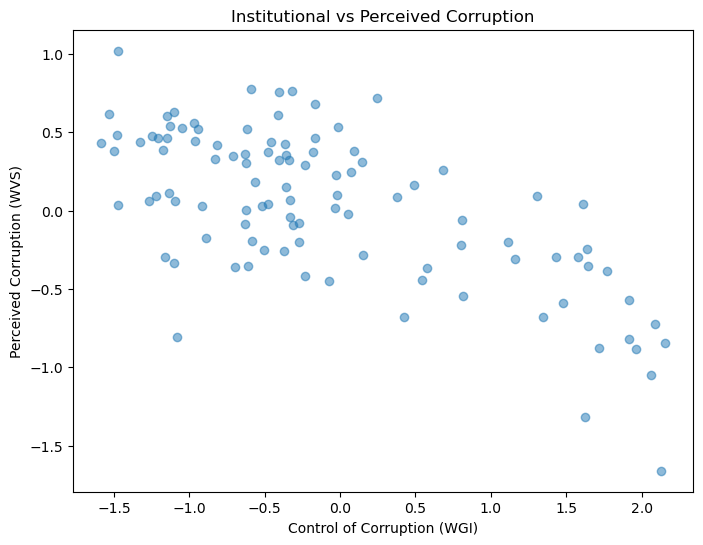

In [71]:
subset_corr = full_panel.dropna(subset=["control_of_corruption", "corr_proxy_std"])

plt.figure(figsize=(8,6))
plt.scatter(subset_corr["control_of_corruption"],
            subset_corr["corr_proxy_std"],
            alpha=0.5)

plt.xlabel("Control of Corruption (WGI)")
plt.ylabel("Perceived Corruption (WVS)")
plt.title("Institutional vs Perceived Corruption")
plt.show()


**Findings**

-Clear negative relationship.

-Countries with better institutional scores tend to report lower perceived corruption.

**Implications**

-Measures are related but not identical.

-Possible multicollinearity risk if both are used together.

### 8.4 Correlation Matrix (Overlapping Data Only)

In [72]:
subset_all = full_panel.dropna(subset=[
    "fdi_inflows_pct_gdp",
    "control_of_corruption",
    "corr_proxy_std"
])

subset_all[[
    "fdi_inflows_pct_gdp",
    "control_of_corruption",
    "corr_proxy_std"
]].corr()


,fdi_inflows_pct_gdp,control_of_corruption,corr_proxy_std
fdi_inflows_pct_gdp,1.000000,0.146066,-0.010692
control_of_corruption,0.146066,1.000000,-0.689442
corr_proxy_std,-0.010692,-0.689442,1.000000


**Findings**

-Strong negative correlation between institutional and perceived corruption (≈ -0.69).

-Very weak correlation between FDI and both corruption measures.

**Implications**

-Corruption variables capture similar governance concepts.

-Simple linear relationship with FDI is weak.

## 9. Risk Assessment and Modelin Implications

This section summarizes the key risks and structural characteristics identified during EDA that may influence preprocessing and modeling choices in later sprints.

### 9.1 Target Variable Risks (FDI)

-FDI inflows (% of GDP) are very unevenly distributed and contain several extreme values.

-Most country-year observations are close to zero, while a few have very large positive or negative values.

Implications:

-These extreme values could strongly influence models.

-Later we may need to use transformations or robust methods to reduce their impact.

### 9.2 Feature Risks (Corruption Measures)

-The institutional corruption measure (WGI) changes slowly over time and shows more differences between countries than within countries.

-The perceived corruption measure (WVS) is only available in specific survey years, so the time coverage is limited.

-Institutional and perceived corruption are strongly related, but they are not the same measure.

Implications:

-Perceived corruption data will reduce the number of usable observations in models.

-Using both corruption measures together may create multicollinearity, which needs to be checked later.


### 9.3 Panel Structure Risks

-The merged dataset forms an unbalanced panel, meaning not all countries have data for all years.

-Different variables cover different time periods:

--FDI covers many years

--WGI starts later

--WVS only appears in survey years

Implications:

-The final modeling dataset will be smaller than the full panel.

-Time-based analysis may be limited because perception data are not available every year.


### 9.4 Data Leakage Check

-No variables are directly derived from FDI inflows.

-The corruption measures are conceptually related to governance but are not mechanically linked to FDI.

Implications:

-There is no obvious risk of data leakage at this stage.

### 9.5 Overall Data Suitability

-The datasets are well structured and correctly merged at the country-year level.

-The main variables show realistic patterns and meaningful variation.

-Even though there are missing values and outliers, the data are suitable for studying the relationship between corruption and FDI.

### 9.6 Modeling Sample Considerations

-In later stages, two main models will be estimated to predict FDI inflows:
one using perceived corruption and one using institutional corruption.

-The perceived corruption model will be based on a smaller number of country-year observations due to the limited coverage of WVS survey data.

-The institutional corruption model can use a larger sample because WGI data are available annually for more countries and years.

-To ensure a fair comparison, additional robustness models will be estimated using only the overlapping country-year observations available for both corruption measures.

-This allows comparison of model performance both in realistic settings (using all available data) and under controlled conditions (same sample size).

-If the number of overlapping country-year observations for perceived corruption is too small for stable modeling, an additional robustness step may include incorporating WVS Wave 5 to increase temporal and country coverage of the perception measure, provided the available items are conceptually comparable.

## 10. Sprint 1 Summary

This sprint focused on Exploratory Data Analysis (EDA) to understand the structure, quality, and patterns of the datasets used to study the relationship between corruption and FDI.

**Main findings**

-The FDI variable shows a highly skewed distribution with several extreme outliers, while most observations are close to zero.

-Institutional corruption (WGI) is relatively stable over time and varies more across countries than within countries.

-Perceived corruption (WVS) is only available in specific survey years, resulting in limited temporal coverage.

-Institutional and perceived corruption are strongly related but not identical, suggesting they capture different aspects of corruption.

-No strong linear relationship between corruption measures and FDI is visible in raw data.

**Data quality and structure**

-All datasets were successfully converted to a country-year format and merged using consistent country and year identifiers.

-The final merged panel is strongly unbalanced due to differences in data availability across variables.

-Missing values mainly reflect real data limitations rather than technical errors.

-No duplicate country-year observations or missing merge keys were found.

**Identified risks**

-Extreme FDI outliers may distort model estimation.

-The perception dataset has limited coverage, which reduces the effective modeling sample.

-Institutional and perceived corruption are correlated, which may create multicollinearity in later models.

-The panel structure is irregular across time and countries.

**Implications for next sprint**

-Later preprocessing may include handling extreme FDI values using robust methods or transformations.

-Modeling will need to account for the unbalanced panel and missing perception data.

-Both institutional and perceived corruption will be tested as predictors of FDI, including additional robustness models using only overlapping observations.

-If the perception sample proves too small for stable modeling, Wave 5 may be added to extend coverage.

**Overall conclusion**

-The datasets are structurally sound, conceptually aligned with the research question, and suitable for further modeling.

-Despite missingness and outliers, the data provide meaningful variation in both corruption and FDI, supporting the feasibility of the planned analysis.

# Sprint 3: Interim modeling pipeline

## 1. Step 1: Define initial modeling setup

The first interim modeling cycle is structured in two layers. First, each specification is estimated on its maximum available sample to assess overall predictive performance under the available data constraints. Second, to enable a fair direct comparison between institutional and perceived corruption, the institutional-corruption models are also estimated on the exact same country-year observations as the perceived-corruption models.

The first modeling cycle includes four main specifications: 
- institutional corruption without controls
- perceived corruption without controls
- institutional corruption with controls
- and perceived corruption with controls. 

In the controlled specifications, GDP per capita, inflation, and trade openness are included as macroeconomic controls. This makes it possible to compare both the raw predictive value of the corruption measures and their predictive contribution conditional on broader economic conditions.




## 2. Step 2. Construct model-ready datasets

This step constructs the model-ready datasets used in the first interim modeling cycle. Separate datasets are created for institutional corruption and perceived corruption, both with and without macroeconomic controls. In addition, matched-sample versions of the institutional-corruption datasets are created using the exact same country-year observations as the corresponding perceived-corruption datasets. This allows both maximum-sample comparisons and direct like-for-like comparisons between the two corruption measures.

In [73]:
wgi_nocontrols_max = full_panel[["iso3", "year", "fdi_inflows_pct_gdp", "control_of_corruption"]].dropna().copy()

wvs_nocontrols = full_panel[["iso3", "year", "fdi_inflows_pct_gdp", "corr_proxy_std"]].dropna().copy()

wgi_controls_max = full_panel[["iso3", "year", "fdi_inflows_pct_gdp", "control_of_corruption", "gdp_per_capita", "inflation", "trade_openness"]].dropna().copy()

wvs_controls = full_panel[["iso3", "year", "fdi_inflows_pct_gdp", "corr_proxy_std", "gdp_per_capita", "inflation", "trade_openness"]].dropna().copy()

In [74]:
# Matched sample keys from WVS Datasets

wvs_nocontrols_keys = wvs_nocontrols[["iso3", "year"]].drop_duplicates()
wvs_controls_keys = wvs_controls[["iso3", "year"]].drop_duplicates()

# Match WGI Datasets to the exact WVS country-year observations

wgi_nocontrols_matched = pd.merge(
    wgi_nocontrols_max,
    wvs_nocontrols_keys,
    on = ["iso3", "year"],
    how = "inner"
)

wgi_controls_matched = pd.merge(
    wgi_controls_max,
    wvs_controls_keys,
    on = ["iso3", "year"],
    how = "inner"
)

In [75]:
print("wgi_nocontrols_max:", wgi_nocontrols_max.shape)
print("wvs_nocontrols:", wvs_nocontrols.shape)
print("wgi_controls_max:", wgi_controls_max.shape)
print("wvs_controls:", wvs_controls.shape)
print("wgi_nocontrols_matched:", wgi_nocontrols_matched.shape)
print("wgi_controls_matched:", wgi_controls_matched.shape)

wgi_nocontrols_max: (4937, 4)
wvs_nocontrols: (103, 4)
wgi_controls_max: (4009, 7)
wvs_controls: (96, 7)
wgi_nocontrols_matched: (103, 4)
wgi_controls_matched: (96, 7)


## 3. Step 3. Inspect sample sizes and overlap

Before estimating the first models, the structure of each model-ready dataset is inspected. This includes the number of observations, the number of countries, and the year range. These checks are important because the institutional and perceived corruption measures differ substantially in data availability, and the inclusion of macroeconomic controls may further reduce the usable sample.

In [76]:
# Sample summary function

def summarize_dataset(df, name):
    return {
        "dataset": name,
        "n_rows": len(df),
        "n_countries": df["iso3"].nunique(),
        "year_min": df["year"].min(),
        "year_max": df["year"].max()
    }



In [77]:
sample_summary = pd.DataFrame([
    summarize_dataset(wgi_nocontrols_max, "wgi_nocontrols_max"),
    summarize_dataset(wvs_nocontrols, "wvs_nocontrols"),
    summarize_dataset(wgi_controls_max, "wgi_controls_max"),
    summarize_dataset(wvs_controls, "wvs_controls"),
    summarize_dataset(wgi_nocontrols_matched, "wgi_nocontrols_matched"),
    summarize_dataset(wgi_controls_matched, "wgi_controls_matched"),
])

sample_summary

,dataset,n_rows,n_countries,year_min,year_max
0,wgi_nocontrols_max,4937,198,1996,2024
1,wvs_nocontrols,103,74,2011,2023
2,wgi_controls_max,4009,174,1996,2024
3,wvs_controls,96,69,2011,2023
4,wgi_nocontrols_matched,103,74,2011,2023
5,wgi_controls_matched,96,69,2011,2023


In [78]:
# Compare WGI and WVS sample shrinkage

print("WGI no-controls rows:", len(wgi_nocontrols_max))
print("WVS no-controls rows:", len(wvs_nocontrols))
print("WGI with-controls rows:", len(wgi_controls_max))
print("WVS with-controls rows:", len(wvs_controls))

print("\nSample reduction after adding controls:")
print("WGI reduction:", len(wgi_nocontrols_max) - len(wgi_controls_max))
print("WVS reduction:", len(wvs_nocontrols) - len(wvs_controls))

WGI no-controls rows: 4937
WVS no-controls rows: 103
WGI with-controls rows: 4009
WVS with-controls rows: 96

Sample reduction after adding controls:
WGI reduction: 928
WVS reduction: 7


In [79]:
# Check direct matched-sample comparability

print("Matched no-controls same rows as WVS:",
      len(wgi_nocontrols_matched) == len(wvs_nocontrols))

print("Matched controls same rows as WVS:",
      len(wgi_controls_matched) == len(wvs_controls))

print("\nMatched sample sizes:")
print("No-controls matched rows:", len(wgi_nocontrols_matched))
print("Controls matched rows:", len(wgi_controls_matched))

Matched no-controls same rows as WVS: True
Matched controls same rows as WVS: True

Matched sample sizes:
No-controls matched rows: 103
Controls matched rows: 96


## 4. Step 4. Baseline model (OLS)

In this step, the baseline model is estimated using Ordinary Least Squares (OLS). The purpose of this first modeling cycle is to establish a simple and interpretable benchmark before comparing it to a more flexible model in the next step. The baseline model is evaluated using five-fold cross-validation and the performance metrics defined in Sprint 2: RMSE, MAE, and out-of-sample R².

The baseline is estimated for both corruption measures, with and without macroeconomic controls, and both on the maximum available samples and on the matched-sample specifications used for direct comparison.

In [80]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_validate

In [81]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae" : "neg_mean_absolute_error",
    "r2" : "r2"
}

## OLS

In [82]:
def run_ols_cv(df, features, target="fdi_inflows_pct_gdp", name="model"):
    X = df[features]
    y = df[target]

    model = LinearRegression()

    cv_results = cross_validate(
        model,
        X=X,
        y=y,
        cv=kf,
        scoring=scoring,
        return_train_score=False
    )

    return {
        "model_name": name,
        "n_rows": len(df),
        "n_countries": df["iso3"].nunique(),
        "rmse_mean": -np.mean(cv_results["test_rmse"]),
        "rmse_std": np.std(-cv_results["test_rmse"]),
        "mae_mean": -np.mean(cv_results["test_mae"]),
        "mae_std": np.std(-cv_results["test_mae"]),
        "r2_mean": np.mean(cv_results["test_r2"]),
        "r2_std": np.std(cv_results["test_r2"])
    }

In [83]:
features_wgi_nocontrols = ["control_of_corruption"]
features_wvs_nocontrols = ["corr_proxy_std"]

features_wgi_controls = [
    "control_of_corruption",
    "gdp_per_capita",
    "inflation",
    "trade_openness"
]

features_wvs_controls = [
    "corr_proxy_std",
    "gdp_per_capita",
    "inflation",
    "trade_openness"
]

In [84]:
# Run OLS on max sample datasets

ols_results_max = pd.DataFrame([
    run_ols_cv(
        wgi_nocontrols_max,
        features_wgi_nocontrols,
        name="OLS_WGI_nocontrols_max"
    ),
    run_ols_cv(
        wvs_nocontrols,
        features_wvs_nocontrols,
        name="OLS_WVS_nocontrols"
    ),
    run_ols_cv(
        wgi_controls_max,
        features_wgi_controls,
        name="OLS_WGI_controls_max"
    ),
    run_ols_cv(
        wvs_controls,
        features_wvs_controls,
        name="OLS_WVS_controls"
    )
])

ols_results_max.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,OLS_WGI_nocontrols_max,4937,198,58.5939,11.6237,11.8423,1.2633,0.0089,0.0059
1,OLS_WVS_nocontrols,103,74,26.2754,34.8981,11.3148,7.3011,-0.7307,0.6250
2,OLS_WGI_controls_max,4009,174,22.7268,4.2234,5.7198,0.3063,0.0394,0.0279
3,OLS_WVS_controls,96,69,49.0345,43.4191,17.8927,9.3760,-183.6171,356.7598


In [85]:
# Run OLS on matched sample datasets

ols_results_matched = pd.DataFrame([
    run_ols_cv(
        wgi_nocontrols_matched,
        features_wgi_nocontrols,
        name="OLS_WGI_nocontrols_matched"
    ),
    run_ols_cv(
        wvs_nocontrols,
        features_wvs_nocontrols,
        name="OLS_WVS_nocontrols"
    ),
    run_ols_cv(
        wgi_controls_matched,
        features_wgi_controls,
        name="OLS_WGI_controls_matched"
    ),
    run_ols_cv(
        wvs_controls,
        features_wvs_controls,
        name="OLS_WVS_controls"
    )
])

ols_results_matched.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,OLS_WGI_nocontrols_matched,103,74,26.2674,34.4756,10.4863,7.0207,-0.7563,0.6152
1,OLS_WVS_nocontrols,103,74,26.2754,34.8981,11.3148,7.3011,-0.7307,0.6250
2,OLS_WGI_controls_matched,96,69,50.9639,49.4234,16.2804,11.8427,-243.8844,481.5823
3,OLS_WVS_controls,96,69,49.0345,43.4191,17.8927,9.3760,-183.6171,356.7598


## 5. Step 5. Regularized models (Ridge & Lasso)

In this step, two regularized linear models are estimated: Ridge and Lasso. These models extend the OLS baseline by applying coefficient shrinkage, which can improve predictive stability when the sample is limited and predictors are correlated. This is especially relevant for the present thesis, because the matched-sample and controlled specifications contain relatively few observations and may be sensitive to overfitting.

Ridge regression shrinks coefficients continuously toward zero, while Lasso regression can additionally shrink some coefficients exactly to zero. Both models are evaluated using the same five-fold cross-validation procedure and the same performance metrics as the OLS baseline: RMSE, MAE, and out-of-sample R².

Because Ridge and Lasso are sensitive to variable scale, all predictors are standardized within a pipeline. The regularization parameter is selected automatically within the model-fitting process.

In [86]:
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## Ridge

In [87]:
def run_ridge_cv(df, features, target="fdi_inflows_pct_gdp", name="model"):
    X = df[features]
    y = df[target]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5))
    ])

    cv_results = cross_validate(
        model,
        X,
        y,
        cv=kf,
        scoring=scoring,
        return_train_score=False
    )

    return {
        "model_name": name,
        "n_rows": len(df),
        "n_countries": df["iso3"].nunique(),
        "rmse_mean": -np.mean(cv_results["test_rmse"]),
        "rmse_std": np.std(-cv_results["test_rmse"]),
        "mae_mean": -np.mean(cv_results["test_mae"]),
        "mae_std": np.std(-cv_results["test_mae"]),
        "r2_mean": np.mean(cv_results["test_r2"]),
        "r2_std": np.std(cv_results["test_r2"])
    }

In [88]:
# Run Ridge on max sample datasets

ridge_results_max = pd.DataFrame([
    run_ridge_cv(
        wgi_nocontrols_max,
        features_wgi_nocontrols,
        name="Ridge_WGI_nocontrols_max"
    ),
    run_ridge_cv(
        wvs_nocontrols,
        features_wvs_nocontrols,
        name="Ridge_WVS_nocontrols"
    ),
    run_ridge_cv(
        wgi_controls_max,
        features_wgi_controls,
        name="Ridge_WGI_controls_max"
    ),
    run_ridge_cv(
        wvs_controls,
        features_wvs_controls,
        name="Ridge_WVS_controls"
    )
])

ridge_results_max.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,Ridge_WGI_nocontrols_max,4937,198,58.5999,11.6456,11.5600,1.2753,0.0088,0.0045
1,Ridge_WVS_nocontrols,103,74,26.1042,34.9410,11.1407,7.2496,-0.6430,0.5236
2,Ridge_WGI_controls_max,4009,174,22.7373,4.2589,5.5818,0.3575,0.0390,0.0240
3,Ridge_WVS_controls,96,69,33.6469,35.6301,12.3411,7.7841,-38.6664,74.3363


In [89]:
# Run ridge on matched sample datasets

ridge_results_matched = pd.DataFrame([
    run_ridge_cv(
        wgi_nocontrols_matched,
        features_wgi_nocontrols,
        name="Ridge_WGI_nocontrols_matched"
    ),
    run_ridge_cv(
        wvs_nocontrols,
        features_wvs_nocontrols,
        name="Ridge_WVS_nocontrols"
    ),
    run_ridge_cv(
        wgi_controls_matched,
        features_wgi_controls,
        name="Ridge_WGI_controls_matched"
    ),
    run_ridge_cv(
        wvs_controls,
        features_wvs_controls,
        name="Ridge_WVS_controls"
    )
])

ridge_results_matched.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,Ridge_WGI_nocontrols_matched,103,74,25.6582,34.8610,10.6590,6.9006,-0.5021,0.4622
1,Ridge_WVS_nocontrols,103,74,26.1042,34.9410,11.1407,7.2496,-0.6430,0.5236
2,Ridge_WGI_controls_matched,96,69,29.0420,34.8448,11.0595,7.4573,-12.2422,22.0503
3,Ridge_WVS_controls,96,69,33.6469,35.6301,12.3411,7.7841,-38.6664,74.3363


## Lasso

In [90]:
def run_lasso_cv(df, features, target="fdi_inflows_pct_gdp", name="model"):
    X = df[features]
    y = df[target]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", LassoCV(alphas=np.logspace(-3, 1, 50), cv=5, random_state=42, max_iter=10000))
    ])

    cv_results = cross_validate(
        model,
        X,
        y,
        cv=kf,
        scoring=scoring,
        return_train_score=False
    )

    return {
        "model_name": name,
        "n_rows": len(df),
        "n_countries": df["iso3"].nunique(),
        "rmse_mean": -np.mean(cv_results["test_rmse"]),
        "rmse_std": np.std(-cv_results["test_rmse"]),
        "mae_mean": -np.mean(cv_results["test_mae"]),
        "mae_std": np.std(-cv_results["test_mae"]),
        "r2_mean": np.mean(cv_results["test_r2"]),
        "r2_std": np.std(cv_results["test_r2"])
    }

In [91]:
# Run Lasso on max sample datasets

lasso_results_max = pd.DataFrame([
    run_lasso_cv(
        wgi_nocontrols_max,
        features_wgi_nocontrols,
        name="Lasso_WGI_nocontrols_max"
    ),
    run_lasso_cv(
        wvs_nocontrols,
        features_wvs_nocontrols,
        name="Lasso_WVS_nocontrols"
    ),
    run_lasso_cv(
        wgi_controls_max,
        features_wgi_controls,
        name="Lasso_WGI_controls_max"
    ),
    run_lasso_cv(
        wvs_controls,
        features_wvs_controls,
        name="Lasso_WVS_controls"
    )
])

lasso_results_max.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,Lasso_WGI_nocontrols_max,4937,198,58.5927,11.6249,11.8322,1.2682,0.0089,0.0059
1,Lasso_WVS_nocontrols,103,74,26.1094,34.9811,11.1824,7.3575,-0.6368,0.5165
2,Lasso_WGI_controls_max,4009,174,22.7384,4.2731,5.5848,0.3633,0.0391,0.0272
3,Lasso_WVS_controls,96,69,38.6099,37.1258,13.8661,7.9128,-74.4685,145.1892


In [92]:
# Run Lasso on matched sample datasets

lasso_results_matched = pd.DataFrame([
    run_lasso_cv(
        wgi_nocontrols_matched,
        features_wgi_nocontrols,
        name="Lasso_WGI_nocontrols_matched"
    ),
    run_lasso_cv(
        wvs_nocontrols,
        features_wvs_nocontrols,
        name="Lasso_WVS_nocontrols"
    ),
    run_lasso_cv(
        wgi_controls_matched,
        features_wgi_controls,
        name="Lasso_WGI_controls_matched"
    ),
    run_lasso_cv(
        wvs_controls,
        features_wvs_controls,
        name="Lasso_WVS_controls"
    )
])

lasso_results_matched.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,Lasso_WGI_nocontrols_matched,103,74,26.0319,34.6092,10.7260,6.8470,-0.6581,0.5493
1,Lasso_WVS_nocontrols,103,74,26.1094,34.9811,11.1824,7.3575,-0.6368,0.5165
2,Lasso_WGI_controls_matched,96,69,49.5425,49.8701,16.3414,11.6194,-237.0103,470.1007
3,Lasso_WVS_controls,96,69,38.6099,37.1258,13.8661,7.9128,-74.4685,145.1892


## 6. Step 6: Tree-based advanced models (Random Forest and XGBoost)

In this step, the tree-based advanced models are estimated: Random Forest and XGBoost. These models are included because they were already part of the planned model set in the thesis proposal and because they can capture non-linear relationships and interaction effects that may not be handled well by linear models. This is particularly relevant in the present thesis, where corruption, macroeconomic conditions, and FDI inflows may be related in more complex ways.

Random Forest and XGBoost are evaluated using the same five-fold cross-validation procedure and the same performance metrics as the previous models: RMSE, MAE, and out-of-sample R². At this stage, the goal is not yet full hyperparameter tuning, but rather to compare the initial performance of the tree-based models with the baseline and regularized linear models.

This step therefore completes the first full planned model set, allowing comparison across linear, regularized, and tree-based approaches before moving on to refinement and robustness checks.


In [93]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

## Random Forest

In [94]:
def run_rf_cv(df, features, target="fdi_inflows_pct_gdp", name="model"):
    X = df[features]
    y = df[target]

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    cv_results = cross_validate(
        model,
        X=X,
        y=y,
        cv=kf,
        scoring=scoring,
        return_train_score=False
    )

    return {
        "model_name": name,
        "n_rows": len(df),
        "n_countries": df["iso3"].nunique(),
        "rmse_mean": -np.mean(cv_results["test_rmse"]),
        "rmse_std": np.std(-cv_results["test_rmse"]),
        "mae_mean": -np.mean(cv_results["test_mae"]),
        "mae_std": np.std(-cv_results["test_mae"]),
        "r2_mean": np.mean(cv_results["test_r2"]),
        "r2_std": np.std(cv_results["test_r2"])
    }

In [95]:
# Run RF on max sample datasets

rf_results_max = pd.DataFrame([
    run_rf_cv(
        wgi_nocontrols_max,
        features_wgi_nocontrols,
        name="RF_WGI_nocontrols_max"
    ),
    run_rf_cv(
        wvs_nocontrols,
        features_wvs_nocontrols,
        name="RF_WVS_nocontrols"
    ),
    run_rf_cv(
        wgi_controls_max,
        features_wgi_controls,
        name="RF_WGI_controls_max"
    ),
    run_rf_cv(
        wvs_controls,
        features_wvs_controls,
        name="RF_WVS_controls"
    )
])

rf_results_max.round(4)


,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,RF_WGI_nocontrols_max,4937,198,58.1467,9.9027,12.3389,1.2488,0.0102,0.0973
1,RF_WVS_nocontrols,103,74,37.6600,32.5437,13.7297,8.3125,-19.4812,28.5539
2,RF_WGI_controls_max,4009,174,22.0944,3.1549,5.5949,0.1632,0.0710,0.1329
3,RF_WVS_controls,96,69,33.4352,33.8259,10.7560,7.5822,-22.3365,41.6605


In [96]:
# Run RF on matched sample datasets

rf_results_matched = pd.DataFrame([
    run_rf_cv(
        wgi_nocontrols_matched,
        features_wgi_nocontrols,
        name="RF_WGI_nocontrols_matched"
    ),
    run_rf_cv(
        wvs_nocontrols,
        features_wvs_nocontrols,
        name="RF_WVS_nocontrols"
    ),
    run_rf_cv(
        wgi_controls_matched,
        features_wgi_controls,
        name="RF_WGI_controls_matched"
    ),
    run_rf_cv(
        wvs_controls,
        features_wvs_controls,
        name="RF_WVS_controls"
    )
])

rf_results_matched.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,RF_WGI_nocontrols_matched,103,74,36.7690,31.9231,12.5212,7.3572,-12.9692,15.7074
1,RF_WVS_nocontrols,103,74,37.6600,32.5437,13.7297,8.3125,-19.4812,28.5539
2,RF_WGI_controls_matched,96,69,33.5031,33.5905,10.7688,7.6079,-22.6046,42.0669
3,RF_WVS_controls,96,69,33.4352,33.8259,10.7560,7.5822,-22.3365,41.6605


## XGBoost

In [97]:
def run_xgb_cv(df, features, target="fdi_inflows_pct_gdp", name="model"):
    X = df[features]
    y = df[target]

    model = XGBRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    cv_results = cross_validate(
        model,
        X,
        y,
        cv=kf,
        scoring=scoring,
        return_train_score=False
    )

    return {
        "model_name": name,
        "n_rows": len(df),
        "n_countries": df["iso3"].nunique(),
        "rmse_mean": -np.mean(cv_results["test_rmse"]),
        "rmse_std": np.std(-cv_results["test_rmse"]),
        "mae_mean": -np.mean(cv_results["test_mae"]),
        "mae_std": np.std(-cv_results["test_mae"]),
        "r2_mean": np.mean(cv_results["test_r2"]),
        "r2_std": np.std(cv_results["test_r2"])
    }

In [98]:
# Run XGBoost on max sample datasets

xgb_results_max = pd.DataFrame([
    run_xgb_cv(
        wgi_nocontrols_max,
        features_wgi_nocontrols,
        name="XGB_WGI_nocontrols_max"
    ),
    run_xgb_cv(
        wvs_nocontrols,
        features_wvs_nocontrols,
        name="XGB_WVS_nocontrols"
    ),
    run_xgb_cv(
        wgi_controls_max,
        features_wgi_controls,
        name="XGB_WGI_controls_max"
    ),
    run_xgb_cv(
        wvs_controls,
        features_wvs_controls,
        name="XGB_WVS_controls"
    )
])

xgb_results_max.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,XGB_WGI_nocontrols_max,4937,198,58.8275,10.4485,12.2825,1.0031,-0.0117,0.0932
1,XGB_WVS_nocontrols,103,74,43.0524,42.1236,13.0298,9.5061,-56.0738,111.4130
2,XGB_WGI_controls_max,4009,174,22.2833,3.2155,6.1241,0.2007,0.0589,0.1091
3,XGB_WVS_controls,96,69,53.7792,33.7290,15.6005,8.2255,-156.0589,269.8080


In [99]:
# Run XGBoost on matched sample datasets

xgb_results_matched = pd.DataFrame([
    run_xgb_cv(
        wgi_nocontrols_matched,
        features_wgi_nocontrols,
        name="XGB_WGI_nocontrols_matched"
    ),
    run_xgb_cv(
        wvs_nocontrols,
        features_wvs_nocontrols,
        name="XGB_WVS_nocontrols"
    ),
    run_xgb_cv(
        wgi_controls_matched,
        features_wgi_controls,
        name="XGB_WGI_controls_matched"
    ),
    run_xgb_cv(
        wvs_controls,
        features_wvs_controls,
        name="XGB_WVS_controls"
    )
])

xgb_results_matched.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,XGB_WGI_nocontrols_matched,103,74,42.1170,42.6826,11.9863,9.7354,-56.9538,113.7738
1,XGB_WVS_nocontrols,103,74,43.0524,42.1236,13.0298,9.5061,-56.0738,111.4130
2,XGB_WGI_controls_matched,96,69,53.6783,32.7382,15.3360,8.0812,-148.9288,248.2060
3,XGB_WVS_controls,96,69,53.7792,33.7290,15.6005,8.2255,-156.0589,269.8080


## Step 7. Combine all models

### Max sample models

In [100]:
comparison_all_max = pd.concat(
    [
        ols_results_max,
        ridge_results_max,
        lasso_results_max,
        rf_results_max,
        xgb_results_max
    ],
    ignore_index=True
)

comparison_all_max.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,OLS_WGI_nocontrols_max,4937,198,58.5939,11.6237,11.8423,1.2633,0.0089,0.0059
1,OLS_WVS_nocontrols,103,74,26.2754,34.8981,11.3148,7.3011,-0.7307,0.6250
2,OLS_WGI_controls_max,4009,174,22.7268,4.2234,5.7198,0.3063,0.0394,0.0279
3,OLS_WVS_controls,96,69,49.0345,43.4191,17.8927,9.3760,-183.6171,356.7598
4,Ridge_WGI_nocontrols_max,4937,198,58.5999,11.6456,11.5600,1.2753,0.0088,0.0045
5,Ridge_WVS_nocontrols,103,74,26.1042,34.9410,11.1407,7.2496,-0.6430,0.5236
6,Ridge_WGI_controls_max,4009,174,22.7373,4.2589,5.5818,0.3575,0.0390,0.0240
7,Ridge_WVS_controls,96,69,33.6469,35.6301,12.3411,7.7841,-38.6664,74.3363
8,Lasso_WGI_nocontrols_max,4937,198,58.5927,11.6249,11.8322,1.2682,0.0089,0.0059
9,Lasso_WVS_nocontrols,103,74,26.1094,34.9811,11.1824,7.3575,-0.6368,0.5165


### Matched sample models

In [101]:
comparison_all_matched = pd.concat(
    [
        ols_results_matched,
        ridge_results_matched,
        lasso_results_matched,
        rf_results_matched,
        xgb_results_matched
    ],
    ignore_index=True
)

comparison_all_matched.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,OLS_WGI_nocontrols_matched,103,74,26.2674,34.4756,10.4863,7.0207,-0.7563,0.6152
1,OLS_WVS_nocontrols,103,74,26.2754,34.8981,11.3148,7.3011,-0.7307,0.6250
2,OLS_WGI_controls_matched,96,69,50.9639,49.4234,16.2804,11.8427,-243.8844,481.5823
3,OLS_WVS_controls,96,69,49.0345,43.4191,17.8927,9.3760,-183.6171,356.7598
4,Ridge_WGI_nocontrols_matched,103,74,25.6582,34.8610,10.6590,6.9006,-0.5021,0.4622
5,Ridge_WVS_nocontrols,103,74,26.1042,34.9410,11.1407,7.2496,-0.6430,0.5236
6,Ridge_WGI_controls_matched,96,69,29.0420,34.8448,11.0595,7.4573,-12.2422,22.0503
7,Ridge_WVS_controls,96,69,33.6469,35.6301,12.3411,7.7841,-38.6664,74.3363
8,Lasso_WGI_nocontrols_matched,103,74,26.0319,34.6092,10.7260,6.8470,-0.6581,0.5493
9,Lasso_WVS_nocontrols,103,74,26.1094,34.9811,11.1824,7.3575,-0.6368,0.5165


In [102]:
# Best model per specification max sample

best_models_max = comparison_all_max.sort_values("r2_mean").groupby("model_name").first().reset_index()
best_models_max.sort_values("r2_mean", ascending=False).round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
8,RF_WGI_controls_max,4009,174,22.0944,3.1549,5.5949,0.1632,0.0710,0.1329
16,XGB_WGI_controls_max,4009,174,22.2833,3.2155,6.1241,0.2007,0.0589,0.1091
4,OLS_WGI_controls_max,4009,174,22.7268,4.2234,5.7198,0.3063,0.0394,0.0279
0,Lasso_WGI_controls_max,4009,174,22.7384,4.2731,5.5848,0.3633,0.0391,0.0272
12,Ridge_WGI_controls_max,4009,174,22.7373,4.2589,5.5818,0.3575,0.0390,0.0240
9,RF_WGI_nocontrols_max,4937,198,58.1467,9.9027,12.3389,1.2488,0.0102,0.0973
1,Lasso_WGI_nocontrols_max,4937,198,58.5927,11.6249,11.8322,1.2682,0.0089,0.0059
5,OLS_WGI_nocontrols_max,4937,198,58.5939,11.6237,11.8423,1.2633,0.0089,0.0059
13,Ridge_WGI_nocontrols_max,4937,198,58.5999,11.6456,11.5600,1.2753,0.0088,0.0045
17,XGB_WGI_nocontrols_max,4937,198,58.8275,10.4485,12.2825,1.0031,-0.0117,0.0932


In [ ]:
# Best model per specification matched sample

best_models_matched = comparison_all_matched.sort_values("r2_mean").groupby("model_name").first().reset_index()
best_models_matched.sort_values("r2_mean", ascending=False).round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
13,Ridge_WGI_nocontrols_matched,103,74,25.6582,34.8610,10.6590,6.9006,-0.5021,0.4622
3,Lasso_WVS_nocontrols,103,74,26.1094,34.9811,11.1824,7.3575,-0.6368,0.5165
15,Ridge_WVS_nocontrols,103,74,26.1042,34.9410,11.1407,7.2496,-0.6430,0.5236
1,Lasso_WGI_nocontrols_matched,103,74,26.0319,34.6092,10.7260,6.8470,-0.6581,0.5493
7,OLS_WVS_nocontrols,103,74,26.2754,34.8981,11.3148,7.3011,-0.7307,0.6250
5,OLS_WGI_nocontrols_matched,103,74,26.2674,34.4756,10.4863,7.0207,-0.7563,0.6152
12,Ridge_WGI_controls_matched,96,69,29.0420,34.8448,11.0595,7.4573,-12.2422,22.0503
9,RF_WGI_nocontrols_matched,103,74,36.7690,31.9231,12.5212,7.3572,-12.9692,15.7074
11,RF_WVS_nocontrols,103,74,37.6600,32.5437,13.7297,8.3125,-19.4812,28.5539
10,RF_WVS_controls,96,69,33.4352,33.8259,10.7560,7.5822,-22.3365,41.6605


# Sprint 4: Refined modeling pipeline

## 1. Step 1: Correlation analysis and VIF diagnostics

The first refinement step in Sprint 4 is to examine whether multicollinearity may be contributing to instability in the linear models, especially in the controlled specifications. In line with Sprint 2, this step combines correlation analysis and variance inflation factors (VIF). Correlation analysis provides an initial view of pairwise relationships between the predictors, while VIF indicates whether any predictor can be strongly explained by the others together.

This diagnostic step is particularly relevant because Sprint 3 showed that Ridge often outperformed OLS in the smaller and more fragile specifications. If multicollinearity is present, this would help explain why regularization improves model stability.

### Correlation Analysis

In [103]:
# Before interpreting the correlation matrices, it is important to note that the two corruption measures are coded in opposite directions. 
# For the WGI Control of Corruption indicator, a higher value reflects stronger control of corruption and therefore less corruption. 
# By contrast, for the WVS-based perceived-corruption proxy, a higher value reflects more perceived corruption. 
# As a result, the sign of the correlations should be interpreted with caution when comparing the two measures directly. 
# This coding difference does not materially affect predictive model performance, but it does matter for descriptive interpretation.

# Therefore, for sprint 4 and correlation analyses, we will invert the WGI Control of Corruption scores so that a higher value means more corruption, to align with the WVS-based measure and facilitate interpretation.

wgi_controls_max["control_of_corruption_inverted"] = -wgi_controls_max["control_of_corruption"]
wgi_controls_matched["control_of_corruption_inverted"] = -wgi_controls_matched["control_of_corruption"]

In [104]:
# Correlation Analysis WGI max

features_wgi_controls_inverted = [
    "control_of_corruption_inverted",
    "gdp_per_capita",
    "inflation",
    "trade_openness"
]

wgi_controls_max[features_wgi_controls_inverted].corr().round(3)

,control_of_corruption_inverted,gdp_per_capita,inflation,trade_openness
control_of_corruption_inverted,1.000,-0.752,0.178,-0.336
gdp_per_capita,-0.752,1.000,-0.120,0.372
inflation,0.178,-0.120,1.000,-0.095
trade_openness,-0.336,0.372,-0.095,1.000


In [105]:
# Correlation Analysis WGI matched

wgi_controls_matched[features_wgi_controls_inverted].corr().round(3)

,control_of_corruption_inverted,gdp_per_capita,inflation,trade_openness
control_of_corruption_inverted,1.000,-0.790,0.130,-0.403
gdp_per_capita,-0.790,1.000,-0.094,0.401
inflation,0.130,-0.094,1.000,-0.078
trade_openness,-0.403,0.401,-0.078,1.000


In [106]:
# Correlation Analysis WVS

wvs_controls[features_wvs_controls].corr().round(3)

,corr_proxy_std,gdp_per_capita,inflation,trade_openness
corr_proxy_std,1.000,-0.641,0.085,-0.373
gdp_per_capita,-0.641,1.000,-0.094,0.401
inflation,0.085,-0.094,1.000,-0.078
trade_openness,-0.373,0.401,-0.078,1.000


### Variance Inflation Factor (VIF)

After the correlation analysis, Variance Inflation Factor (VIF) is used as a more formal diagnostic for multicollinearity. While correlations only show pairwise relationships between predictors, VIF indicates how strongly each predictor can be explained by the other predictors together. In other words, it helps assess whether a variable contains unique information or whether it overlaps heavily with the rest of the model.

A higher VIF suggests more multicollinearity. As a rough rule of thumb, values above 5 may indicate moderate multicollinearity, while values above 10 are often seen as problematic. In this thesis, VIF is mainly used to assess whether overlap between the corruption measures and the macroeconomic controls could help explain why regularized models such as Ridge performed better than OLS in some Sprint 3 specifications.

In [107]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(df, features):
    X = df[features].dropna().copy()

    vif_data = pd.DataFrame()
    vif_data["variable"] = X.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
    return vif_data


In [108]:
# VIF for WGI max sample

vif_wgi_controls_max = compute_vif(wgi_controls_max, features_wgi_controls_inverted)
vif_wgi_controls_max

,variable,VIF
0,control_of_corruption_inverted,1.965783
1,gdp_per_capita,3.156846
2,inflation,1.116928
3,trade_openness,2.041239


In [109]:
# VIF for WGI matched sample

vif_wgi_controls_matched = compute_vif(wgi_controls_matched, features_wgi_controls_inverted)
vif_wgi_controls_matched

,variable,VIF
0,control_of_corruption_inverted,1.737313
1,gdp_per_capita,3.079067
2,inflation,1.046002
3,trade_openness,2.115703


In [110]:
# VIF for WVS sample

vif_wvs_controls = compute_vif(wvs_controls, features_wvs_controls)
vif_wvs_controls

,variable,VIF
0,corr_proxy_std,1.352742
1,gdp_per_capita,2.449310
2,inflation,1.024219
3,trade_openness,1.994640


## 2. Step 2: Winsorize the FDI target and rebuild the model-ready datasets

The next refinement step in Sprint 4 is to reduce the influence of extreme values in the target variable. In both the thesis proposal and Sprint 2, FDI inflows were identified as right-skewed and potentially sensitive to outliers. Sprint 3 confirmed that some specifications showed very unstable out-of-sample performance, including strongly negative R² values, which may partly reflect the influence of extreme FDI observations.

To address this, the FDI target is winsorized. Winsorizing means that the most extreme values are capped at chosen percentile thresholds, rather than removed entirely. This keeps all observations in the sample while reducing the influence of unusually large or small values. After winsorizing, the relevant model-ready datasets are rebuilt so that performance can be compared directly with the original Sprint 3 results.

In [111]:
# Create a winsorized version of the FDI target. Using 1st and 99th percentiles as thresholds.

lower_bound = full_panel["fdi_inflows_pct_gdp"].quantile(0.01)
upper_bound = full_panel["fdi_inflows_pct_gdp"].quantile(0.99)

full_panel["fdi_inflows_pct_gdp_wins"] = full_panel["fdi_inflows_pct_gdp"].clip(lower=lower_bound, upper=upper_bound)

print("Lower winsorization bound:", lower_bound)
print("Upper winsorization bound:", upper_bound)

Lower winsorization bound: -4.546739247710082
Upper winsorization bound: 37.43897429456869


In [112]:
# Before and after check

print("Original FDI summary:")
print(full_panel["fdi_inflows_pct_gdp"].describe())

print("\nWinsorized FDI summary:")
print(full_panel["fdi_inflows_pct_gdp_wins"].describe())

Original FDI summary:
count    12070.000000
mean         4.638811
std         38.856024
min      -1303.108267
25%          0.402668
50%          1.451525
75%          3.481743
max       1709.827224
Name: fdi_inflows_pct_gdp, dtype: float64

Winsorized FDI summary:
count    12070.000000
mean         3.035235
std          5.505351
min         -4.546739
25%          0.402668
50%          1.451525
75%          3.481743
max         37.438974
Name: fdi_inflows_pct_gdp_wins, dtype: float64


### Winsorized Maximum-sample datasets

In [113]:
# Rebuild the key model-ready datasets
# We start with a few of the best-performing models, to see if winsorizing works. If it does, we will apply it to all all models.

wgi_nocontrols_max_wins = full_panel[
    ["iso3", "year", "fdi_inflows_pct_gdp_wins", "control_of_corruption"]
].dropna().copy()

wvs_nocontrols_wins = full_panel[
    ["iso3", "year", "fdi_inflows_pct_gdp_wins", "corr_proxy_std"]
].dropna().copy()

wgi_controls_max_wins = full_panel[
    ["iso3", "year", "fdi_inflows_pct_gdp_wins", "control_of_corruption",
     "gdp_per_capita", "inflation", "trade_openness"]
].dropna().copy()

wvs_controls_wins = full_panel[
    ["iso3", "year", "fdi_inflows_pct_gdp_wins", "corr_proxy_std",
     "gdp_per_capita", "inflation", "trade_openness"]
].dropna().copy()





### Winsorized Matched datasets

In [114]:
# Matched keys

wvs_nocontrols_keys_wins = wvs_nocontrols_wins[["iso3", "year"]].drop_duplicates()
wvs_controls_keys_wins = wvs_controls_wins[["iso3", "year"]].drop_duplicates()

# Winsorized matched-sample WGI datasets

wgi_nocontrols_matched_wins = pd.merge(
    wgi_nocontrols_max_wins,
    wvs_nocontrols_keys_wins,
    on=["iso3", "year"],
    how="inner"
)

wgi_controls_matched_wins = pd.merge(
    wgi_controls_max_wins,
    wvs_controls_keys_wins,
    on=["iso3", "year"],
    how="inner"
)


# Quick check

print("wgi_nocontrols_max_wins:", wgi_nocontrols_max_wins.shape)
print("wvs_nocontrols_wins:", wvs_nocontrols_wins.shape)
print("wgi_controls_max_wins:", wgi_controls_max_wins.shape)
print("wvs_controls_wins:", wvs_controls_wins.shape)
print("wgi_nocontrols_matched_wins:", wgi_nocontrols_matched_wins.shape)
print("wgi_controls_matched_wins:", wgi_controls_matched_wins.shape)

print("\nMatched same rows as WVS no-controls:",
      len(wgi_nocontrols_matched_wins) == len(wvs_nocontrols_wins))

print("Matched same rows as WVS controls:",
      len(wgi_controls_matched_wins) == len(wvs_controls_wins))

wgi_nocontrols_max_wins: (4937, 4)
wvs_nocontrols_wins: (103, 4)
wgi_controls_max_wins: (4009, 7)
wvs_controls_wins: (96, 7)
wgi_nocontrols_matched_wins: (103, 4)
wgi_controls_matched_wins: (96, 7)

Matched same rows as WVS no-controls: True
Matched same rows as WVS controls: True


In [115]:
target_wins = "fdi_inflows_pct_gdp_wins"


## 3. Step 3: Run the winsorized datasets on the best performing models (Ridge and Lasso)

In this step, the two strongest models from Sprint 3 are re-estimated using the winsorized FDI target: Ridge and Random Forest. Ridge is included because it performed best overall in the matched-sample comparisons, while Random Forest was the strongest advanced model. By rerunning these models on the winsorized target, Sprint 4 can assess whether reducing the influence of extreme FDI values improves predictive performance and stability across folds.

Because the sample structure remains identical to Sprint 3, any differences in RMSE, MAE, R², or fold variability can be interpreted as the effect of the target refinement rather than a change in sample composition.

## Ridge

### Max sample dataset

In [116]:
ridge_results_max_wins = pd.DataFrame([
    run_ridge_cv(
        wgi_nocontrols_max_wins,
        features_wgi_nocontrols,
        target=target_wins,
        name="Ridge_WGI_nocontrols_max_wins"
    ),
    run_ridge_cv(
        wvs_nocontrols_wins,
        features_wvs_nocontrols,
        target=target_wins,
        name="Ridge_WVS_nocontrols_wins"
    ),
    run_ridge_cv(
        wgi_controls_max_wins,
        features_wgi_controls,
        target=target_wins,
        name="Ridge_WGI_controls_max_wins"
    ),
    run_ridge_cv(
        wvs_controls_wins,
        features_wvs_controls,
        target=target_wins,
        name="Ridge_WVS_controls_wins"
    )
])

ridge_results_max_wins.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,Ridge_WGI_nocontrols_max_wins,4937,198,6.8507,0.2931,4.2376,0.1353,0.0364,0.0107
1,Ridge_WVS_nocontrols_wins,103,74,6.7517,1.6158,4.2959,0.8880,0.0373,0.0978
2,Ridge_WGI_controls_max_wins,4009,174,5.6862,0.3195,3.4306,0.0678,0.2417,0.0120
3,Ridge_WVS_controls_wins,96,69,6.6201,2.3391,4.0449,1.0159,-1.1345,2.4735


### Matched sample dataset

In [117]:
ridge_results_matched_wins = pd.DataFrame([
    run_ridge_cv(
        wgi_nocontrols_matched_wins,
        features_wgi_nocontrols,
        target=target_wins,
        name="Ridge_WGI_nocontrols_matched_wins"
    ),
    run_ridge_cv(
        wvs_nocontrols_wins,
        features_wvs_nocontrols,
        target=target_wins,
        name="Ridge_WVS_nocontrols_wins"
    ),
    run_ridge_cv(
        wgi_controls_matched_wins,
        features_wgi_controls,
        target=target_wins,
        name="Ridge_WGI_controls_matched_wins"
    ),
    run_ridge_cv(
        wvs_controls_wins,
        features_wvs_controls,
        target=target_wins,
        name="Ridge_WVS_controls_wins"
    )
])

ridge_results_matched_wins.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,Ridge_WGI_nocontrols_matched_wins,103,74,6.2683,1.3954,4.0045,0.4717,0.1680,0.0526
1,Ridge_WVS_nocontrols_wins,103,74,6.7517,1.6158,4.2959,0.8880,0.0373,0.0978
2,Ridge_WGI_controls_matched_wins,96,69,6.2366,1.8480,3.9553,0.8606,-0.7261,1.6268
3,Ridge_WVS_controls_wins,96,69,6.6201,2.3391,4.0449,1.0159,-1.1345,2.4735


## Random Forest

### Max sample dataset

In [118]:
rf_results_max_wins = pd.DataFrame([
    run_rf_cv(
        wgi_nocontrols_max_wins,
        features_wgi_nocontrols,
        target=target_wins,
        name="RF_WGI_nocontrols_max_wins"
    ),
    run_rf_cv(
        wvs_nocontrols_wins,
        features_wvs_nocontrols,
        target=target_wins,
        name="RF_WVS_nocontrols_wins"
    ),
    run_rf_cv(
        wgi_controls_max_wins,
        features_wgi_controls,
        target=target_wins,
        name="RF_WGI_controls_max_wins"
    ),
    run_rf_cv(
        wvs_controls_wins,
        features_wvs_controls,
        target=target_wins,
        name="RF_WVS_controls_wins"
    )
])

rf_results_max_wins.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,RF_WGI_nocontrols_max_wins,4937,198,7.3949,0.1998,4.6471,0.1054,-0.1253,0.0560
1,RF_WVS_nocontrols_wins,103,74,7.3621,2.0623,4.7638,1.0210,-0.1370,0.2271
2,RF_WGI_controls_max_wins,4009,174,5.3424,0.2443,3.0724,0.0868,0.3294,0.0295
3,RF_WVS_controls_wins,96,69,6.3720,1.9255,3.8855,0.8498,-0.5121,0.9309


### Matched sample dataset

In [119]:
rf_results_matched_wins = pd.DataFrame([
    run_rf_cv(
        wgi_nocontrols_matched_wins,
        features_wgi_nocontrols,
        target=target_wins,
        name="RF_WGI_nocontrols_matched_wins"
    ),
    run_rf_cv(
        wvs_nocontrols_wins,
        features_wvs_nocontrols,
        target=target_wins,
        name="RF_WVS_nocontrols_wins"
    ),
    run_rf_cv(
        wgi_controls_matched_wins,
        features_wgi_controls,
        target=target_wins,
        name="RF_WGI_controls_matched_wins"
    ),
    run_rf_cv(
        wvs_controls_wins,
        features_wvs_controls,
        target=target_wins,
        name="RF_WVS_controls_wins"
    )
])

rf_results_matched_wins.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,RF_WGI_nocontrols_matched_wins,103,74,6.5739,1.7444,3.9854,0.7509,0.0618,0.3065
1,RF_WVS_nocontrols_wins,103,74,7.3621,2.0623,4.7638,1.0210,-0.1370,0.2271
2,RF_WGI_controls_matched_wins,96,69,6.3260,1.8609,3.8828,0.8476,-0.5199,0.9874
3,RF_WVS_controls_wins,96,69,6.3720,1.9255,3.8855,0.8498,-0.5121,0.9309


## Compare Original vs Winsorized Ridge

### Max sample dataset

In [120]:
ridge_compare_max = pd.concat([ridge_results_max, ridge_results_max_wins], ignore_index=True)
ridge_compare_max.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,Ridge_WGI_nocontrols_max,4937,198,58.5999,11.6456,11.5600,1.2753,0.0088,0.0045
1,Ridge_WVS_nocontrols,103,74,26.1042,34.9410,11.1407,7.2496,-0.6430,0.5236
2,Ridge_WGI_controls_max,4009,174,22.7373,4.2589,5.5818,0.3575,0.0390,0.0240
3,Ridge_WVS_controls,96,69,33.6469,35.6301,12.3411,7.7841,-38.6664,74.3363
4,Ridge_WGI_nocontrols_max_wins,4937,198,6.8507,0.2931,4.2376,0.1353,0.0364,0.0107
5,Ridge_WVS_nocontrols_wins,103,74,6.7517,1.6158,4.2959,0.8880,0.0373,0.0978
6,Ridge_WGI_controls_max_wins,4009,174,5.6862,0.3195,3.4306,0.0678,0.2417,0.0120
7,Ridge_WVS_controls_wins,96,69,6.6201,2.3391,4.0449,1.0159,-1.1345,2.4735


### Matched sample dataset

In [121]:
ridge_compare_matched = pd.concat([ridge_results_matched, ridge_results_matched_wins], ignore_index=True)
ridge_compare_matched.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,Ridge_WGI_nocontrols_matched,103,74,25.6582,34.8610,10.6590,6.9006,-0.5021,0.4622
1,Ridge_WVS_nocontrols,103,74,26.1042,34.9410,11.1407,7.2496,-0.6430,0.5236
2,Ridge_WGI_controls_matched,96,69,29.0420,34.8448,11.0595,7.4573,-12.2422,22.0503
3,Ridge_WVS_controls,96,69,33.6469,35.6301,12.3411,7.7841,-38.6664,74.3363
4,Ridge_WGI_nocontrols_matched_wins,103,74,6.2683,1.3954,4.0045,0.4717,0.1680,0.0526
5,Ridge_WVS_nocontrols_wins,103,74,6.7517,1.6158,4.2959,0.8880,0.0373,0.0978
6,Ridge_WGI_controls_matched_wins,96,69,6.2366,1.8480,3.9553,0.8606,-0.7261,1.6268
7,Ridge_WVS_controls_wins,96,69,6.6201,2.3391,4.0449,1.0159,-1.1345,2.4735


## Compare Original vs Winsorized Random Forest

### Max sample dataset

In [122]:
rf_compare_max = pd.concat([rf_results_max, rf_results_max_wins], ignore_index=True)
rf_compare_max.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,RF_WGI_nocontrols_max,4937,198,58.1467,9.9027,12.3389,1.2488,0.0102,0.0973
1,RF_WVS_nocontrols,103,74,37.6600,32.5437,13.7297,8.3125,-19.4812,28.5539
2,RF_WGI_controls_max,4009,174,22.0944,3.1549,5.5949,0.1632,0.0710,0.1329
3,RF_WVS_controls,96,69,33.4352,33.8259,10.7560,7.5822,-22.3365,41.6605
4,RF_WGI_nocontrols_max_wins,4937,198,7.3949,0.1998,4.6471,0.1054,-0.1253,0.0560
5,RF_WVS_nocontrols_wins,103,74,7.3621,2.0623,4.7638,1.0210,-0.1370,0.2271
6,RF_WGI_controls_max_wins,4009,174,5.3424,0.2443,3.0724,0.0868,0.3294,0.0295
7,RF_WVS_controls_wins,96,69,6.3720,1.9255,3.8855,0.8498,-0.5121,0.9309


### Matched sample dataset

In [123]:
rf_compare_matched = pd.concat(
    [rf_results_matched, rf_results_matched_wins],
    ignore_index=True
)
rf_compare_matched.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,RF_WGI_nocontrols_matched,103,74,36.7690,31.9231,12.5212,7.3572,-12.9692,15.7074
1,RF_WVS_nocontrols,103,74,37.6600,32.5437,13.7297,8.3125,-19.4812,28.5539
2,RF_WGI_controls_matched,96,69,33.5031,33.5905,10.7688,7.6079,-22.6046,42.0669
3,RF_WVS_controls,96,69,33.4352,33.8259,10.7560,7.5822,-22.3365,41.6605
4,RF_WGI_nocontrols_matched_wins,103,74,6.5739,1.7444,3.9854,0.7509,0.0618,0.3065
5,RF_WVS_nocontrols_wins,103,74,7.3621,2.0623,4.7638,1.0210,-0.1370,0.2271
6,RF_WGI_controls_matched_wins,96,69,6.3260,1.8609,3.8828,0.8476,-0.5199,0.9874
7,RF_WVS_controls_wins,96,69,6.3720,1.9255,3.8855,0.8498,-0.5121,0.9309


## 4. Step 4: Hyperparameter tuning on the winsorized target

After identifying Ridge and Random Forest as the strongest models in Sprint 3, and after showing that winsorizing the FDI target improves stability in Sprint 4, the next step is to refine the tree-based models through hyperparameter tuning. This is especially relevant for Random Forest and XGBoost, because their performance depends strongly on model settings such as tree depth, minimum leaf size, learning rate, and the number of estimators.

In line with Sprint 4, the purpose of this step is to determine whether tuning can further improve predictive performance and cross-validation stability under the winsorized target specification. Ridge is not the main focus of tuning here, because its regularization strength is already selected automatically through RidgeCV.

## Random Forest

In [124]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 5, 8, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4, 6],
    "max_features": ["sqrt", "log2", None]
}

def inspect_rf_random_search(df, features, target="fdi_inflows_pct_gdp_wins", n_iter=20, random_state=42):
    X = df[features]
    y = df[target]

    base_model = RandomForestRegressor(
        random_state=random_state,
        n_jobs=-1
    )

    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=rf_param_dist,
        n_iter=n_iter,
        scoring="neg_root_mean_squared_error",
        cv=3,
        random_state=random_state,
        n_jobs=-1
    )

    search.fit(X, y)

    print("Best params:", search.best_params_)
    print("Best RMSE (cv):", -search.best_score_)

    return search


### Parameter decision

We run the parameter dist function on the most important model, which is the matched sample dataset

### WVS Parameters RF

In [125]:
rf_random_wvs_controls = inspect_rf_random_search(
    wvs_controls_wins,
    features_wvs_controls,
    target=target_wins,
    n_iter=20
)

Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 6, 'max_features': None, 'max_depth': 5}
Best RMSE (cv): 5.846183275776887


### WGI Parameters RF

In [126]:
rf_random_wgi_controls_max = inspect_rf_random_search(
    wgi_controls_max_wins,
    features_wgi_controls,
    target=target_wins,
    n_iter=20
)

Best params: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 3}
Best RMSE (cv): 5.926717817975674


### Fixed tuned RF functions

In [127]:
def run_rf_fixed_wgi_cv(df, features, target="fdi_inflows_pct_gdp_wins", name="model"):
    X = df[features]
    y = df[target]

    model = RandomForestRegressor(
        n_estimators=400,
        min_samples_split=5,
        min_samples_leaf=1,
        max_features="log2",
        max_depth=3,
        random_state=42,
        n_jobs=-1
    )

    cv_results = cross_validate(
        model,
        X,
        y,
        cv=kf,
        scoring=scoring,
        return_train_score=False
    )

    return {
        "model_name": name,
        "n_rows": len(df),
        "n_countries": df["iso3"].nunique(),
        "rmse_mean": -np.mean(cv_results["test_rmse"]),
        "rmse_std": np.std(-cv_results["test_rmse"]),
        "mae_mean": -np.mean(cv_results["test_mae"]),
        "mae_std": np.std(-cv_results["test_mae"]),
        "r2_mean": np.mean(cv_results["test_r2"]),
        "r2_std": np.std(cv_results["test_r2"])
    }


def run_rf_fixed_wvs_cv(df, features, target="fdi_inflows_pct_gdp_wins", name="model"):
    X = df[features]
    y = df[target]

    model = RandomForestRegressor(
        n_estimators=200,
        min_samples_split=5,
        min_samples_leaf=6,
        max_features=None,
        max_depth=5,
        random_state=42,
        n_jobs=-1
    )

    cv_results = cross_validate(
        model,
        X,
        y,
        cv=kf,
        scoring=scoring,
        return_train_score=False
    )

    return {
        "model_name": name,
        "n_rows": len(df),
        "n_countries": df["iso3"].nunique(),
        "rmse_mean": -np.mean(cv_results["test_rmse"]),
        "rmse_std": np.std(-cv_results["test_rmse"]),
        "mae_mean": -np.mean(cv_results["test_mae"]),
        "mae_std": np.std(-cv_results["test_mae"]),
        "r2_mean": np.mean(cv_results["test_r2"]),
        "r2_std": np.std(cv_results["test_r2"])
    }

### Max winsorized sample datasets tuned

In [128]:
rf_fixed_results_max_wins = pd.DataFrame([
    run_rf_fixed_wgi_cv(
        wgi_nocontrols_max_wins,
        features_wgi_nocontrols,
        target=target_wins,
        name="RF_fixed_WGI_nocontrols_max_wins"
    ),
    run_rf_fixed_wvs_cv(
        wvs_nocontrols_wins,
        features_wvs_nocontrols,
        target=target_wins,
        name="RF_fixed_WVS_nocontrols_wins"
    ),
    run_rf_fixed_wgi_cv(
        wgi_controls_max_wins,
        features_wgi_controls,
        target=target_wins,
        name="RF_fixed_WGI_controls_max_wins"
    ),
    run_rf_fixed_wvs_cv(
        wvs_controls_wins,
        features_wvs_controls,
        target=target_wins,
        name="RF_fixed_WVS_controls_wins"
    )
])

rf_fixed_results_max_wins.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,RF_fixed_WGI_nocontrols_max_wins,4937,198,6.8137,0.2775,4.2332,0.1341,0.0466,0.0173
1,RF_fixed_WVS_nocontrols_wins,103,74,6.8062,2.0838,4.3804,1.0901,0.0391,0.2310
2,RF_fixed_WGI_controls_max_wins,4009,174,5.6491,0.3565,3.3893,0.1034,0.2521,0.0146
3,RF_fixed_WVS_controls_wins,96,69,6.4753,1.9143,3.9454,0.9949,-0.6610,1.1486


### Matched winsorized sample datasets tuned

In [129]:
rf_fixed_results_matched_wins = pd.DataFrame([
    run_rf_fixed_wgi_cv(
        wgi_nocontrols_matched_wins,
        features_wgi_nocontrols,
        target=target_wins,
        name="RF_fixed_WGI_nocontrols_matched_wins"
    ),
    run_rf_fixed_wvs_cv(
        wvs_nocontrols_wins,
        features_wvs_nocontrols,
        target=target_wins,
        name="RF_fixed_WVS_nocontrols_wins"
    ),
    run_rf_fixed_wgi_cv(
        wgi_controls_matched_wins,
        features_wgi_controls,
        target=target_wins,
        name="RF_fixed_WGI_controls_matched_wins"
    ),
    run_rf_fixed_wvs_cv(
        wvs_controls_wins,
        features_wvs_controls,
        target=target_wins,
        name="RF_fixed_WVS_controls_wins"
    )
])

rf_fixed_results_matched_wins.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,RF_fixed_WGI_nocontrols_matched_wins,103,74,6.4264,1.9827,3.7834,0.7252,0.1151,0.3146
1,RF_fixed_WVS_nocontrols_wins,103,74,6.8062,2.0838,4.3804,1.0901,0.0391,0.2310
2,RF_fixed_WGI_controls_matched_wins,96,69,6.0080,2.1753,3.8435,0.9165,-0.1668,0.4134
3,RF_fixed_WVS_controls_wins,96,69,6.4753,1.9143,3.9454,0.9949,-0.6610,1.1486


## Compare untuned vs tuned Random Forest

### Max sample dataset

In [130]:
rf_fixed_compare_max = pd.concat(
    [rf_results_max_wins, rf_fixed_results_max_wins],
    ignore_index=True
)
rf_fixed_compare_max.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,RF_WGI_nocontrols_max_wins,4937,198,7.3949,0.1998,4.6471,0.1054,-0.1253,0.0560
1,RF_WVS_nocontrols_wins,103,74,7.3621,2.0623,4.7638,1.0210,-0.1370,0.2271
2,RF_WGI_controls_max_wins,4009,174,5.3424,0.2443,3.0724,0.0868,0.3294,0.0295
3,RF_WVS_controls_wins,96,69,6.3720,1.9255,3.8855,0.8498,-0.5121,0.9309
4,RF_fixed_WGI_nocontrols_max_wins,4937,198,6.8137,0.2775,4.2332,0.1341,0.0466,0.0173
5,RF_fixed_WVS_nocontrols_wins,103,74,6.8062,2.0838,4.3804,1.0901,0.0391,0.2310
6,RF_fixed_WGI_controls_max_wins,4009,174,5.6491,0.3565,3.3893,0.1034,0.2521,0.0146
7,RF_fixed_WVS_controls_wins,96,69,6.4753,1.9143,3.9454,0.9949,-0.6610,1.1486


### Matched sample dataset

In [131]:
rf_fixed_compare_matched = pd.concat(
    [rf_results_matched_wins, rf_fixed_results_matched_wins],
    ignore_index=True
)
rf_fixed_compare_matched.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,RF_WGI_nocontrols_matched_wins,103,74,6.5739,1.7444,3.9854,0.7509,0.0618,0.3065
1,RF_WVS_nocontrols_wins,103,74,7.3621,2.0623,4.7638,1.0210,-0.1370,0.2271
2,RF_WGI_controls_matched_wins,96,69,6.3260,1.8609,3.8828,0.8476,-0.5199,0.9874
3,RF_WVS_controls_wins,96,69,6.3720,1.9255,3.8855,0.8498,-0.5121,0.9309
4,RF_fixed_WGI_nocontrols_matched_wins,103,74,6.4264,1.9827,3.7834,0.7252,0.1151,0.3146
5,RF_fixed_WVS_nocontrols_wins,103,74,6.8062,2.0838,4.3804,1.0901,0.0391,0.2310
6,RF_fixed_WGI_controls_matched_wins,96,69,6.0080,2.1753,3.8435,0.9165,-0.1668,0.4134
7,RF_fixed_WVS_controls_wins,96,69,6.4753,1.9143,3.9454,0.9949,-0.6610,1.1486


## XGBoost

First we add the untuned winsorized XGB

### Max sample

In [132]:
xgb_results_max_wins = pd.DataFrame([
    run_xgb_cv(
        wgi_nocontrols_max_wins,
        features_wgi_nocontrols,
        target=target_wins,
        name="XGB_WGI_nocontrols_max_wins"
    ),
    run_xgb_cv(
        wvs_nocontrols_wins,
        features_wvs_nocontrols,
        target=target_wins,
        name="XGB_WVS_nocontrols_wins"
    ),
    run_xgb_cv(
        wgi_controls_max_wins,
        features_wgi_controls,
        target=target_wins,
        name="XGB_WGI_controls_max_wins"
    ),
    run_xgb_cv(
        wvs_controls_wins,
        features_wvs_controls,
        target=target_wins,
        name="XGB_WVS_controls_wins"
    )
])

xgb_results_max_wins.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,XGB_WGI_nocontrols_max_wins,4937,198,6.8208,0.2241,4.2219,0.1058,0.0436,0.0332
1,XGB_WVS_nocontrols_wins,103,74,8.8701,1.8853,5.1992,1.0461,-0.6906,0.3168
2,XGB_WGI_controls_max_wins,4009,174,5.4722,0.3218,3.2506,0.0857,0.2976,0.0230
3,XGB_WVS_controls_wins,96,69,6.5432,1.7128,4.1243,0.6830,-0.6942,1.1395


### Matched sample

In [133]:
xgb_results_matched_wins = pd.DataFrame([
    run_xgb_cv(
        wgi_nocontrols_matched_wins,
        features_wgi_nocontrols,
        target=target_wins,
        name="XGB_WGI_nocontrols_matched_wins"
    ),
    run_xgb_cv(
        wvs_nocontrols_wins,
        features_wvs_nocontrols,
        target=target_wins,
        name="XGB_WVS_nocontrols_wins"
    ),
    run_xgb_cv(
        wgi_controls_matched_wins,
        features_wgi_controls,
        target=target_wins,
        name="XGB_WGI_controls_matched_wins"
    ),
    run_xgb_cv(
        wvs_controls_wins,
        features_wvs_controls,
        target=target_wins,
        name="XGB_WVS_controls_wins"
    )
])

xgb_results_matched_wins.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,XGB_WGI_nocontrols_matched_wins,103,74,7.5632,0.8512,4.1154,0.2963,-0.3587,0.5789
1,XGB_WVS_nocontrols_wins,103,74,8.8701,1.8853,5.1992,1.0461,-0.6906,0.3168
2,XGB_WGI_controls_matched_wins,96,69,6.0233,1.6996,3.8154,0.8113,-0.3590,0.8120
3,XGB_WVS_controls_wins,96,69,6.5432,1.7128,4.1243,0.6830,-0.6942,1.1395


In [134]:
xgb_param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [2, 3, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5]
}

def inspect_xgb_random_search(df, features, target="fdi_inflows_pct_gdp_wins", n_iter=20, random_state=42):
    X = df[features]
    y = df[target]

    base_model = XGBRegressor(
        objective="reg:squarederror",
        random_state=random_state,
        n_jobs=-1
    )

    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=xgb_param_dist,
        n_iter=n_iter,
        scoring="neg_root_mean_squared_error",
        cv=3,
        random_state=random_state,
        n_jobs=-1
    )

    search.fit(X, y)

    print("Best params:", search.best_params_)
    print("Best RMSE (cv):", -search.best_score_)

    return search

### Parameter decision

We run the parameter dist function on the most important model, which is the matched sample dataset

### WVS Parameters XGBoost

In [135]:
xgb_random_wvs_controls = inspect_xgb_random_search(
    wvs_controls_wins,
    features_wvs_controls,
    target=target_wins,
    n_iter=20
)

Best params: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best RMSE (cv): 5.759124899557004


### WGI Parameters XGBoost

In [136]:
xgb_random_wgi_controls_matched = inspect_xgb_random_search(
    wgi_controls_matched_wins,
    features_wgi_controls,
    target=target_wins,
    n_iter=20
)

Best params: {'subsample': 0.7, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best RMSE (cv): 5.899825860227602


### Fixed tuned XGB Functions

In [137]:
def run_xgb_fixed_wgi_cv(df, features, target="fdi_inflows_pct_gdp_wins", name="model"):
    X = df[features]
    y = df[target]

    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.7,
        colsample_bytree=0.8,
        min_child_weight=3,
        random_state=42,
        n_jobs=-1
    )

    cv_results = cross_validate(
        model,
        X,
        y,
        cv=kf,
        scoring=scoring,
        return_train_score=False
    )

    return {
        "model_name": name,
        "n_rows": len(df),
        "n_countries": df["iso3"].nunique(),
        "rmse_mean": -np.mean(cv_results["test_rmse"]),
        "rmse_std": np.std(-cv_results["test_rmse"]),
        "mae_mean": -np.mean(cv_results["test_mae"]),
        "mae_std": np.std(-cv_results["test_mae"]),
        "r2_mean": np.mean(cv_results["test_r2"]),
        "r2_std": np.std(cv_results["test_r2"])
    }


def run_xgb_fixed_wvs_cv(df, features, target="fdi_inflows_pct_gdp_wins", name="model"):
    X = df[features]
    y = df[target]

    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.7,
        min_child_weight=3,
        random_state=42,
        n_jobs=-1
    )

    cv_results = cross_validate(
        model,
        X,
        y,
        cv=kf,
        scoring=scoring,
        return_train_score=False
    )

    return {
        "model_name": name,
        "n_rows": len(df),
        "n_countries": df["iso3"].nunique(),
        "rmse_mean": -np.mean(cv_results["test_rmse"]),
        "rmse_std": np.std(-cv_results["test_rmse"]),
        "mae_mean": -np.mean(cv_results["test_mae"]),
        "mae_std": np.std(-cv_results["test_mae"]),
        "r2_mean": np.mean(cv_results["test_r2"]),
        "r2_std": np.std(cv_results["test_r2"])
    }

### Max winsorized sample dataset tuned

In [138]:
xgb_fixed_results_max_wins = pd.DataFrame([
    run_xgb_fixed_wgi_cv(
        wgi_nocontrols_max_wins,
        features_wgi_nocontrols,
        target=target_wins,
        name="XGB_fixed_WGI_nocontrols_max_wins"
    ),
    run_xgb_fixed_wvs_cv(
        wvs_nocontrols_wins,
        features_wvs_nocontrols,
        target=target_wins,
        name="XGB_fixed_WVS_nocontrols_wins"
    ),
    run_xgb_fixed_wgi_cv(
        wgi_controls_max_wins,
        features_wgi_controls,
        target=target_wins,
        name="XGB_fixed_WGI_controls_max_wins"
    ),
    run_xgb_fixed_wvs_cv(
        wvs_controls_wins,
        features_wvs_controls,
        target=target_wins,
        name="XGB_fixed_WVS_controls_wins"
    )
])

xgb_fixed_results_max_wins.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,XGB_fixed_WGI_nocontrols_max_wins,4937,198,6.8817,0.2167,4.2533,0.1079,0.0261,0.0400
1,XGB_fixed_WVS_nocontrols_wins,103,74,8.0819,1.9966,5.0829,0.8750,-0.3847,0.2753
2,XGB_fixed_WGI_controls_max_wins,4009,174,5.4985,0.2693,3.2311,0.0695,0.2899,0.0284
3,XGB_fixed_WVS_controls_wins,96,69,5.9851,1.8479,4.0062,0.8651,-0.3693,0.8450


### Matched winsorized sample dataset tuned

In [139]:
xgb_fixed_results_matched_wins = pd.DataFrame([
    run_xgb_fixed_wgi_cv(
        wgi_nocontrols_matched_wins,
        features_wgi_nocontrols,
        target=target_wins,
        name="XGB_fixed_WGI_nocontrols_matched_wins"
    ),
    run_xgb_fixed_wvs_cv(
        wvs_nocontrols_wins,
        features_wvs_nocontrols,
        target=target_wins,
        name="XGB_fixed_WVS_nocontrols_wins"
    ),
    run_xgb_fixed_wgi_cv(
        wgi_controls_matched_wins,
        features_wgi_controls,
        target=target_wins,
        name="XGB_fixed_WGI_controls_matched_wins"
    ),
    run_xgb_fixed_wvs_cv(
        wvs_controls_wins,
        features_wvs_controls,
        target=target_wins,
        name="XGB_fixed_WVS_controls_wins"
    )
])

xgb_fixed_results_matched_wins.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,XGB_fixed_WGI_nocontrols_matched_wins,103,74,7.0217,1.0450,4.1113,0.2537,-0.1469,0.4624
1,XGB_fixed_WVS_nocontrols_wins,103,74,8.0819,1.9966,5.0829,0.8750,-0.3847,0.2753
2,XGB_fixed_WGI_controls_matched_wins,96,69,5.6567,1.3362,3.6108,0.4904,-0.1935,0.5542
3,XGB_fixed_WVS_controls_wins,96,69,5.9851,1.8479,4.0062,0.8651,-0.3693,0.8450


## Compare untuned vs tuned XGB

### Max sample

In [140]:
xgb_fixed_compare_max = pd.concat(
    [xgb_results_max_wins, xgb_fixed_results_max_wins],
    ignore_index=True
)
xgb_fixed_compare_max.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,XGB_WGI_nocontrols_max_wins,4937,198,6.8208,0.2241,4.2219,0.1058,0.0436,0.0332
1,XGB_WVS_nocontrols_wins,103,74,8.8701,1.8853,5.1992,1.0461,-0.6906,0.3168
2,XGB_WGI_controls_max_wins,4009,174,5.4722,0.3218,3.2506,0.0857,0.2976,0.0230
3,XGB_WVS_controls_wins,96,69,6.5432,1.7128,4.1243,0.6830,-0.6942,1.1395
4,XGB_fixed_WGI_nocontrols_max_wins,4937,198,6.8817,0.2167,4.2533,0.1079,0.0261,0.0400
5,XGB_fixed_WVS_nocontrols_wins,103,74,8.0819,1.9966,5.0829,0.8750,-0.3847,0.2753
6,XGB_fixed_WGI_controls_max_wins,4009,174,5.4985,0.2693,3.2311,0.0695,0.2899,0.0284
7,XGB_fixed_WVS_controls_wins,96,69,5.9851,1.8479,4.0062,0.8651,-0.3693,0.8450


### Matched sample

In [141]:
xgb_fixed_compare_matched = pd.concat(
    [xgb_results_matched_wins, xgb_fixed_results_matched_wins],
    ignore_index=True
)
xgb_fixed_compare_matched.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,XGB_WGI_nocontrols_matched_wins,103,74,7.5632,0.8512,4.1154,0.2963,-0.3587,0.5789
1,XGB_WVS_nocontrols_wins,103,74,8.8701,1.8853,5.1992,1.0461,-0.6906,0.3168
2,XGB_WGI_controls_matched_wins,96,69,6.0233,1.6996,3.8154,0.8113,-0.3590,0.8120
3,XGB_WVS_controls_wins,96,69,6.5432,1.7128,4.1243,0.6830,-0.6942,1.1395
4,XGB_fixed_WGI_nocontrols_matched_wins,103,74,7.0217,1.0450,4.1113,0.2537,-0.1469,0.4624
5,XGB_fixed_WVS_nocontrols_wins,103,74,8.0819,1.9966,5.0829,0.8750,-0.3847,0.2753
6,XGB_fixed_WGI_controls_matched_wins,96,69,5.6567,1.3362,3.6108,0.4904,-0.1935,0.5542
7,XGB_fixed_WVS_controls_wins,96,69,5.9851,1.8479,4.0062,0.8651,-0.3693,0.8450


# 4. Step 4b: Comparison of all current models 

### Max sample comparison

In [142]:
comparison_sprint4_max = pd.concat(
    [
        ridge_results_max_wins,
        rf_fixed_results_max_wins,
        xgb_fixed_results_max_wins
    ],
    ignore_index=True
)

comparison_sprint4_max.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,Ridge_WGI_nocontrols_max_wins,4937,198,6.8507,0.2931,4.2376,0.1353,0.0364,0.0107
1,Ridge_WVS_nocontrols_wins,103,74,6.7517,1.6158,4.2959,0.8880,0.0373,0.0978
2,Ridge_WGI_controls_max_wins,4009,174,5.6862,0.3195,3.4306,0.0678,0.2417,0.0120
3,Ridge_WVS_controls_wins,96,69,6.6201,2.3391,4.0449,1.0159,-1.1345,2.4735
4,RF_fixed_WGI_nocontrols_max_wins,4937,198,6.8137,0.2775,4.2332,0.1341,0.0466,0.0173
5,RF_fixed_WVS_nocontrols_wins,103,74,6.8062,2.0838,4.3804,1.0901,0.0391,0.2310
6,RF_fixed_WGI_controls_max_wins,4009,174,5.6491,0.3565,3.3893,0.1034,0.2521,0.0146
7,RF_fixed_WVS_controls_wins,96,69,6.4753,1.9143,3.9454,0.9949,-0.6610,1.1486
8,XGB_fixed_WGI_nocontrols_max_wins,4937,198,6.8817,0.2167,4.2533,0.1079,0.0261,0.0400
9,XGB_fixed_WVS_nocontrols_wins,103,74,8.0819,1.9966,5.0829,0.8750,-0.3847,0.2753


### Matched sample comparison

In [143]:
comparison_sprint4_matched = pd.concat(
    [
        ridge_results_matched_wins,
        rf_fixed_results_matched_wins,
        xgb_fixed_results_matched_wins
    ],
    ignore_index=True
)

comparison_sprint4_matched.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,Ridge_WGI_nocontrols_matched_wins,103,74,6.2683,1.3954,4.0045,0.4717,0.1680,0.0526
1,Ridge_WVS_nocontrols_wins,103,74,6.7517,1.6158,4.2959,0.8880,0.0373,0.0978
2,Ridge_WGI_controls_matched_wins,96,69,6.2366,1.8480,3.9553,0.8606,-0.7261,1.6268
3,Ridge_WVS_controls_wins,96,69,6.6201,2.3391,4.0449,1.0159,-1.1345,2.4735
4,RF_fixed_WGI_nocontrols_matched_wins,103,74,6.4264,1.9827,3.7834,0.7252,0.1151,0.3146
5,RF_fixed_WVS_nocontrols_wins,103,74,6.8062,2.0838,4.3804,1.0901,0.0391,0.2310
6,RF_fixed_WGI_controls_matched_wins,96,69,6.0080,2.1753,3.8435,0.9165,-0.1668,0.4134
7,RF_fixed_WVS_controls_wins,96,69,6.4753,1.9143,3.9454,0.9949,-0.6610,1.1486
8,XGB_fixed_WGI_nocontrols_matched_wins,103,74,7.0217,1.0450,4.1113,0.2537,-0.1469,0.4624
9,XGB_fixed_WVS_nocontrols_wins,103,74,8.0819,1.9966,5.0829,0.8750,-0.3847,0.2753


## 5. Step 5: Log-transformation 

As a final robustness step, the FDI target is transformed using a signed logarithmic transformation. This follows Sprint 2, which specified that a log transformation would be tested in addition to winsorization. A standard log transformation is not possible here because FDI inflows as a percentage of GDP can take negative values. Therefore, a signed log transformation is used, which preserves the sign of the original value while compressing extreme observations.

The goal of this step is to test whether a different target transformation leads to more stable predictive performance and whether it changes the relative ranking of the strongest models.

In [144]:
# Signed log transformation of FDI target
full_panel["fdi_inflows_pct_gdp_slog"] = np.sign(full_panel["fdi_inflows_pct_gdp"]) * np.log1p(np.abs(full_panel["fdi_inflows_pct_gdp"]))

print(full_panel["fdi_inflows_pct_gdp"][["describe"]] if False else full_panel["fdi_inflows_pct_gdp"].describe())
print("\nSigned-log FDI summary:")
print(full_panel["fdi_inflows_pct_gdp_slog"].describe())

count    12070.000000
mean         4.638811
std         38.856024
min      -1303.108267
25%          0.402668
50%          1.451525
75%          3.481743
max       1709.827224
Name: fdi_inflows_pct_gdp, dtype: float64

Signed-log FDI summary:
count    12070.000000
mean         0.961546
std          0.983580
min         -7.173275
25%          0.338376
50%          0.896710
75%          1.500012
max          7.444732
Name: fdi_inflows_pct_gdp_slog, dtype: float64


### Rebuild Ridge

In [145]:
wgi_nocontrols_max_slog = full_panel[
    ["iso3", "year", "fdi_inflows_pct_gdp_slog", "control_of_corruption"]
].dropna().copy()

wvs_nocontrols_slog = full_panel[
    ["iso3", "year", "fdi_inflows_pct_gdp_slog", "corr_proxy_std"]
].dropna().copy()

wgi_controls_max_slog = full_panel[
    ["iso3", "year", "fdi_inflows_pct_gdp_slog", "control_of_corruption",
     "gdp_per_capita", "inflation", "trade_openness"]
].dropna().copy()

wvs_controls_slog = full_panel[
    ["iso3", "year", "fdi_inflows_pct_gdp_slog", "corr_proxy_std",
     "gdp_per_capita", "inflation", "trade_openness"]
].dropna().copy()

wvs_nocontrols_keys_slog = wvs_nocontrols_slog[["iso3", "year"]].drop_duplicates()
wvs_controls_keys_slog = wvs_controls_slog[["iso3", "year"]].drop_duplicates()

wgi_nocontrols_matched_slog = pd.merge(
    wgi_nocontrols_max_slog,
    wvs_nocontrols_keys_slog,
    on=["iso3", "year"],
    how="inner"
)

wgi_controls_matched_slog = pd.merge(
    wgi_controls_max_slog,
    wvs_controls_keys_slog,
    on=["iso3", "year"],
    how="inner"
)

target_slog = "fdi_inflows_pct_gdp_slog"

### Rerun Ridge on Signed Log Target

#### Max Sample

In [146]:
ridge_results_max_slog = pd.DataFrame([
    run_ridge_cv(
        wgi_nocontrols_max_slog,
        features_wgi_nocontrols,
        target=target_slog,
        name="Ridge_WGI_nocontrols_max_slog"
    ),
    run_ridge_cv(
        wvs_nocontrols_slog,
        features_wvs_nocontrols,
        target=target_slog,
        name="Ridge_WVS_nocontrols_slog"
    ),
    run_ridge_cv(
        wgi_controls_max_slog,
        features_wgi_controls,
        target=target_slog,
        name="Ridge_WGI_controls_max_slog"
    ),
    run_ridge_cv(
        wvs_controls_slog,
        features_wvs_controls,
        target=target_slog,
        name="Ridge_WVS_controls_slog"
    )
])

ridge_results_max_slog.round(4)


,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,Ridge_WGI_nocontrols_max_slog,4937,198,1.1466,0.0196,0.7956,0.0172,0.0144,0.0092
1,Ridge_WVS_nocontrols_slog,103,74,0.9395,0.2590,0.6798,0.1919,0.0784,0.1082
2,Ridge_WGI_controls_max_slog,4009,174,1.0172,0.0396,0.6952,0.0141,0.1124,0.0180
3,Ridge_WVS_controls_slog,96,69,0.8550,0.2159,0.6028,0.0943,0.1995,0.1925


#### Matched sample

In [147]:
ridge_results_matched_slog = pd.DataFrame([
    run_ridge_cv(
        wgi_nocontrols_matched_slog,
        features_wgi_nocontrols,
        target=target_slog,
        name="Ridge_WGI_nocontrols_matched_slog"
    ),
    run_ridge_cv(
        wvs_nocontrols_slog,
        features_wvs_nocontrols,
        target=target_slog,
        name="Ridge_WVS_nocontrols_slog"
    ),
    run_ridge_cv(
        wgi_controls_matched_slog,
        features_wgi_controls,
        target=target_slog,
        name="Ridge_WGI_controls_matched_slog"
    ),
    run_ridge_cv(
        wvs_controls_slog,
        features_wvs_controls,
        target=target_slog,
        name="Ridge_WVS_controls_slog"
    )
])

ridge_results_matched_slog.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,Ridge_WGI_nocontrols_matched_slog,103,74,0.8628,0.2251,0.6374,0.1299,0.2198,0.0718
1,Ridge_WVS_nocontrols_slog,103,74,0.9395,0.2590,0.6798,0.1919,0.0784,0.1082
2,Ridge_WGI_controls_matched_slog,96,69,0.8314,0.1938,0.5920,0.0720,0.2501,0.1260
3,Ridge_WVS_controls_slog,96,69,0.8550,0.2159,0.6028,0.0943,0.1995,0.1925


## Compare original vs winsorized vs signed log Ridge

#### Max Sample

In [148]:
ridge_compare_all_max = pd.concat(
    [ridge_results_max, ridge_results_max_wins, ridge_results_max_slog],
    ignore_index=True
)

ridge_compare_all_max.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,Ridge_WGI_nocontrols_max,4937,198,58.5999,11.6456,11.5600,1.2753,0.0088,0.0045
1,Ridge_WVS_nocontrols,103,74,26.1042,34.9410,11.1407,7.2496,-0.6430,0.5236
2,Ridge_WGI_controls_max,4009,174,22.7373,4.2589,5.5818,0.3575,0.0390,0.0240
3,Ridge_WVS_controls,96,69,33.6469,35.6301,12.3411,7.7841,-38.6664,74.3363
4,Ridge_WGI_nocontrols_max_wins,4937,198,6.8507,0.2931,4.2376,0.1353,0.0364,0.0107
5,Ridge_WVS_nocontrols_wins,103,74,6.7517,1.6158,4.2959,0.8880,0.0373,0.0978
6,Ridge_WGI_controls_max_wins,4009,174,5.6862,0.3195,3.4306,0.0678,0.2417,0.0120
7,Ridge_WVS_controls_wins,96,69,6.6201,2.3391,4.0449,1.0159,-1.1345,2.4735
8,Ridge_WGI_nocontrols_max_slog,4937,198,1.1466,0.0196,0.7956,0.0172,0.0144,0.0092
9,Ridge_WVS_nocontrols_slog,103,74,0.9395,0.2590,0.6798,0.1919,0.0784,0.1082


#### Matched Sample

In [149]:
ridge_compare_all_matched = pd.concat(
    [ridge_results_matched, ridge_results_matched_wins, ridge_results_matched_slog],
    ignore_index=True
)

ridge_compare_all_matched.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,Ridge_WGI_nocontrols_matched,103,74,25.6582,34.8610,10.6590,6.9006,-0.5021,0.4622
1,Ridge_WVS_nocontrols,103,74,26.1042,34.9410,11.1407,7.2496,-0.6430,0.5236
2,Ridge_WGI_controls_matched,96,69,29.0420,34.8448,11.0595,7.4573,-12.2422,22.0503
3,Ridge_WVS_controls,96,69,33.6469,35.6301,12.3411,7.7841,-38.6664,74.3363
4,Ridge_WGI_nocontrols_matched_wins,103,74,6.2683,1.3954,4.0045,0.4717,0.1680,0.0526
5,Ridge_WVS_nocontrols_wins,103,74,6.7517,1.6158,4.2959,0.8880,0.0373,0.0978
6,Ridge_WGI_controls_matched_wins,96,69,6.2366,1.8480,3.9553,0.8606,-0.7261,1.6268
7,Ridge_WVS_controls_wins,96,69,6.6201,2.3391,4.0449,1.0159,-1.1345,2.4735
8,Ridge_WGI_nocontrols_matched_slog,103,74,0.8628,0.2251,0.6374,0.1299,0.2198,0.0718
9,Ridge_WVS_nocontrols_slog,103,74,0.9395,0.2590,0.6798,0.1919,0.0784,0.1082


## Log transformation on Advanced Models

After the signed-log transformation substantially improved Ridge, the next step is to test whether the same target transformation also improves the strongest advanced model, tuned Random Forest. This helps determine whether the gain from the signed-log target is mainly specific to linear regularized models, or whether it improves predictive performance more broadly across model families.

Because the signed-log target is on a different scale from the original and winsorized target, out-of-sample R² is used as the main metric for comparing target transformations. RMSE and MAE remain useful only for comparisons within the same target transformation.

## Random Forest

### Max sample

In [150]:
rf_fixed_results_max_slog = pd.DataFrame([
    run_rf_fixed_wgi_cv(
        wgi_nocontrols_max_slog,
        features_wgi_nocontrols,
        target=target_slog,
        name="RF_fixed_WGI_nocontrols_max_slog"
    ),
    run_rf_fixed_wvs_cv(
        wvs_nocontrols_slog,
        features_wvs_nocontrols,
        target=target_slog,
        name="RF_fixed_WVS_nocontrols_slog"
    ),
    run_rf_fixed_wgi_cv(
        wgi_controls_max_slog,
        features_wgi_controls,
        target=target_slog,
        name="RF_fixed_WGI_controls_max_slog"
    ),
    run_rf_fixed_wvs_cv(
        wvs_controls_slog,
        features_wvs_controls,
        target=target_slog,
        name="RF_fixed_WVS_controls_slog"
    )
])

rf_fixed_results_max_slog.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,RF_fixed_WGI_nocontrols_max_slog,4937,198,1.1416,0.0189,0.7916,0.0164,0.0229,0.0134
1,RF_fixed_WVS_nocontrols_slog,103,74,0.9622,0.2414,0.7108,0.1664,0.0232,0.1349
2,RF_fixed_WGI_controls_max_slog,4009,174,1.0168,0.0378,0.6959,0.0125,0.1129,0.0195
3,RF_fixed_WVS_controls_slog,96,69,0.8965,0.1694,0.6765,0.0735,0.1127,0.1649


### Matched sample

In [151]:
rf_fixed_results_matched_slog = pd.DataFrame([
    run_rf_fixed_wgi_cv(
        wgi_nocontrols_matched_slog,
        features_wgi_nocontrols,
        target=target_slog,
        name="RF_fixed_WGI_nocontrols_matched_slog"
    ),
    run_rf_fixed_wvs_cv(
        wvs_nocontrols_slog,
        features_wvs_nocontrols,
        target=target_slog,
        name="RF_fixed_WVS_nocontrols_slog"
    ),
    run_rf_fixed_wgi_cv(
        wgi_controls_matched_slog,
        features_wgi_controls,
        target=target_slog,
        name="RF_fixed_WGI_controls_matched_slog"
    ),
    run_rf_fixed_wvs_cv(
        wvs_controls_slog,
        features_wvs_controls,
        target=target_slog,
        name="RF_fixed_WVS_controls_slog"
    )
])

rf_fixed_results_matched_slog.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,RF_fixed_WGI_nocontrols_matched_slog,103,74,0.9017,0.2067,0.6604,0.1072,0.1330,0.1058
1,RF_fixed_WVS_nocontrols_slog,103,74,0.9622,0.2414,0.7108,0.1664,0.0232,0.1349
2,RF_fixed_WGI_controls_matched_slog,96,69,0.8672,0.1740,0.6303,0.0696,0.1795,0.1180
3,RF_fixed_WVS_controls_slog,96,69,0.8965,0.1694,0.6765,0.0735,0.1127,0.1649


## Compare Winsorized Random Forest vs signed-log Random Forest

### Max Sample

In [152]:
rf_compare_target_max = pd.concat(
    [rf_fixed_results_max_wins, rf_fixed_results_max_slog],
    ignore_index=True
)
rf_compare_target_max.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,RF_fixed_WGI_nocontrols_max_wins,4937,198,6.8137,0.2775,4.2332,0.1341,0.0466,0.0173
1,RF_fixed_WVS_nocontrols_wins,103,74,6.8062,2.0838,4.3804,1.0901,0.0391,0.2310
2,RF_fixed_WGI_controls_max_wins,4009,174,5.6491,0.3565,3.3893,0.1034,0.2521,0.0146
3,RF_fixed_WVS_controls_wins,96,69,6.4753,1.9143,3.9454,0.9949,-0.6610,1.1486
4,RF_fixed_WGI_nocontrols_max_slog,4937,198,1.1416,0.0189,0.7916,0.0164,0.0229,0.0134
5,RF_fixed_WVS_nocontrols_slog,103,74,0.9622,0.2414,0.7108,0.1664,0.0232,0.1349
6,RF_fixed_WGI_controls_max_slog,4009,174,1.0168,0.0378,0.6959,0.0125,0.1129,0.0195
7,RF_fixed_WVS_controls_slog,96,69,0.8965,0.1694,0.6765,0.0735,0.1127,0.1649


### Matched Sample

In [153]:
rf_compare_target_matched = pd.concat(
    [rf_fixed_results_matched_wins, rf_fixed_results_matched_slog],
    ignore_index=True
)
rf_compare_target_matched.round(4)


,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,RF_fixed_WGI_nocontrols_matched_wins,103,74,6.4264,1.9827,3.7834,0.7252,0.1151,0.3146
1,RF_fixed_WVS_nocontrols_wins,103,74,6.8062,2.0838,4.3804,1.0901,0.0391,0.2310
2,RF_fixed_WGI_controls_matched_wins,96,69,6.0080,2.1753,3.8435,0.9165,-0.1668,0.4134
3,RF_fixed_WVS_controls_wins,96,69,6.4753,1.9143,3.9454,0.9949,-0.6610,1.1486
4,RF_fixed_WGI_nocontrols_matched_slog,103,74,0.9017,0.2067,0.6604,0.1072,0.1330,0.1058
5,RF_fixed_WVS_nocontrols_slog,103,74,0.9622,0.2414,0.7108,0.1664,0.0232,0.1349
6,RF_fixed_WGI_controls_matched_slog,96,69,0.8672,0.1740,0.6303,0.0696,0.1795,0.1180
7,RF_fixed_WVS_controls_slog,96,69,0.8965,0.1694,0.6765,0.0735,0.1127,0.1649


## XGBoost

The next step is to evaluate tuned XGBoost on the signed-log transformed target. This allows direct comparison with signed-log Ridge and signed-log Random Forest, and helps determine whether the signed-log transformation improves advanced models more broadly or mainly benefits Ridge.

### Max Sample

In [154]:
xgb_fixed_results_max_slog = pd.DataFrame([
    run_xgb_fixed_wgi_cv(
        wgi_nocontrols_max_slog,
        features_wgi_nocontrols,
        target=target_slog,
        name="XGB_fixed_WGI_nocontrols_max_slog"
    ),
    run_xgb_fixed_wvs_cv(
        wvs_nocontrols_slog,
        features_wvs_nocontrols,
        target=target_slog,
        name="XGB_fixed_WVS_nocontrols_slog"
    ),
    run_xgb_fixed_wgi_cv(
        wgi_controls_max_slog,
        features_wgi_controls,
        target=target_slog,
        name="XGB_fixed_WGI_controls_max_slog"
    ),
    run_xgb_fixed_wvs_cv(
        wvs_controls_slog,
        features_wvs_controls,
        target=target_slog,
        name="XGB_fixed_WVS_controls_slog"
    )
])

xgb_fixed_results_max_slog.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,XGB_fixed_WGI_nocontrols_max_slog,4937,198,1.1575,0.0154,0.8055,0.0153,-0.0049,0.0245
1,XGB_fixed_WVS_nocontrols_slog,103,74,1.1391,0.1497,0.8563,0.0685,-0.4613,0.3538
2,XGB_fixed_WGI_controls_max_slog,4009,174,0.9996,0.0209,0.6711,0.0108,0.1414,0.0326
3,XGB_fixed_WVS_controls_slog,96,69,0.9395,0.1683,0.7197,0.0731,-0.0056,0.2945


### Matched Sample

In [155]:
xgb_fixed_results_matched_slog = pd.DataFrame([
    run_xgb_fixed_wgi_cv(
        wgi_nocontrols_matched_slog,
        features_wgi_nocontrols,
        target=target_slog,
        name="XGB_fixed_WGI_nocontrols_matched_slog"
    ),
    run_xgb_fixed_wvs_cv(
        wvs_nocontrols_slog,
        features_wvs_nocontrols,
        target=target_slog,
        name="XGB_fixed_WVS_nocontrols_slog"
    ),
    run_xgb_fixed_wgi_cv(
        wgi_controls_matched_slog,
        features_wgi_controls,
        target=target_slog,
        name="XGB_fixed_WGI_controls_matched_slog"
    ),
    run_xgb_fixed_wvs_cv(
        wvs_controls_slog,
        features_wvs_controls,
        target=target_slog,
        name="XGB_fixed_WVS_controls_slog"
    )
])

xgb_fixed_results_matched_slog.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,XGB_fixed_WGI_nocontrols_matched_slog,103,74,0.9691,0.1741,0.7410,0.1014,-0.0628,0.3739
1,XGB_fixed_WVS_nocontrols_slog,103,74,1.1391,0.1497,0.8563,0.0685,-0.4613,0.3538
2,XGB_fixed_WGI_controls_matched_slog,96,69,0.8554,0.1602,0.6449,0.0912,0.1753,0.2305
3,XGB_fixed_WVS_controls_slog,96,69,0.9395,0.1683,0.7197,0.0731,-0.0056,0.2945


## Compare winsorized XGB vs signed-log XGB

### Max sample

In [156]:
xgb_compare_target_max = pd.concat(
    [xgb_fixed_results_max_wins, xgb_fixed_results_max_slog],
    ignore_index=True
)
xgb_compare_target_max.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,XGB_fixed_WGI_nocontrols_max_wins,4937,198,6.8817,0.2167,4.2533,0.1079,0.0261,0.0400
1,XGB_fixed_WVS_nocontrols_wins,103,74,8.0819,1.9966,5.0829,0.8750,-0.3847,0.2753
2,XGB_fixed_WGI_controls_max_wins,4009,174,5.4985,0.2693,3.2311,0.0695,0.2899,0.0284
3,XGB_fixed_WVS_controls_wins,96,69,5.9851,1.8479,4.0062,0.8651,-0.3693,0.8450
4,XGB_fixed_WGI_nocontrols_max_slog,4937,198,1.1575,0.0154,0.8055,0.0153,-0.0049,0.0245
5,XGB_fixed_WVS_nocontrols_slog,103,74,1.1391,0.1497,0.8563,0.0685,-0.4613,0.3538
6,XGB_fixed_WGI_controls_max_slog,4009,174,0.9996,0.0209,0.6711,0.0108,0.1414,0.0326
7,XGB_fixed_WVS_controls_slog,96,69,0.9395,0.1683,0.7197,0.0731,-0.0056,0.2945


### Matched sample

In [157]:
xgb_compare_target_matched = pd.concat(
    [xgb_fixed_results_matched_wins, xgb_fixed_results_matched_slog],
    ignore_index=True
)
xgb_compare_target_matched.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,XGB_fixed_WGI_nocontrols_matched_wins,103,74,7.0217,1.0450,4.1113,0.2537,-0.1469,0.4624
1,XGB_fixed_WVS_nocontrols_wins,103,74,8.0819,1.9966,5.0829,0.8750,-0.3847,0.2753
2,XGB_fixed_WGI_controls_matched_wins,96,69,5.6567,1.3362,3.6108,0.4904,-0.1935,0.5542
3,XGB_fixed_WVS_controls_wins,96,69,5.9851,1.8479,4.0062,0.8651,-0.3693,0.8450
4,XGB_fixed_WGI_nocontrols_matched_slog,103,74,0.9691,0.1741,0.7410,0.1014,-0.0628,0.3739
5,XGB_fixed_WVS_nocontrols_slog,103,74,1.1391,0.1497,0.8563,0.0685,-0.4613,0.3538
6,XGB_fixed_WGI_controls_matched_slog,96,69,0.8554,0.1602,0.6449,0.0912,0.1753,0.2305
7,XGB_fixed_WVS_controls_slog,96,69,0.9395,0.1683,0.7197,0.0731,-0.0056,0.2945


## OLS Winsorizing

apply the winsorizing and to OLS model

### Max sample

In [158]:
ols_results_max_wins = pd.DataFrame([
    run_ols_cv(
        wgi_nocontrols_max_wins,
        features_wgi_nocontrols,
        target=target_wins,
        name="OLS_WGI_nocontrols_max_wins"
    ),
    run_ols_cv(
        wvs_nocontrols_wins,
        features_wvs_nocontrols,
        target=target_wins,
        name="OLS_WVS_nocontrols_wins"
    ),
    run_ols_cv(
        wgi_controls_max_wins,
        features_wgi_controls,
        target=target_wins,
        name="OLS_WGI_controls_max_wins"
    ),
    run_ols_cv(
        wvs_controls_wins,
        features_wvs_controls,
        target=target_wins,
        name="OLS_WVS_controls_wins"
    )
])

ols_results_max_wins.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,OLS_WGI_nocontrols_max_wins,4937,198,6.8476,0.2847,4.2410,0.1305,0.0372,0.0134
1,OLS_WVS_nocontrols_wins,103,74,6.5082,1.9815,4.2480,1.1625,0.1218,0.1976
2,OLS_WGI_controls_max_wins,4009,174,5.6833,0.3054,3.4364,0.0575,0.2422,0.0150
3,OLS_WVS_controls_wins,96,69,6.7056,2.2487,4.0157,0.8919,-1.3610,2.8152


### Matched sample

In [159]:
ols_results_matched_wins = pd.DataFrame([
    run_ols_cv(
        wgi_nocontrols_matched_wins,
        features_wgi_nocontrols,
        target=target_wins,
        name="OLS_WGI_nocontrols_matched_wins"
    ),
    run_ols_cv(
        wvs_nocontrols_wins,
        features_wvs_nocontrols,
        target=target_wins,
        name="OLS_WVS_nocontrols_wins"
    ),
    run_ols_cv(
        wgi_controls_matched_wins,
        features_wgi_controls,
        target=target_wins,
        name="OLS_WGI_controls_matched_wins"
    ),
    run_ols_cv(
        wvs_controls_wins,
        features_wvs_controls,
        target=target_wins,
        name="OLS_WVS_controls_wins"
    )
])

ols_results_matched_wins.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,OLS_WGI_nocontrols_matched_wins,103,74,6.1350,1.4644,3.9411,0.5416,0.2063,0.0927
1,OLS_WVS_nocontrols_wins,103,74,6.5082,1.9815,4.2480,1.1625,0.1218,0.1976
2,OLS_WGI_controls_matched_wins,96,69,6.6809,2.1162,4.0806,0.8343,-1.3118,2.6351
3,OLS_WVS_controls_wins,96,69,6.7056,2.2487,4.0157,0.8919,-1.3610,2.8152


## Lasso Winsorizing

### Max Sample

In [160]:
lasso_results_max_wins = pd.DataFrame([
    run_lasso_cv(
        wgi_nocontrols_max_wins,
        features_wgi_nocontrols,
        target=target_wins,
        name="Lasso_WGI_nocontrols_max_wins"
    ),
    run_lasso_cv(
        wvs_nocontrols_wins,
        features_wvs_nocontrols,
        target=target_wins,
        name="Lasso_WVS_nocontrols_wins"
    ),
    run_lasso_cv(
        wgi_controls_max_wins,
        features_wgi_controls,
        target=target_wins,
        name="Lasso_WGI_controls_max_wins"
    ),
    run_lasso_cv(
        wvs_controls_wins,
        features_wvs_controls,
        target=target_wins,
        name="Lasso_WVS_controls_wins"
    )
])

lasso_results_max_wins.round(4)


,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,Lasso_WGI_nocontrols_max_wins,4937,198,6.8475,0.2852,4.2406,0.1308,0.0372,0.0133
1,Lasso_WVS_nocontrols_wins,103,74,6.5080,1.9795,4.2470,1.1605,0.1218,0.1971
2,Lasso_WGI_controls_max_wins,4009,174,5.6876,0.3170,3.4337,0.0683,0.2413,0.0130
3,Lasso_WVS_controls_wins,96,69,5.5715,1.9399,3.5937,0.8374,-0.0133,0.3319


### Matched Sample

In [161]:
lasso_results_matched_wins = pd.DataFrame([
    run_lasso_cv(
        wgi_nocontrols_matched_wins,
        features_wgi_nocontrols,
        target=target_wins,
        name="Lasso_WGI_nocontrols_matched_wins"
    ),
    run_lasso_cv(
        wvs_nocontrols_wins,
        features_wvs_nocontrols,
        target=target_wins,
        name="Lasso_WVS_nocontrols_wins"
    ),
    run_lasso_cv(
        wgi_controls_matched_wins,
        features_wgi_controls,
        target=target_wins,
        name="Lasso_WGI_controls_matched_wins"
    ),
    run_lasso_cv(
        wvs_controls_wins,
        features_wvs_controls,
        target=target_wins,
        name="Lasso_WVS_controls_wins"
    )
])

lasso_results_matched_wins.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,Lasso_WGI_nocontrols_matched_wins,103,74,6.1350,1.4727,3.9347,0.5452,0.2066,0.0945
1,Lasso_WVS_nocontrols_wins,103,74,6.5080,1.9795,4.2470,1.1605,0.1218,0.1971
2,Lasso_WGI_controls_matched_wins,96,69,5.5234,1.6909,3.6862,0.7483,-0.0509,0.4131
3,Lasso_WVS_controls_wins,96,69,5.5715,1.9399,3.5937,0.8374,-0.0133,0.3319


## OLS Signed Log

### Max Sample

In [162]:
ols_results_max_slog = pd.DataFrame([
    run_ols_cv(
        wgi_nocontrols_max_slog,
        features_wgi_nocontrols,
        target=target_slog,
        name="OLS_WGI_nocontrols_max_slog"
    ),
    run_ols_cv(
        wvs_nocontrols_slog,
        features_wvs_nocontrols,
        target=target_slog,
        name="OLS_WVS_nocontrols_slog"
    ),
    run_ols_cv(
        wgi_controls_max_slog,
        features_wgi_controls,
        target=target_slog,
        name="OLS_WGI_controls_max_slog"
    ),
    run_ols_cv(
        wvs_controls_slog,
        features_wvs_controls,
        target=target_slog,
        name="OLS_WVS_controls_slog"
    )
])

ols_results_max_slog.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,OLS_WGI_nocontrols_max_slog,4937,198,1.1466,0.0195,0.7956,0.0171,0.0144,0.0095
1,OLS_WVS_nocontrols_slog,103,74,0.9378,0.2671,0.6806,0.2015,0.0837,0.1250
2,OLS_WGI_controls_max_slog,4009,174,1.0170,0.0398,0.6954,0.0142,0.1128,0.0183
3,OLS_WVS_controls_slog,96,69,0.8427,0.2186,0.5827,0.1007,0.2185,0.2039


### Matched Sample

In [163]:
ols_results_matched_slog = pd.DataFrame([
    run_ols_cv(
        wgi_nocontrols_matched_slog,
        features_wgi_nocontrols,
        target=target_slog,
        name="OLS_WGI_nocontrols_matched_slog"
    ),
    run_ols_cv(
        wvs_nocontrols_slog,
        features_wvs_nocontrols,
        target=target_slog,
        name="OLS_WVS_nocontrols_slog"
    ),
    run_ols_cv(
        wgi_controls_matched_slog,
        features_wgi_controls,
        target=target_slog,
        name="OLS_WGI_controls_matched_slog"
    ),
    run_ols_cv(
        wvs_controls_slog,
        features_wvs_controls,
        target=target_slog,
        name="OLS_WVS_controls_slog"
    )
])

ols_results_matched_slog.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,OLS_WGI_nocontrols_matched_slog,103,74,0.8601,0.2222,0.6391,0.1268,0.2241,0.0671
1,OLS_WVS_nocontrols_slog,103,74,0.9378,0.2671,0.6806,0.2015,0.0837,0.1250
2,OLS_WGI_controls_matched_slog,96,69,0.8334,0.1790,0.5914,0.0608,0.2452,0.1042
3,OLS_WVS_controls_slog,96,69,0.8427,0.2186,0.5827,0.1007,0.2185,0.2039


## Lasso Signed Log

### Max Sample

In [164]:
lasso_results_max_slog = pd.DataFrame([
    run_lasso_cv(
        wgi_nocontrols_max_slog,
        features_wgi_nocontrols,
        target=target_slog,
        name="Lasso_WGI_nocontrols_max_slog"
    ),
    run_lasso_cv(
        wvs_nocontrols_slog,
        features_wvs_nocontrols,
        target=target_slog,
        name="Lasso_WVS_nocontrols_slog"
    ),
    run_lasso_cv(
        wgi_controls_max_slog,
        features_wgi_controls,
        target=target_slog,
        name="Lasso_WGI_controls_max_slog"
    ),
    run_lasso_cv(
        wvs_controls_slog,
        features_wvs_controls,
        target=target_slog,
        name="Lasso_WVS_controls_slog"
    )
])
lasso_results_max_slog.round(4)


,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,Lasso_WGI_nocontrols_max_slog,4937,198,1.1466,0.0195,0.7956,0.0172,0.0144,0.0094
1,Lasso_WVS_nocontrols_slog,103,74,0.9379,0.2669,0.6805,0.2013,0.0836,0.1246
2,Lasso_WGI_controls_max_slog,4009,174,1.0170,0.0398,0.6953,0.0142,0.1127,0.0183
3,Lasso_WVS_controls_slog,96,69,0.8514,0.2147,0.5980,0.0967,0.2074,0.1916


### Matched Sample

In [165]:
lasso_results_matched_slog = pd.DataFrame([
    run_lasso_cv(
        wgi_nocontrols_matched_slog,
        features_wgi_nocontrols,
        target=target_slog,
        name="Lasso_WGI_nocontrols_matched_slog"
    ),
    run_lasso_cv(
        wvs_nocontrols_slog,
        features_wvs_nocontrols,
        target=target_slog,
        name="Lasso_WVS_nocontrols_slog"
    ),
    run_lasso_cv(
        wgi_controls_matched_slog,
        features_wgi_controls,
        target=target_slog,
        name="Lasso_WGI_controls_matched_slog"
    ),
    run_lasso_cv(
        wvs_controls_slog,
        features_wvs_controls,
        target=target_slog,
        name="Lasso_WVS_controls_slog"
    )
])

lasso_results_matched_slog.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,Lasso_WGI_nocontrols_matched_slog,103,74,0.8598,0.2230,0.6377,0.1269,0.2249,0.0691
1,Lasso_WVS_nocontrols_slog,103,74,0.9379,0.2669,0.6805,0.2013,0.0836,0.1246
2,Lasso_WGI_controls_matched_slog,96,69,0.8373,0.1916,0.5872,0.0753,0.2416,0.1141
3,Lasso_WVS_controls_slog,96,69,0.8514,0.2147,0.5980,0.0967,0.2074,0.1916


## Comparison OLS winsorized vs Signed Log

### Max Sample

In [166]:
ols_compare_target_max = pd.concat(
    [ols_results_max_wins, ols_results_max_slog],
    ignore_index=True
)

ols_compare_target_max.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,OLS_WGI_nocontrols_max_wins,4937,198,6.8476,0.2847,4.2410,0.1305,0.0372,0.0134
1,OLS_WVS_nocontrols_wins,103,74,6.5082,1.9815,4.2480,1.1625,0.1218,0.1976
2,OLS_WGI_controls_max_wins,4009,174,5.6833,0.3054,3.4364,0.0575,0.2422,0.0150
3,OLS_WVS_controls_wins,96,69,6.7056,2.2487,4.0157,0.8919,-1.3610,2.8152
4,OLS_WGI_nocontrols_max_slog,4937,198,1.1466,0.0195,0.7956,0.0171,0.0144,0.0095
5,OLS_WVS_nocontrols_slog,103,74,0.9378,0.2671,0.6806,0.2015,0.0837,0.1250
6,OLS_WGI_controls_max_slog,4009,174,1.0170,0.0398,0.6954,0.0142,0.1128,0.0183
7,OLS_WVS_controls_slog,96,69,0.8427,0.2186,0.5827,0.1007,0.2185,0.2039


### Matched Sample

In [167]:
ols_compare_target_matched = pd.concat(
    [ols_results_matched_wins, ols_results_matched_slog],
    ignore_index=True
)

ols_compare_target_matched.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,OLS_WGI_nocontrols_matched_wins,103,74,6.1350,1.4644,3.9411,0.5416,0.2063,0.0927
1,OLS_WVS_nocontrols_wins,103,74,6.5082,1.9815,4.2480,1.1625,0.1218,0.1976
2,OLS_WGI_controls_matched_wins,96,69,6.6809,2.1162,4.0806,0.8343,-1.3118,2.6351
3,OLS_WVS_controls_wins,96,69,6.7056,2.2487,4.0157,0.8919,-1.3610,2.8152
4,OLS_WGI_nocontrols_matched_slog,103,74,0.8601,0.2222,0.6391,0.1268,0.2241,0.0671
5,OLS_WVS_nocontrols_slog,103,74,0.9378,0.2671,0.6806,0.2015,0.0837,0.1250
6,OLS_WGI_controls_matched_slog,96,69,0.8334,0.1790,0.5914,0.0608,0.2452,0.1042
7,OLS_WVS_controls_slog,96,69,0.8427,0.2186,0.5827,0.1007,0.2185,0.2039


## Comparison Lasso Winsorized vs Signed Log

### Max Sample

In [168]:
lasso_compare_target_max = pd.concat(
    [lasso_results_max_wins, lasso_results_max_slog],
    ignore_index=True
)

lasso_compare_target_max.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,Lasso_WGI_nocontrols_max_wins,4937,198,6.8475,0.2852,4.2406,0.1308,0.0372,0.0133
1,Lasso_WVS_nocontrols_wins,103,74,6.5080,1.9795,4.2470,1.1605,0.1218,0.1971
2,Lasso_WGI_controls_max_wins,4009,174,5.6876,0.3170,3.4337,0.0683,0.2413,0.0130
3,Lasso_WVS_controls_wins,96,69,5.5715,1.9399,3.5937,0.8374,-0.0133,0.3319
4,Lasso_WGI_nocontrols_max_slog,4937,198,1.1466,0.0195,0.7956,0.0172,0.0144,0.0094
5,Lasso_WVS_nocontrols_slog,103,74,0.9379,0.2669,0.6805,0.2013,0.0836,0.1246
6,Lasso_WGI_controls_max_slog,4009,174,1.0170,0.0398,0.6953,0.0142,0.1127,0.0183
7,Lasso_WVS_controls_slog,96,69,0.8514,0.2147,0.5980,0.0967,0.2074,0.1916


### Matched Sample

In [169]:
lasso_compare_target_matched = pd.concat(
    [lasso_results_matched_wins, lasso_results_matched_slog],
    ignore_index=True
)

lasso_compare_target_matched.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,Lasso_WGI_nocontrols_matched_wins,103,74,6.1350,1.4727,3.9347,0.5452,0.2066,0.0945
1,Lasso_WVS_nocontrols_wins,103,74,6.5080,1.9795,4.2470,1.1605,0.1218,0.1971
2,Lasso_WGI_controls_matched_wins,96,69,5.5234,1.6909,3.6862,0.7483,-0.0509,0.4131
3,Lasso_WVS_controls_wins,96,69,5.5715,1.9399,3.5937,0.8374,-0.0133,0.3319
4,Lasso_WGI_nocontrols_matched_slog,103,74,0.8598,0.2230,0.6377,0.1269,0.2249,0.0691
5,Lasso_WVS_nocontrols_slog,103,74,0.9379,0.2669,0.6805,0.2013,0.0836,0.1246
6,Lasso_WGI_controls_matched_slog,96,69,0.8373,0.1916,0.5872,0.0753,0.2416,0.1141
7,Lasso_WVS_controls_slog,96,69,0.8514,0.2147,0.5980,0.0967,0.2074,0.1916


## Final signed-log comparison across all models.

To complete Sprint 4, all five planned model families are compared under the same signed-log transformed target: OLS, Ridge, Lasso, tuned Random Forest, and tuned XGBoost. Because all models now use the same transformed target, RMSE, MAE, and R² are again directly comparable within this comparison. The main focus remains on out-of-sample R², because it best reflects explanatory performance relative to a mean benchmark.

### Max Sample

In [170]:
comparison_slog_max = pd.concat(
    [
        ols_results_max_slog,
        ridge_results_max_slog,
        lasso_results_max_slog,
        rf_fixed_results_max_slog,
        xgb_fixed_results_max_slog
    ],
    ignore_index=True
)

comparison_slog_max.sort_values("r2_mean", ascending=False).round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
3,OLS_WVS_controls_slog,96,69,0.8427,0.2186,0.5827,0.1007,0.2185,0.2039
11,Lasso_WVS_controls_slog,96,69,0.8514,0.2147,0.5980,0.0967,0.2074,0.1916
7,Ridge_WVS_controls_slog,96,69,0.8550,0.2159,0.6028,0.0943,0.1995,0.1925
18,XGB_fixed_WGI_controls_max_slog,4009,174,0.9996,0.0209,0.6711,0.0108,0.1414,0.0326
14,RF_fixed_WGI_controls_max_slog,4009,174,1.0168,0.0378,0.6959,0.0125,0.1129,0.0195
2,OLS_WGI_controls_max_slog,4009,174,1.0170,0.0398,0.6954,0.0142,0.1128,0.0183
10,Lasso_WGI_controls_max_slog,4009,174,1.0170,0.0398,0.6953,0.0142,0.1127,0.0183
15,RF_fixed_WVS_controls_slog,96,69,0.8965,0.1694,0.6765,0.0735,0.1127,0.1649
6,Ridge_WGI_controls_max_slog,4009,174,1.0172,0.0396,0.6952,0.0141,0.1124,0.0180
1,OLS_WVS_nocontrols_slog,103,74,0.9378,0.2671,0.6806,0.2015,0.0837,0.1250


### Matched Sample

In [171]:
comparison_slog_matched = pd.concat(
    [
        ols_results_matched_slog,
        ridge_results_matched_slog,
        lasso_results_matched_slog,
        rf_fixed_results_matched_slog,
        xgb_fixed_results_matched_slog
    ],
    ignore_index=True
)

comparison_slog_matched.sort_values("r2_mean", ascending=False).round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
6,Ridge_WGI_controls_matched_slog,96,69,0.8314,0.1938,0.5920,0.0720,0.2501,0.1260
2,OLS_WGI_controls_matched_slog,96,69,0.8334,0.1790,0.5914,0.0608,0.2452,0.1042
10,Lasso_WGI_controls_matched_slog,96,69,0.8373,0.1916,0.5872,0.0753,0.2416,0.1141
8,Lasso_WGI_nocontrols_matched_slog,103,74,0.8598,0.2230,0.6377,0.1269,0.2249,0.0691
0,OLS_WGI_nocontrols_matched_slog,103,74,0.8601,0.2222,0.6391,0.1268,0.2241,0.0671
4,Ridge_WGI_nocontrols_matched_slog,103,74,0.8628,0.2251,0.6374,0.1299,0.2198,0.0718
3,OLS_WVS_controls_slog,96,69,0.8427,0.2186,0.5827,0.1007,0.2185,0.2039
11,Lasso_WVS_controls_slog,96,69,0.8514,0.2147,0.5980,0.0967,0.2074,0.1916
7,Ridge_WVS_controls_slog,96,69,0.8550,0.2159,0.6028,0.0943,0.1995,0.1925
14,RF_fixed_WGI_controls_matched_slog,96,69,0.8672,0.1740,0.6303,0.0696,0.1795,0.1180


# 6. Final comparison

## Max Sample



In [206]:
all_results_max = pd.concat([
    # Original models
    ols_results_max,
    ridge_results_max,
    lasso_results_max,
    rf_results_max,
    xgb_results_max,

    # Winsorized models
    ols_results_max_wins,
    ridge_results_max_wins,
    lasso_results_max_wins,
    rf_results_max_wins,          # untuned wins RF
    rf_fixed_results_max_wins,    # tuned wins RF
    xgb_results_max_wins,         # untuned wins XGB
    xgb_fixed_results_max_wins,   # tuned wins XGB

    # Signed-log models
    ols_results_max_slog,
    ridge_results_max_slog,
    lasso_results_max_slog,
    rf_fixed_results_max_slog,    # tuned slog RF
    xgb_fixed_results_max_slog    # tuned slog XGB
], ignore_index=True)

pd.set_option("display.max_rows", None)
all_results_max_sorted = all_results_max.sort_values("r2_mean", ascending=False)
all_results_max_sorted.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
34,RF_WGI_controls_max_wins,4009,174,5.3424,0.2443,3.0724,0.0868,0.3294,0.0295
42,XGB_WGI_controls_max_wins,4009,174,5.4722,0.3218,3.2506,0.0857,0.2976,0.0230
46,XGB_fixed_WGI_controls_max_wins,4009,174,5.4985,0.2693,3.2311,0.0695,0.2899,0.0284
38,RF_fixed_WGI_controls_max_wins,4009,174,5.6491,0.3565,3.3893,0.1034,0.2521,0.0146
22,OLS_WGI_controls_max_wins,4009,174,5.6833,0.3054,3.4364,0.0575,0.2422,0.0150
26,Ridge_WGI_controls_max_wins,4009,174,5.6862,0.3195,3.4306,0.0678,0.2417,0.0120
30,Lasso_WGI_controls_max_wins,4009,174,5.6876,0.3170,3.4337,0.0683,0.2413,0.0130
51,OLS_WVS_controls_slog,96,69,0.8427,0.2186,0.5827,0.1007,0.2185,0.2039
59,Lasso_WVS_controls_slog,96,69,0.8514,0.2147,0.5980,0.0967,0.2074,0.1916
55,Ridge_WVS_controls_slog,96,69,0.8550,0.2159,0.6028,0.0943,0.1995,0.1925


## Matched Sample

In [207]:
all_results_matched = pd.concat([
    # Original models
    ols_results_matched,
    ridge_results_matched,
    lasso_results_matched,
    rf_results_matched,
    xgb_results_matched,

    # Winsorized models
    ols_results_matched_wins,
    ridge_results_matched_wins,
    lasso_results_matched_wins,
    rf_results_matched_wins,          # untuned wins RF
    rf_fixed_results_matched_wins,    # tuned wins RF
    xgb_results_matched_wins,         # untuned wins XGB
    xgb_fixed_results_matched_wins,   # tuned wins XGB

    # Signed-log models
    ols_results_matched_slog,
    ridge_results_matched_slog,
    lasso_results_matched_slog,
    rf_fixed_results_matched_slog,    # tuned slog RF
    xgb_fixed_results_matched_slog    # tuned slog XGB
], ignore_index=True)

all_results_matched_sorted = all_results_matched.sort_values("r2_mean", ascending=False)
all_results_matched_sorted.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
54,Ridge_WGI_controls_matched_slog,96,69,0.8314,0.1938,0.5920,0.0720,0.2501,0.1260
50,OLS_WGI_controls_matched_slog,96,69,0.8334,0.1790,0.5914,0.0608,0.2452,0.1042
58,Lasso_WGI_controls_matched_slog,96,69,0.8373,0.1916,0.5872,0.0753,0.2416,0.1141
56,Lasso_WGI_nocontrols_matched_slog,103,74,0.8598,0.2230,0.6377,0.1269,0.2249,0.0691
48,OLS_WGI_nocontrols_matched_slog,103,74,0.8601,0.2222,0.6391,0.1268,0.2241,0.0671
52,Ridge_WGI_nocontrols_matched_slog,103,74,0.8628,0.2251,0.6374,0.1299,0.2198,0.0718
51,OLS_WVS_controls_slog,96,69,0.8427,0.2186,0.5827,0.1007,0.2185,0.2039
59,Lasso_WVS_controls_slog,96,69,0.8514,0.2147,0.5980,0.0967,0.2074,0.1916
28,Lasso_WGI_nocontrols_matched_wins,103,74,6.1350,1.4727,3.9347,0.5452,0.2066,0.0945
20,OLS_WGI_nocontrols_matched_wins,103,74,6.1350,1.4644,3.9411,0.5416,0.2063,0.0927


### Add model family column

In [174]:
def add_model_family(df):
    df = df.copy()
    df["model_family"] = df["model_name"].str.extract(r"^(OLS|Ridge|Lasso|RF|XGB)")
    return df

all_results_max_sorted = add_model_family(all_results_max_sorted)
all_results_matched_sorted = add_model_family(all_results_matched_sorted)

In [175]:
all_results_max_sorted.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std,model_family
34,RF_WGI_controls_max_wins,4009,174,5.3424,0.2443,3.0724,0.0868,0.3294,0.0295,RF
42,XGB_WGI_controls_max_wins,4009,174,5.4722,0.3218,3.2506,0.0857,0.2976,0.0230,XGB
46,XGB_fixed_WGI_controls_max_wins,4009,174,5.4985,0.2693,3.2311,0.0695,0.2899,0.0284,XGB
38,RF_fixed_WGI_controls_max_wins,4009,174,5.6491,0.3565,3.3893,0.1034,0.2521,0.0146,RF
22,OLS_WGI_controls_max_wins,4009,174,5.6833,0.3054,3.4364,0.0575,0.2422,0.0150,OLS
...,...,...,...,...,...,...,...,...,...,...
7,Ridge_WVS_controls,96,69,33.6469,35.6301,12.3411,7.7841,-38.6664,74.3363,Ridge
17,XGB_WVS_nocontrols,103,74,43.0524,42.1236,13.0298,9.5061,-56.0738,111.4130,XGB
11,Lasso_WVS_controls,96,69,38.6099,37.1258,13.8661,7.9128,-74.4685,145.1892,Lasso
19,XGB_WVS_controls,96,69,53.7792,33.7290,15.6005,8.2255,-156.0589,269.8080,XGB


In [176]:
all_results_matched_sorted.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std,model_family
54,Ridge_WGI_controls_matched_slog,96,69,0.8314,0.1938,0.5920,0.0720,0.2501,0.1260,Ridge
50,OLS_WGI_controls_matched_slog,96,69,0.8334,0.1790,0.5914,0.0608,0.2452,0.1042,OLS
58,Lasso_WGI_controls_matched_slog,96,69,0.8373,0.1916,0.5872,0.0753,0.2416,0.1141,Lasso
56,Lasso_WGI_nocontrols_matched_slog,103,74,0.8598,0.2230,0.6377,0.1269,0.2249,0.0691,Lasso
48,OLS_WGI_nocontrols_matched_slog,103,74,0.8601,0.2222,0.6391,0.1268,0.2241,0.0671,OLS
...,...,...,...,...,...,...,...,...,...,...
18,XGB_WGI_controls_matched,96,69,53.6783,32.7382,15.3360,8.0812,-148.9288,248.2060,XGB
19,XGB_WVS_controls,96,69,53.7792,33.7290,15.6005,8.2255,-156.0589,269.8080,XGB
3,OLS_WVS_controls,96,69,49.0345,43.4191,17.8927,9.3760,-183.6171,356.7598,OLS
10,Lasso_WGI_controls_matched,96,69,49.5425,49.8701,16.3414,11.6194,-237.0103,470.1007,Lasso


### Best Max Sample per family

In [177]:
best_per_family_max = (
    all_results_max_sorted
    .sort_values("r2_mean", ascending=False)
    .groupby("model_family", as_index=False)
    .first()
)

best_per_family_max = best_per_family_max[
    ["model_family", "model_name", "n_rows", "n_countries",
     "rmse_mean", "mae_mean", "r2_mean", "r2_std"]
]

best_per_family_max.sort_values("r2_mean", ascending=False).round(4)

,model_family,model_name,n_rows,n_countries,rmse_mean,mae_mean,r2_mean,r2_std
2,RF,RF_WGI_controls_max_wins,4009,174,5.3424,3.0724,0.3294,0.0295
4,XGB,XGB_WGI_controls_max_wins,4009,174,5.4722,3.2506,0.2976,0.0230
1,OLS,OLS_WGI_controls_max_wins,4009,174,5.6833,3.4364,0.2422,0.0150
3,Ridge,Ridge_WGI_controls_max_wins,4009,174,5.6862,3.4306,0.2417,0.0120
0,Lasso,Lasso_WGI_controls_max_wins,4009,174,5.6876,3.4337,0.2413,0.0130


### Best Matched Sample per family

In [178]:
best_per_family_matched = (
    all_results_matched_sorted
    .sort_values("r2_mean", ascending=False)
    .groupby("model_family", as_index=False)
    .first()
)

best_per_family_matched = best_per_family_matched[
    ["model_family", "model_name", "n_rows", "n_countries",
     "rmse_mean", "mae_mean", "r2_mean", "r2_std"]
]

best_per_family_matched.sort_values("r2_mean", ascending=False).round(4)

,model_family,model_name,n_rows,n_countries,rmse_mean,mae_mean,r2_mean,r2_std
3,Ridge,Ridge_WGI_controls_matched_slog,96,69,0.8314,0.5920,0.2501,0.1260
1,OLS,OLS_WGI_controls_matched_slog,96,69,0.8334,0.5914,0.2452,0.1042
0,Lasso,Lasso_WGI_controls_matched_slog,96,69,0.8373,0.5872,0.2416,0.1141
2,RF,RF_fixed_WGI_controls_matched_slog,96,69,0.8672,0.6303,0.1795,0.1180
4,XGB,XGB_fixed_WGI_controls_matched_slog,96,69,0.8554,0.6449,0.1753,0.2305


# Final tables for comparison MAE and RMSE

## 1. Original target tables

### Max Sample MAE

In [179]:
original_results_max = pd.concat([
    ols_results_max,
    ridge_results_max,
    lasso_results_max,
    rf_results_max,
    xgb_results_max
], ignore_index=True)

original_results_max_sorted_MAE = original_results_max.sort_values("mae_mean", ascending=True)
original_results_max_sorted_MAE.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
6,Ridge_WGI_controls_max,4009,174,22.7373,4.2589,5.5818,0.3575,0.0390,0.0240
10,Lasso_WGI_controls_max,4009,174,22.7384,4.2731,5.5848,0.3633,0.0391,0.0272
14,RF_WGI_controls_max,4009,174,22.0944,3.1549,5.5949,0.1632,0.0710,0.1329
2,OLS_WGI_controls_max,4009,174,22.7268,4.2234,5.7198,0.3063,0.0394,0.0279
18,XGB_WGI_controls_max,4009,174,22.2833,3.2155,6.1241,0.2007,0.0589,0.1091
15,RF_WVS_controls,96,69,33.4352,33.8259,10.7560,7.5822,-22.3365,41.6605
5,Ridge_WVS_nocontrols,103,74,26.1042,34.9410,11.1407,7.2496,-0.6430,0.5236
9,Lasso_WVS_nocontrols,103,74,26.1094,34.9811,11.1824,7.3575,-0.6368,0.5165
1,OLS_WVS_nocontrols,103,74,26.2754,34.8981,11.3148,7.3011,-0.7307,0.6250
4,Ridge_WGI_nocontrols_max,4937,198,58.5999,11.6456,11.5600,1.2753,0.0088,0.0045


### Max Sample RMSE

In [180]:
original_results_max_sorted_RMSE = original_results_max.sort_values("rmse_mean", ascending=True)
original_results_max_sorted_RMSE.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
14,RF_WGI_controls_max,4009,174,22.0944,3.1549,5.5949,0.1632,0.0710,0.1329
18,XGB_WGI_controls_max,4009,174,22.2833,3.2155,6.1241,0.2007,0.0589,0.1091
2,OLS_WGI_controls_max,4009,174,22.7268,4.2234,5.7198,0.3063,0.0394,0.0279
6,Ridge_WGI_controls_max,4009,174,22.7373,4.2589,5.5818,0.3575,0.0390,0.0240
10,Lasso_WGI_controls_max,4009,174,22.7384,4.2731,5.5848,0.3633,0.0391,0.0272
5,Ridge_WVS_nocontrols,103,74,26.1042,34.9410,11.1407,7.2496,-0.6430,0.5236
9,Lasso_WVS_nocontrols,103,74,26.1094,34.9811,11.1824,7.3575,-0.6368,0.5165
1,OLS_WVS_nocontrols,103,74,26.2754,34.8981,11.3148,7.3011,-0.7307,0.6250
15,RF_WVS_controls,96,69,33.4352,33.8259,10.7560,7.5822,-22.3365,41.6605
7,Ridge_WVS_controls,96,69,33.6469,35.6301,12.3411,7.7841,-38.6664,74.3363


### Matched sample MAE

In [181]:
original_results_matched = pd.concat([
    ols_results_matched,
    ridge_results_matched,
    lasso_results_matched,
    rf_results_matched,
    xgb_results_matched
], ignore_index=True)

original_results_matched_sorted_MAE = original_results_matched.sort_values("mae_mean", ascending=True)
original_results_matched_sorted_MAE.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,OLS_WGI_nocontrols_matched,103,74,26.2674,34.4756,10.4863,7.0207,-0.7563,0.6152
4,Ridge_WGI_nocontrols_matched,103,74,25.6582,34.8610,10.6590,6.9006,-0.5021,0.4622
8,Lasso_WGI_nocontrols_matched,103,74,26.0319,34.6092,10.7260,6.8470,-0.6581,0.5493
15,RF_WVS_controls,96,69,33.4352,33.8259,10.7560,7.5822,-22.3365,41.6605
14,RF_WGI_controls_matched,96,69,33.5031,33.5905,10.7688,7.6079,-22.6046,42.0669
6,Ridge_WGI_controls_matched,96,69,29.0420,34.8448,11.0595,7.4573,-12.2422,22.0503
5,Ridge_WVS_nocontrols,103,74,26.1042,34.9410,11.1407,7.2496,-0.6430,0.5236
9,Lasso_WVS_nocontrols,103,74,26.1094,34.9811,11.1824,7.3575,-0.6368,0.5165
1,OLS_WVS_nocontrols,103,74,26.2754,34.8981,11.3148,7.3011,-0.7307,0.6250
16,XGB_WGI_nocontrols_matched,103,74,42.1170,42.6826,11.9863,9.7354,-56.9538,113.7738


### Matched sample RMSE

In [182]:
original_results_matched_sorted_RMSE = original_results_matched.sort_values("rmse_mean", ascending=True)
original_results_matched_sorted_RMSE.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
4,Ridge_WGI_nocontrols_matched,103,74,25.6582,34.8610,10.6590,6.9006,-0.5021,0.4622
8,Lasso_WGI_nocontrols_matched,103,74,26.0319,34.6092,10.7260,6.8470,-0.6581,0.5493
5,Ridge_WVS_nocontrols,103,74,26.1042,34.9410,11.1407,7.2496,-0.6430,0.5236
9,Lasso_WVS_nocontrols,103,74,26.1094,34.9811,11.1824,7.3575,-0.6368,0.5165
0,OLS_WGI_nocontrols_matched,103,74,26.2674,34.4756,10.4863,7.0207,-0.7563,0.6152
1,OLS_WVS_nocontrols,103,74,26.2754,34.8981,11.3148,7.3011,-0.7307,0.6250
6,Ridge_WGI_controls_matched,96,69,29.0420,34.8448,11.0595,7.4573,-12.2422,22.0503
15,RF_WVS_controls,96,69,33.4352,33.8259,10.7560,7.5822,-22.3365,41.6605
14,RF_WGI_controls_matched,96,69,33.5031,33.5905,10.7688,7.6079,-22.6046,42.0669
7,Ridge_WVS_controls,96,69,33.6469,35.6301,12.3411,7.7841,-38.6664,74.3363


## 2. Winsorized tables

### Max Sample MAE

In [183]:
wins_results_max = pd.concat([
    ols_results_max_wins,
    ridge_results_max_wins,
    lasso_results_max_wins,
    rf_results_max_wins,        # untuned RF wins
    rf_fixed_results_max_wins,  # tuned RF wins
    xgb_results_max_wins,       # untuned XGB wins
    xgb_fixed_results_max_wins  # tuned XGB wins
], ignore_index=True)

wins_results_max_sorted_MAE = wins_results_max.sort_values("mae_mean", ascending=True)
wins_results_max_sorted_MAE.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
14,RF_WGI_controls_max_wins,4009,174,5.3424,0.2443,3.0724,0.0868,0.3294,0.0295
26,XGB_fixed_WGI_controls_max_wins,4009,174,5.4985,0.2693,3.2311,0.0695,0.2899,0.0284
22,XGB_WGI_controls_max_wins,4009,174,5.4722,0.3218,3.2506,0.0857,0.2976,0.0230
18,RF_fixed_WGI_controls_max_wins,4009,174,5.6491,0.3565,3.3893,0.1034,0.2521,0.0146
6,Ridge_WGI_controls_max_wins,4009,174,5.6862,0.3195,3.4306,0.0678,0.2417,0.0120
10,Lasso_WGI_controls_max_wins,4009,174,5.6876,0.3170,3.4337,0.0683,0.2413,0.0130
2,OLS_WGI_controls_max_wins,4009,174,5.6833,0.3054,3.4364,0.0575,0.2422,0.0150
11,Lasso_WVS_controls_wins,96,69,5.5715,1.9399,3.5937,0.8374,-0.0133,0.3319
15,RF_WVS_controls_wins,96,69,6.3720,1.9255,3.8855,0.8498,-0.5121,0.9309
19,RF_fixed_WVS_controls_wins,96,69,6.4753,1.9143,3.9454,0.9949,-0.6610,1.1486


### Max Sample RMSE

In [184]:
wins_results_max_sorted_RMSE = wins_results_max.sort_values("rmse_mean", ascending=True)
wins_results_max_sorted_RMSE.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
14,RF_WGI_controls_max_wins,4009,174,5.3424,0.2443,3.0724,0.0868,0.3294,0.0295
22,XGB_WGI_controls_max_wins,4009,174,5.4722,0.3218,3.2506,0.0857,0.2976,0.0230
26,XGB_fixed_WGI_controls_max_wins,4009,174,5.4985,0.2693,3.2311,0.0695,0.2899,0.0284
11,Lasso_WVS_controls_wins,96,69,5.5715,1.9399,3.5937,0.8374,-0.0133,0.3319
18,RF_fixed_WGI_controls_max_wins,4009,174,5.6491,0.3565,3.3893,0.1034,0.2521,0.0146
2,OLS_WGI_controls_max_wins,4009,174,5.6833,0.3054,3.4364,0.0575,0.2422,0.0150
6,Ridge_WGI_controls_max_wins,4009,174,5.6862,0.3195,3.4306,0.0678,0.2417,0.0120
10,Lasso_WGI_controls_max_wins,4009,174,5.6876,0.3170,3.4337,0.0683,0.2413,0.0130
27,XGB_fixed_WVS_controls_wins,96,69,5.9851,1.8479,4.0062,0.8651,-0.3693,0.8450
15,RF_WVS_controls_wins,96,69,6.3720,1.9255,3.8855,0.8498,-0.5121,0.9309


### Matched Sample MAE

In [185]:
wins_results_matched = pd.concat([
    ols_results_matched_wins,
    ridge_results_matched_wins,
    lasso_results_matched_wins,
    rf_results_matched_wins,        # untuned RF wins
    rf_fixed_results_matched_wins,  # tuned RF wins
    xgb_results_matched_wins,       # untuned XGB wins
    xgb_fixed_results_matched_wins  # tuned XGB wins
], ignore_index=True)

wins_results_matched_sorted_MAE = wins_results_matched.sort_values("mae_mean", ascending=True)
wins_results_matched_sorted_MAE.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
11,Lasso_WVS_controls_wins,96,69,5.5715,1.9399,3.5937,0.8374,-0.0133,0.3319
26,XGB_fixed_WGI_controls_matched_wins,96,69,5.6567,1.3362,3.6108,0.4904,-0.1935,0.5542
10,Lasso_WGI_controls_matched_wins,96,69,5.5234,1.6909,3.6862,0.7483,-0.0509,0.4131
16,RF_fixed_WGI_nocontrols_matched_wins,103,74,6.4264,1.9827,3.7834,0.7252,0.1151,0.3146
22,XGB_WGI_controls_matched_wins,96,69,6.0233,1.6996,3.8154,0.8113,-0.3590,0.8120
18,RF_fixed_WGI_controls_matched_wins,96,69,6.0080,2.1753,3.8435,0.9165,-0.1668,0.4134
14,RF_WGI_controls_matched_wins,96,69,6.3260,1.8609,3.8828,0.8476,-0.5199,0.9874
15,RF_WVS_controls_wins,96,69,6.3720,1.9255,3.8855,0.8498,-0.5121,0.9309
8,Lasso_WGI_nocontrols_matched_wins,103,74,6.1350,1.4727,3.9347,0.5452,0.2066,0.0945
0,OLS_WGI_nocontrols_matched_wins,103,74,6.1350,1.4644,3.9411,0.5416,0.2063,0.0927


### Matched Sample RMSE

In [186]:
wins_results_matched_sorted_RMSE = wins_results_matched.sort_values("rmse_mean", ascending=True)
wins_results_matched_sorted_RMSE.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
10,Lasso_WGI_controls_matched_wins,96,69,5.5234,1.6909,3.6862,0.7483,-0.0509,0.4131
11,Lasso_WVS_controls_wins,96,69,5.5715,1.9399,3.5937,0.8374,-0.0133,0.3319
26,XGB_fixed_WGI_controls_matched_wins,96,69,5.6567,1.3362,3.6108,0.4904,-0.1935,0.5542
27,XGB_fixed_WVS_controls_wins,96,69,5.9851,1.8479,4.0062,0.8651,-0.3693,0.8450
18,RF_fixed_WGI_controls_matched_wins,96,69,6.0080,2.1753,3.8435,0.9165,-0.1668,0.4134
22,XGB_WGI_controls_matched_wins,96,69,6.0233,1.6996,3.8154,0.8113,-0.3590,0.8120
8,Lasso_WGI_nocontrols_matched_wins,103,74,6.1350,1.4727,3.9347,0.5452,0.2066,0.0945
0,OLS_WGI_nocontrols_matched_wins,103,74,6.1350,1.4644,3.9411,0.5416,0.2063,0.0927
6,Ridge_WGI_controls_matched_wins,96,69,6.2366,1.8480,3.9553,0.8606,-0.7261,1.6268
4,Ridge_WGI_nocontrols_matched_wins,103,74,6.2683,1.3954,4.0045,0.4717,0.1680,0.0526


## 3. Signed-log tables

### Max Sample MAE

In [187]:
slog_results_max = pd.concat([
    ols_results_max_slog,
    ridge_results_max_slog,
    lasso_results_max_slog,
    rf_fixed_results_max_slog,
    xgb_fixed_results_max_slog
], ignore_index=True)

slog_results_max_sorted_MAE = slog_results_max.sort_values("mae_mean", ascending=True)
slog_results_max_sorted_MAE.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
3,OLS_WVS_controls_slog,96,69,0.8427,0.2186,0.5827,0.1007,0.2185,0.2039
11,Lasso_WVS_controls_slog,96,69,0.8514,0.2147,0.5980,0.0967,0.2074,0.1916
7,Ridge_WVS_controls_slog,96,69,0.8550,0.2159,0.6028,0.0943,0.1995,0.1925
18,XGB_fixed_WGI_controls_max_slog,4009,174,0.9996,0.0209,0.6711,0.0108,0.1414,0.0326
15,RF_fixed_WVS_controls_slog,96,69,0.8965,0.1694,0.6765,0.0735,0.1127,0.1649
5,Ridge_WVS_nocontrols_slog,103,74,0.9395,0.2590,0.6798,0.1919,0.0784,0.1082
9,Lasso_WVS_nocontrols_slog,103,74,0.9379,0.2669,0.6805,0.2013,0.0836,0.1246
1,OLS_WVS_nocontrols_slog,103,74,0.9378,0.2671,0.6806,0.2015,0.0837,0.1250
6,Ridge_WGI_controls_max_slog,4009,174,1.0172,0.0396,0.6952,0.0141,0.1124,0.0180
10,Lasso_WGI_controls_max_slog,4009,174,1.0170,0.0398,0.6953,0.0142,0.1127,0.0183


### Max Sample RMSE

In [188]:
slog_results_max_sorted_RMSE = slog_results_max.sort_values("rmse_mean", ascending=True)
slog_results_max_sorted_RMSE.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
3,OLS_WVS_controls_slog,96,69,0.8427,0.2186,0.5827,0.1007,0.2185,0.2039
11,Lasso_WVS_controls_slog,96,69,0.8514,0.2147,0.5980,0.0967,0.2074,0.1916
7,Ridge_WVS_controls_slog,96,69,0.8550,0.2159,0.6028,0.0943,0.1995,0.1925
15,RF_fixed_WVS_controls_slog,96,69,0.8965,0.1694,0.6765,0.0735,0.1127,0.1649
1,OLS_WVS_nocontrols_slog,103,74,0.9378,0.2671,0.6806,0.2015,0.0837,0.1250
9,Lasso_WVS_nocontrols_slog,103,74,0.9379,0.2669,0.6805,0.2013,0.0836,0.1246
19,XGB_fixed_WVS_controls_slog,96,69,0.9395,0.1683,0.7197,0.0731,-0.0056,0.2945
5,Ridge_WVS_nocontrols_slog,103,74,0.9395,0.2590,0.6798,0.1919,0.0784,0.1082
13,RF_fixed_WVS_nocontrols_slog,103,74,0.9622,0.2414,0.7108,0.1664,0.0232,0.1349
18,XGB_fixed_WGI_controls_max_slog,4009,174,0.9996,0.0209,0.6711,0.0108,0.1414,0.0326


### Matched Sample MAE

In [189]:
slog_results_matched = pd.concat([
    ols_results_matched_slog,
    ridge_results_matched_slog,
    lasso_results_matched_slog,
    rf_fixed_results_matched_slog,
    xgb_fixed_results_matched_slog
], ignore_index=True)

slog_results_matched_sorted_MAE = slog_results_matched.sort_values("mae_mean", ascending=True)
slog_results_matched_sorted_MAE.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
3,OLS_WVS_controls_slog,96,69,0.8427,0.2186,0.5827,0.1007,0.2185,0.2039
10,Lasso_WGI_controls_matched_slog,96,69,0.8373,0.1916,0.5872,0.0753,0.2416,0.1141
2,OLS_WGI_controls_matched_slog,96,69,0.8334,0.1790,0.5914,0.0608,0.2452,0.1042
6,Ridge_WGI_controls_matched_slog,96,69,0.8314,0.1938,0.5920,0.0720,0.2501,0.1260
11,Lasso_WVS_controls_slog,96,69,0.8514,0.2147,0.5980,0.0967,0.2074,0.1916
7,Ridge_WVS_controls_slog,96,69,0.8550,0.2159,0.6028,0.0943,0.1995,0.1925
14,RF_fixed_WGI_controls_matched_slog,96,69,0.8672,0.1740,0.6303,0.0696,0.1795,0.1180
4,Ridge_WGI_nocontrols_matched_slog,103,74,0.8628,0.2251,0.6374,0.1299,0.2198,0.0718
8,Lasso_WGI_nocontrols_matched_slog,103,74,0.8598,0.2230,0.6377,0.1269,0.2249,0.0691
0,OLS_WGI_nocontrols_matched_slog,103,74,0.8601,0.2222,0.6391,0.1268,0.2241,0.0671


### Matched Sample RMSE

In [190]:
slog_results_matched_sorted_RMSE = slog_results_matched.sort_values("rmse_mean", ascending=True)
slog_results_matched_sorted_RMSE.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
6,Ridge_WGI_controls_matched_slog,96,69,0.8314,0.1938,0.5920,0.0720,0.2501,0.1260
2,OLS_WGI_controls_matched_slog,96,69,0.8334,0.1790,0.5914,0.0608,0.2452,0.1042
10,Lasso_WGI_controls_matched_slog,96,69,0.8373,0.1916,0.5872,0.0753,0.2416,0.1141
3,OLS_WVS_controls_slog,96,69,0.8427,0.2186,0.5827,0.1007,0.2185,0.2039
11,Lasso_WVS_controls_slog,96,69,0.8514,0.2147,0.5980,0.0967,0.2074,0.1916
7,Ridge_WVS_controls_slog,96,69,0.8550,0.2159,0.6028,0.0943,0.1995,0.1925
18,XGB_fixed_WGI_controls_matched_slog,96,69,0.8554,0.1602,0.6449,0.0912,0.1753,0.2305
8,Lasso_WGI_nocontrols_matched_slog,103,74,0.8598,0.2230,0.6377,0.1269,0.2249,0.0691
0,OLS_WGI_nocontrols_matched_slog,103,74,0.8601,0.2222,0.6391,0.1268,0.2241,0.0671
4,Ridge_WGI_nocontrols_matched_slog,103,74,0.8628,0.2251,0.6374,0.1299,0.2198,0.0718


# Research Question 2

Which predictive model performs best in explaining foreign direct investment inflows, and does including perceived corruption improve out-of-sample performance?

First the signed-log target for the best linear models

In [191]:
# Define controls-only features

features_controls_only = [
    "gdp_per_capita",
    "inflation",
    "trade_openness"
]

### Max sample controls-only

In [192]:
controls_only_max_slog = full_panel[
    ["iso3", "year", "fdi_inflows_pct_gdp_slog",
     "gdp_per_capita", "inflation", "trade_openness"]
].dropna().copy()

### Matched sample controls-only

In [193]:
controls_only_matched_slog = pd.merge(
    controls_only_max_slog,
    wvs_controls_keys_slog,
    on=["iso3", "year"],
    how="inner"
)

## OLS

In [194]:
ols_controls_only_slog = run_ols_cv(
    controls_only_matched_slog,
    features_controls_only,
    target=target_slog,
    name="OLS_controls_only_matched_slog"
)

In [195]:
rq2_OLS_compare = pd.DataFrame([
    ols_controls_only_slog,
    ols_results_matched_slog[ols_results_matched_slog["model_name"] == "OLS_WVS_controls_slog"].iloc[0].to_dict(),
    ols_results_matched_slog[ols_results_matched_slog["model_name"] == "OLS_WGI_controls_matched_slog"].iloc[0].to_dict()
])

rq2_OLS_compare.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,OLS_controls_only_matched_slog,96,69,0.8372,0.2212,0.5791,0.1044,0.2271,0.2098
1,OLS_WVS_controls_slog,96,69,0.8427,0.2186,0.5827,0.1007,0.2185,0.2039
2,OLS_WGI_controls_matched_slog,96,69,0.8334,0.1790,0.5914,0.0608,0.2452,0.1042


## Ridge

In [196]:
ridge_controls_only_slog = run_ridge_cv(
    controls_only_matched_slog,
    features_controls_only,
    target=target_slog,
    name="Ridge_controls_only_matched_slog"
)

In [197]:
rq2_ridge_compare = pd.DataFrame([
    ridge_controls_only_slog,
    ridge_results_matched_slog[ridge_results_matched_slog["model_name"] == "Ridge_WVS_controls_slog"].iloc[0].to_dict(),
    ridge_results_matched_slog[ridge_results_matched_slog["model_name"] == "Ridge_WGI_controls_matched_slog"].iloc[0].to_dict()
])

rq2_ridge_compare.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,Ridge_controls_only_matched_slog,96,69,0.8449,0.2177,0.5947,0.0993,0.2181,0.1948
1,Ridge_WVS_controls_slog,96,69,0.8550,0.2159,0.6028,0.0943,0.1995,0.1925
2,Ridge_WGI_controls_matched_slog,96,69,0.8314,0.1938,0.5920,0.0720,0.2501,0.1260


## Lasso

In [198]:
lasso_controls_only_slog = run_lasso_cv(
    controls_only_matched_slog,
    features_controls_only,
    target=target_slog,
    name="Lasso_controls_only_matched_slog"
)

In [199]:
rq2_lasso_compare = pd.DataFrame([
    lasso_controls_only_slog,
    lasso_results_matched_slog[lasso_results_matched_slog["model_name"] == "Lasso_WVS_controls_slog"].iloc[0].to_dict(),
    lasso_results_matched_slog[lasso_results_matched_slog["model_name"] == "Lasso_WGI_controls_matched_slog"].iloc[0].to_dict()
])

rq2_lasso_compare.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,Lasso_controls_only_matched_slog,96,69,0.8450,0.2175,0.5926,0.1005,0.2153,0.2044
1,Lasso_WVS_controls_slog,96,69,0.8514,0.2147,0.5980,0.0967,0.2074,0.1916
2,Lasso_WGI_controls_matched_slog,96,69,0.8373,0.1916,0.5872,0.0753,0.2416,0.1141


## Random Forest

In [200]:
rf_controls_only_slog = run_rf_fixed_wgi_cv(
    controls_only_matched_slog,
    features_controls_only,
    target=target_slog,
    name="RF_controls_only_matched_slog"
)



In [201]:
rq2_rf_compare = pd.DataFrame([
    rf_controls_only_slog,
    rf_fixed_results_matched_slog[rf_fixed_results_matched_slog["model_name"] == "RF_fixed_WVS_controls_slog"].iloc[0].to_dict(),
    rf_fixed_results_matched_slog[rf_fixed_results_matched_slog["model_name"] == "RF_fixed_WGI_controls_matched_slog"].iloc[0].to_dict()
])

rq2_rf_compare.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,RF_controls_only_matched_slog,96,69,0.8844,0.1893,0.6400,0.0856,0.1507,0.1140
1,RF_fixed_WVS_controls_slog,96,69,0.8965,0.1694,0.6765,0.0735,0.1127,0.1649
2,RF_fixed_WGI_controls_matched_slog,96,69,0.8672,0.1740,0.6303,0.0696,0.1795,0.1180


## XGBoost

In [202]:
xgb_controls_only_slog = run_xgb_fixed_wgi_cv(
    controls_only_matched_slog,
    features_controls_only,
    target=target_slog,
    name="XGB_controls_only_matched_slog"
)

In [203]:
rq2_xgb_compare = pd.DataFrame([
    xgb_controls_only_slog,
    xgb_fixed_results_matched_slog[xgb_fixed_results_matched_slog["model_name"] == "XGB_fixed_WVS_controls_slog"].iloc[0].to_dict(),
    xgb_fixed_results_matched_slog[xgb_fixed_results_matched_slog["model_name"] == "XGB_fixed_WGI_controls_matched_slog"].iloc[0].to_dict()
])

rq2_xgb_compare.round(4)

,model_name,n_rows,n_countries,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,XGB_controls_only_matched_slog,96,69,0.9365,0.1421,0.7174,0.0364,-0.0055,0.2833
1,XGB_fixed_WVS_controls_slog,96,69,0.9395,0.1683,0.7197,0.0731,-0.0056,0.2945
2,XGB_fixed_WGI_controls_matched_slog,96,69,0.8554,0.1602,0.6449,0.0912,0.1753,0.2305


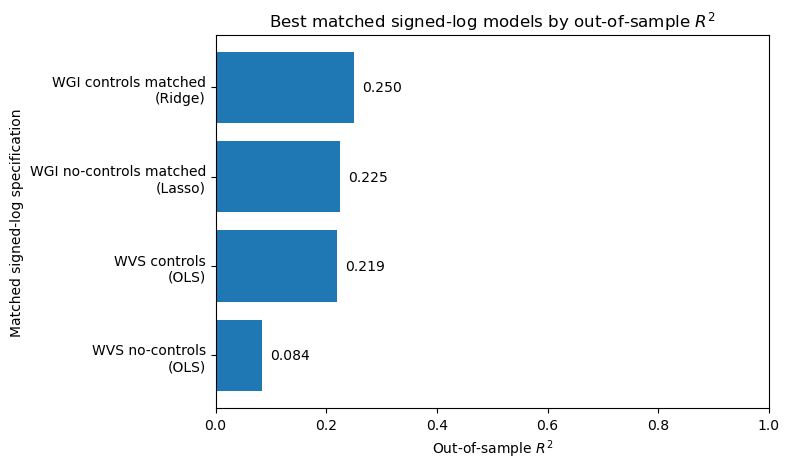

In [209]:
import pandas as pd
import matplotlib.pyplot as plt

# Best matched signed-log models per specification
best_matched_slog = pd.DataFrame({
    "Specification": [
        "WGI controls matched",
        "WGI no-controls matched",
        "WVS controls",
        "WVS no-controls"
    ],
    "Best model": [
        "Ridge",
        "Lasso",
        "OLS",
        "OLS"
    ],
    "R2": [
        0.250,
        0.225,
        0.219,
        0.084
    ]
})

# Create a label that shows both specification and best model
best_matched_slog["Label"] = (
    best_matched_slog["Specification"] + "\n(" + best_matched_slog["Best model"] + ")"
)

# Sort so the highest R2 appears at the top
best_matched_slog = best_matched_slog.sort_values("R2", ascending=True)

plt.figure(figsize=(8, 4.8))

bars = plt.barh(
    best_matched_slog["Label"],
    best_matched_slog["R2"]
)

# X-axis from 0 to 1
plt.xlim(0, 1)

plt.xlabel("Out-of-sample $R^2$")
plt.ylabel("Matched signed-log specification")
plt.title("Best matched signed-log models by out-of-sample $R^2$")

# Add value labels after each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center"
    )

plt.tight_layout()

# Save for thesis
plt.savefig("best_matched_slog_r2.png", dpi=300, bbox_inches="tight")
plt.savefig("best_matched_slog_r2.pdf", bbox_inches="tight")

plt.show()

In [215]:
import numpy as np
import pandas as pd

from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Best final model for the central matched-sample comparison:
# Ridge with WGI + controls on the signed-log target
df_error = wgi_controls_matched_slog.copy()

X = df_error[features_wgi_controls]
y = df_error[target_slog]

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5))
])

# Out-of-fold predictions: each observation is predicted by a model
# that did not train on that observation
df_error["y_pred_oof"] = cross_val_predict(
    ridge_model,
    X,
    y,
    cv=kf
)

# Error definitions
# Positive error means the model underpredicts the actual signed-log FDI value
df_error["error"] = df_error[target_slog] - df_error["y_pred_oof"]
df_error["abs_error"] = df_error["error"].abs()
df_error["squared_error"] = df_error["error"] ** 2

# Group country-year observations by GDP per capita
# This checks whether predictive errors differ between lower- and higher-income contexts
gdp_median = df_error["gdp_per_capita"].median()

df_error["gdp_per_capita_group"] = np.where(
    df_error["gdp_per_capita"] >= gdp_median,
    "Higher GDP per capita",
    "Lower GDP per capita"
)

def summarize_error_group(group):
    rmse = np.sqrt(mean_squared_error(group[target_slog], group["y_pred_oof"]))
    mae = mean_absolute_error(group[target_slog], group["y_pred_oof"])
    
    return pd.Series({
        "n": len(group),
        "RMSE": rmse,
        "MAE": mae,
        "RMSE_MAE_ratio": rmse / mae if mae != 0 else np.nan,
        "mean_error": group["error"].mean(),
        "R2": r2_score(group[target_slog], group["y_pred_oof"]) if len(group) > 1 else np.nan
    })

gdp_group_error = (
    df_error
    .groupby("gdp_per_capita_group")
    .apply(summarize_error_group)
    .reset_index()
)

gdp_group_error.round(4)

C:\Users\juliu\AppData\Local\Temp\ipykernel_12316\4283292148.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_error_group)


,gdp_per_capita_group,n,RMSE,MAE,RMSE_MAE_ratio,mean_error,R2
0,Higher GDP per capita,48.0,0.9352,0.6569,1.4236,0.0921,0.2189
1,Lower GDP per capita,48.0,0.7612,0.5269,1.4448,-0.0906,0.2244


In [216]:
low_mae = gdp_group_error.loc[
    gdp_group_error["gdp_per_capita_group"] == "Lower GDP per capita", "MAE"
].iloc[0]

high_mae = gdp_group_error.loc[
    gdp_group_error["gdp_per_capita_group"] == "Higher GDP per capita", "MAE"
].iloc[0]

mae_gap = high_mae - low_mae
mae_ratio = high_mae / low_mae

print("MAE gap, higher GDP minus lower GDP:", round(mae_gap, 4))
print("MAE ratio, higher GDP divided by lower GDP:", round(mae_ratio, 4))

MAE gap, higher GDP minus lower GDP: 0.1301
MAE ratio, higher GDP divided by lower GDP: 1.2468
